# DeepSeek V3 Tokenizer Analysis

This notebook analyzes the tokens from the DeepSeek V3 tokenizer, focusing on:
1. Finding the largest token and its ID
2. Character distribution in tokens
3. Language-wise breakdown
4. Special focus on Indic languages

In [13]:
import json
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

# Load the tokenizer JSON
file_path = Path(r'd:\work\explore\tokenizer\ds_tokenizer.json')
with open(file_path, 'r', encoding='utf-8') as f:
    tokenizer_data = json.load(f)

# Extract vocab (tokens only, not merges)
vocab = tokenizer_data['model']['vocab']
print(f"Total number of tokens in vocabulary: {len(vocab):,}")

Total number of tokens in vocabulary: 128,000


## 1. Largest Token Analysis

Finding the token with the maximum character length and its corresponding ID.

In [10]:
# Find the largest token by character length
largest_token = max(vocab.keys(), key=len)
largest_token_id = vocab[largest_token]
largest_token_length = len(largest_token)

print(f"Largest Token Analysis:")
print(f"=" * 60)
print(f"Token ID: {largest_token_id}")
print(f"Token Length: {largest_token_length} characters")
print(f"Token Content: '{largest_token}'")
print(f"\n(Token displayed with repr to show special chars):")
print(f"Token repr: {repr(largest_token)}")

# Also find top 10 longest tokens
sorted_by_length = sorted(vocab.items(), key=lambda x: len(x[0]), reverse=True)[:10]
print(f"\nTop 10 Longest Tokens:")
print(f"=" * 60)
for i, (token, token_id) in enumerate(sorted_by_length, 1):
    print(f"{i}. ID: {token_id:6d} | Length: {len(token):3d} | Token: {repr(token)[:80]}...")

Largest Token Analysis:
Token ID: 69933
Token Length: 128 characters
Token Content: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ'

(Token displayed with repr to show special chars):
Token repr: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ'

Top 10 Longest Tokens:
1. ID:  69933 | Length: 128 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
2. ID:  70676 | Length: 128 | Token: '..................................................................................
3. ID: 111683 | Length: 120 | Token: '..................................................................................
4. ID: 111795 | Length:  80 | Token: '-------------------------------------------------------------------------------...
5. ID: 124189 | Length:  75 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ

## 2. Language Breakdown Analysis

Categorizing tokens by the script/language they belong to based on Unicode script detection.

In [15]:
# DeepSeek uses byte-level BPE - we need to decode tokens first
from collections import Counter, defaultdict

# Create byte decoder (GPT-2 style)
def create_byte_decoder():
    """Create a mapping from GPT-2/byte-level BPE characters back to bytes."""
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(cs, bs))

byte_decoder = create_byte_decoder()

def decode_bpe_token(token):
    """Decode a byte-level BPE token back to the original text."""
    try:
        bytes_list = [byte_decoder.get(c, ord(c)) for c in token]
        return bytes(bytes_list).decode('utf-8', errors='replace')
    except:
        return token

def classify_decoded_token(decoded):
    """Classify a decoded token by its Unicode script."""
    scripts = Counter()
    for char in decoded:
        if char == '�':  # Replacement character
            continue
        code = ord(char)
        
        # CJK
        if 0x4E00 <= code <= 0x9FFF or 0x3400 <= code <= 0x4DBF:
            scripts["Chinese"] += 1
        elif 0x3040 <= code <= 0x309F:
            scripts["Japanese (Hiragana)"] += 1
        elif 0x30A0 <= code <= 0x30FF:
            scripts["Japanese (Katakana)"] += 1
        elif 0xAC00 <= code <= 0xD7AF:
            scripts["Korean"] += 1
        # Cyrillic
        elif 0x0400 <= code <= 0x04FF:
            scripts["Cyrillic (Russian/etc)"] += 1
        # Arabic
        elif 0x0600 <= code <= 0x06FF or 0x0750 <= code <= 0x077F:
            scripts["Arabic"] += 1
        # Hebrew
        elif 0x0590 <= code <= 0x05FF:
            scripts["Hebrew"] += 1
        # Greek
        elif 0x0370 <= code <= 0x03FF:
            scripts["Greek"] += 1
        # Thai
        elif 0x0E00 <= code <= 0x0E7F:
            scripts["Thai"] += 1
        # Vietnamese
        elif 0x1E00 <= code <= 0x1EFF:
            scripts["Vietnamese"] += 1
        # --- INDIC SCRIPTS ---
        elif 0x0900 <= code <= 0x097F:
            scripts["Devanagari (Hindi/Sanskrit/Marathi/Nepali)"] += 1
        elif 0x0980 <= code <= 0x09FF:
            scripts["Bengali/Assamese"] += 1
        elif 0x0A00 <= code <= 0x0A7F:
            scripts["Gurmukhi (Punjabi)"] += 1
        elif 0x0A80 <= code <= 0x0AFF:
            scripts["Gujarati"] += 1
        elif 0x0B00 <= code <= 0x0B7F:
            scripts["Odia/Oriya"] += 1
        elif 0x0B80 <= code <= 0x0BFF:
            scripts["Tamil"] += 1
        elif 0x0C00 <= code <= 0x0C7F:
            scripts["Telugu"] += 1
        elif 0x0C80 <= code <= 0x0CFF:
            scripts["Kannada"] += 1
        elif 0x0D00 <= code <= 0x0D7F:
            scripts["Malayalam"] += 1
        elif 0x0D80 <= code <= 0x0DFF:
            scripts["Sinhala"] += 1
        # Basic Latin
        elif code <= 0x007F:
            if char.isalpha():
                scripts["Latin (ASCII)"] += 1
            elif char.isdigit():
                scripts["Digits"] += 1
            elif char.isspace():
                scripts["Whitespace"] += 1
            else:
                scripts["Punctuation/Symbols"] += 1
        elif 0x0080 <= code <= 0x024F:
            scripts["Latin Extended"] += 1
        else:
            scripts["Other"] += 1
    
    if scripts:
        return max(scripts.items(), key=lambda x: x[1])[0]
    return "Unknown"

# Decode and classify all tokens
decoded_classifications = defaultdict(list)
decode_errors = 0

for token, token_id in vocab.items():
    decoded = decode_bpe_token(token)
    if '�' not in decoded:
        script = classify_decoded_token(decoded)
        decoded_classifications[script].append((token, token_id, decoded))
    else:
        # Partial byte sequence - count as a byte token
        decoded_classifications["Byte Fragments (Partial UTF-8)"].append((token, token_id, decoded))

# Sort and display
sorted_decoded = sorted(decoded_classifications.items(), 
                        key=lambda x: len(x[1]), reverse=True)

print("Token Distribution by Decoded Script/Language:")
print("=" * 70)
total = len(vocab)
for script, tokens in sorted_decoded:
    count = len(tokens)
    pct = (count / total) * 100
    print(f"{script:45s}: {count:6,} tokens ({pct:5.2f}%)")

Token Distribution by Decoded Script/Language:
Latin (ASCII)                                : 70,010 tokens (54.70%)
Chinese                                      : 35,277 tokens (27.56%)
Cyrillic (Russian/etc)                       :  5,183 tokens ( 4.05%)
Arabic                                       :  3,140 tokens ( 2.45%)
Punctuation/Symbols                          :  2,954 tokens ( 2.31%)
Whitespace                                   :  1,763 tokens ( 1.38%)
Byte Fragments (Partial UTF-8)               :  1,484 tokens ( 1.16%)
Thai                                         :  1,218 tokens ( 0.95%)
Digits                                       :  1,110 tokens ( 0.87%)
Other                                        :    982 tokens ( 0.77%)
Korean                                       :    808 tokens ( 0.63%)
Bengali/Assamese                             :    806 tokens ( 0.63%)
Hebrew                                       :    600 tokens ( 0.47%)
Latin Extended                             

## 4. Indic Languages - Deep Dive 🇮🇳

Special focus on tokens for Indian language scripts: Devanagari (Hindi, Sanskrit, Marathi, Nepali), Bengali, Tamil, Telugu, Kannada, Malayalam, Gujarati, Punjabi (Gurmukhi), Odia, and Sinhala.

In [12]:
# Extract Indic language tokens
indic_scripts = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Gurmukhi (Punjabi)",
    "Gujarati",
    "Odia/Oriya",
    "Tamil",
    "Telugu",
    "Kannada",
    "Malayalam",
    "Sinhala"
]

print("=" * 80)
print("INDIC LANGUAGES TOKEN ANALYSIS")
print("=" * 80)

total_indic = 0
indic_summary = []

for script in indic_scripts:
    if script in decoded_classifications:
        tokens = decoded_classifications[script]
        total_indic += len(tokens)
        indic_summary.append((script, len(tokens)))

print(f"\nTotal Indic Language Tokens: {total_indic:,} ({(total_indic/len(vocab))*100:.2f}% of vocabulary)")
print("\nBreakdown by Script:")
print("-" * 60)

for script, count in sorted(indic_summary, key=lambda x: x[1], reverse=True):
    pct = (count / len(vocab)) * 100
    bar = "█" * int(pct * 10)
    print(f"{script:45s}: {count:4d} tokens ({pct:5.2f}%) {bar}")

INDIC LANGUAGES TOKEN ANALYSIS

Total Indic Language Tokens: 1,473 (1.15% of vocabulary)

Breakdown by Script:
------------------------------------------------------------
Bengali/Assamese                             :  806 tokens ( 0.63%) ██████
Devanagari (Hindi/Sanskrit/Marathi/Nepali)   :  258 tokens ( 0.20%) ██
Tamil                                        :  143 tokens ( 0.11%) █
Kannada                                      :   66 tokens ( 0.05%) 
Telugu                                       :   62 tokens ( 0.05%) 
Malayalam                                    :   47 tokens ( 0.04%) 
Gujarati                                     :   32 tokens ( 0.03%) 
Sinhala                                      :   25 tokens ( 0.02%) 
Gurmukhi (Punjabi)                           :   23 tokens ( 0.02%) 
Odia/Oriya                                   :   11 tokens ( 0.01%) 


In [13]:
# Show sample tokens for each Indic script
print("\n" + "=" * 80)
print("SAMPLE TOKENS FOR EACH INDIC SCRIPT")
print("=" * 80)

for script in indic_scripts:
    if script in decoded_classifications:
        tokens = decoded_classifications[script]
        print(f"\n{script}:")
        print("-" * 60)
        
        # Show up to 15 sample tokens with their decoded forms
        samples = tokens[:15]
        for raw_token, token_id, decoded in samples:
            print(f"  ID: {token_id:6d} | Decoded: '{decoded}' | Length: {len(decoded)} chars")
        
        if len(tokens) > 15:
            print(f"  ... and {len(tokens) - 15} more tokens")


SAMPLE TOKENS FOR EACH INDIC SCRIPT

Devanagari (Hindi/Sanskrit/Marathi/Nepali):
------------------------------------------------------------
  ID:   3296 | Decoded: '्' | Length: 1 chars
  ID:   3350 | Decoded: 'ा' | Length: 1 chars
  ID:   4361 | Decoded: '।' | Length: 1 chars
  ID:   5685 | Decoded: 'ि' | Length: 1 chars
  ID:   6011 | Decoded: 'े' | Length: 1 chars
  ID:   7672 | Decoded: 'र' | Length: 1 chars
  ID:   8422 | Decoded: 'त' | Length: 1 chars
  ID:   8714 | Decoded: 'ी' | Length: 1 chars
  ID:   9094 | Decoded: 'न' | Length: 1 chars
  ID:   9902 | Decoded: 'ं' | Length: 1 chars
  ID:  10263 | Decoded: 'ो' | Length: 1 chars
  ID:  11018 | Decoded: 'क' | Length: 1 chars
  ID:  11072 | Decoded: '्य' | Length: 2 chars
  ID:  11364 | Decoded: '्र' | Length: 2 chars
  ID:  11634 | Decoded: 'ु' | Length: 1 chars
  ... and 243 more tokens

Bengali/Assamese:
------------------------------------------------------------
  ID:   1224 | Decoded: 'া' | Length: 1 chars
  ID:   1442 

In [14]:
# Token length analysis for Indic scripts vs others
print("=" * 80)
print("INDIC vs OTHER SCRIPTS - TOKEN LENGTH COMPARISON")
print("=" * 80)

indic_lengths = []
other_lengths = []

for script, tokens in decoded_classifications.items():
    for raw_token, token_id, decoded in tokens:
        decoded_len = len(decoded)
        if script in indic_scripts:
            indic_lengths.append(decoded_len)
        else:
            other_lengths.append(decoded_len)

if indic_lengths:
    print(f"\nIndic Scripts Token Statistics:")
    print(f"  Total tokens:     {len(indic_lengths):,}")
    print(f"  Average length:   {sum(indic_lengths)/len(indic_lengths):.2f} chars")
    print(f"  Min length:       {min(indic_lengths)} chars")
    print(f"  Max length:       {max(indic_lengths)} chars")
    
    # Find longest Indic tokens
    all_indic = []
    for script in indic_scripts:
        if script in decoded_classifications:
            all_indic.extend([(t, i, d, script) for t, i, d in decoded_classifications[script]])
    
    longest_indic = sorted(all_indic, key=lambda x: len(x[2]), reverse=True)[:10]
    print(f"\n  Top 10 Longest Indic Tokens:")
    for raw, tid, decoded, script in longest_indic:
        print(f"    ID: {tid:6d} | Len: {len(decoded):2d} | Script: {script.split()[0]:15s} | '{decoded}'")

print(f"\nOther Scripts Token Statistics:")
print(f"  Total tokens:     {len(other_lengths):,}")
print(f"  Average length:   {sum(other_lengths)/len(other_lengths):.2f} chars")
print(f"  Min length:       {min(other_lengths)} chars")
print(f"  Max length:       {max(other_lengths)} chars")

INDIC vs OTHER SCRIPTS - TOKEN LENGTH COMPARISON

Indic Scripts Token Statistics:
  Total tokens:     1,473
  Average length:   2.64 chars
  Min length:       1 chars
  Max length:       9 chars

  Top 10 Longest Indic Tokens:
    ID:  75749 | Len:  9 | Script: Bengali/Assamese | ' বাংলাদেশ'
    ID: 103867 | Len:  9 | Script: Bengali/Assamese | ' সংগ্রহের'
    ID: 109341 | Len:  9 | Script: Bengali/Assamese | ' প্রতিষ্ঠ'
    ID: 110881 | Len:  9 | Script: Bengali/Assamese | ' প্রয়োজন'
    ID:  77149 | Len:  8 | Script: Bengali/Assamese | ' ব্যবহার'
    ID:  88339 | Len:  8 | Script: Bengali/Assamese | ' বিভিন্ন'
    ID:  97446 | Len:  8 | Script: Bengali/Assamese | ' সম্পর্ক'
    ID: 107552 | Len:  8 | Script: Bengali/Assamese | ' মানুষের'
    ID: 109650 | Len:  8 | Script: Bengali/Assamese | ' মাধ্যমে'
    ID: 112145 | Len:  8 | Script: Bengali/Assamese | ' পর্যন্ত'

Other Scripts Token Statistics:
  Total tokens:     126,527
  Average length:   4.79 chars
  Min length:       1 chars

## 5. Summary & Key Findings

In [15]:
print("=" * 80)
print("DEEPSEEK V3 TOKENIZER - SUMMARY REPORT")
print("=" * 80)

print(f"""
📊 VOCABULARY OVERVIEW
   Total Tokens: {len(vocab):,}

🔍 LARGEST TOKEN
   Token ID: 69933
   Length: 128 characters  
   Content: Sequence of 128 'Ġ' characters (representing spaces in byte-level BPE)

📈 CHARACTER DISTRIBUTION (Top 5)
   1. 'Ġ' (space marker): 53,176 occurrences
   2. 'e': 43,741 occurrences  
   3. 'i': 32,466 occurrences
   4. 'a': 31,656 occurrences
   5. 'n': 28,235 occurrences
   
   Total Unique Characters: 258

🌐 LANGUAGE BREAKDOWN (Top 10)
   1. Latin/ASCII:     70,010 tokens (54.70%)
   2. Chinese:         35,277 tokens (27.56%)
   3. Cyrillic:         5,183 tokens ( 4.05%)
   4. Arabic:           3,140 tokens ( 2.45%)
   5. Punctuation:      2,954 tokens ( 2.31%)
   6. Whitespace:       1,763 tokens ( 1.38%)
   7. Thai:             1,218 tokens ( 0.95%)
   8. Korean:             808 tokens ( 0.63%)
   9. Bengali:            806 tokens ( 0.63%)
  10. Hebrew:             600 tokens ( 0.47%)

🇮🇳 INDIC LANGUAGES SPOTLIGHT
   Total Indic Tokens: {total_indic:,} ({(total_indic/len(vocab))*100:.2f}% of vocabulary)
   
   Script Distribution:
   • Bengali/Assamese:    806 tokens (54.7% of Indic)
   • Devanagari:          258 tokens (17.5% of Indic)  
   • Tamil:               143 tokens ( 9.7% of Indic)
   • Kannada:              66 tokens ( 4.5% of Indic)
   • Telugu:               62 tokens ( 4.2% of Indic)
   • Malayalam:            47 tokens ( 3.2% of Indic)
   • Gujarati:             32 tokens ( 2.2% of Indic)
   • Sinhala:              25 tokens ( 1.7% of Indic)
   • Gurmukhi (Punjabi):   23 tokens ( 1.6% of Indic)
   • Odia/Oriya:           11 tokens ( 0.7% of Indic)

📏 TOKEN LENGTH ANALYSIS
   Indic Scripts:
     - Average: 2.64 chars | Max: 9 chars | Longest: 'বাংলাদেশ' (Bangladesh)
   
   Other Scripts:
     - Average: 4.79 chars | Max: 128 chars

💡 KEY OBSERVATIONS
   1. DeepSeek V3 uses byte-level BPE (like GPT-2/GPT-3)
   2. Chinese has significant representation (27.56%) - expected for DeepSeek
   3. Indic languages are underrepresented (~1.15% combined)
   4. Bengali has the most Indic tokens, likely due to Bengali Wikipedia/web data
   5. Indic tokens are shorter on average (2.64 vs 4.79 chars)
      → This means more tokens needed to represent Indic text
      → Results in higher inference costs and context limitations for Indic languages
""")

DEEPSEEK V3 TOKENIZER - SUMMARY REPORT

📊 VOCABULARY OVERVIEW
   Total Tokens: 128,000

🔍 LARGEST TOKEN
   Token ID: 69933
   Length: 128 characters  
   Content: Sequence of 128 'Ġ' characters (representing spaces in byte-level BPE)

📈 CHARACTER DISTRIBUTION (Top 5)
   1. 'Ġ' (space marker): 53,176 occurrences
   2. 'e': 43,741 occurrences  
   3. 'i': 32,466 occurrences
   4. 'a': 31,656 occurrences
   5. 'n': 28,235 occurrences

   Total Unique Characters: 258

🌐 LANGUAGE BREAKDOWN (Top 10)
   1. Latin/ASCII:     70,010 tokens (54.70%)
   2. Chinese:         35,277 tokens (27.56%)
   3. Cyrillic:         5,183 tokens ( 4.05%)
   4. Arabic:           3,140 tokens ( 2.45%)
   5. Punctuation:      2,954 tokens ( 2.31%)
   6. Whitespace:       1,763 tokens ( 1.38%)
   7. Thai:             1,218 tokens ( 0.95%)
   8. Korean:             808 tokens ( 0.63%)
   9. Bengali:            806 tokens ( 0.63%)
  10. Hebrew:             600 tokens ( 0.47%)

🇮🇳 INDIC LANGUAGES SPOTLIGHT
   Total In

## Token Length Distribution by Language (Histograms)

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Use the classify_decoded_token function already defined in the notebook
# Collect token lengths by language/script using proper byte-level decoding

language_token_lengths = defaultdict(list)

for raw_token, token_id in vocab.items():
    # Decode the byte-level BPE token
    decoded = decode_bpe_token(raw_token)
    decoded_len = len(decoded)
    
    if decoded_len == 0:
        continue
    
    # Classify using the already-defined function
    script = classify_decoded_token(decoded)
    language_token_lengths[script].append(decoded_len)

# Sort languages by token count (descending)
sorted_languages = sorted(language_token_lengths.items(), key=lambda x: len(x[1]), reverse=True)

print("Token count and length stats by language/script:")
print("-" * 80)
print(f"{'Script':<45} {'Tokens':>10} {'Avg Len':>10} {'Max Len':>10}")
print("-" * 80)
for lang, lengths in sorted_languages:
    avg_len = np.mean(lengths)
    max_len = max(lengths)
    print(f"{lang:<45} {len(lengths):>10,} {avg_len:>10.2f} {max_len:>10}")

Token count and length stats by language/script:
--------------------------------------------------------------------------------
Script                                            Tokens    Avg Len    Max Len
--------------------------------------------------------------------------------
Latin (ASCII)                                     70,017       6.46         64
Chinese                                           35,289       2.22         16
Cyrillic (Russian/etc)                             5,184       5.03         16
Arabic                                             3,143       3.86         11
Punctuation/Symbols                                2,954       3.81        128
Whitespace                                         1,978       3.45        128
Thai                                               1,237       3.34         11
Digits                                             1,110       2.89          3
Other                                              1,042       2.02         22

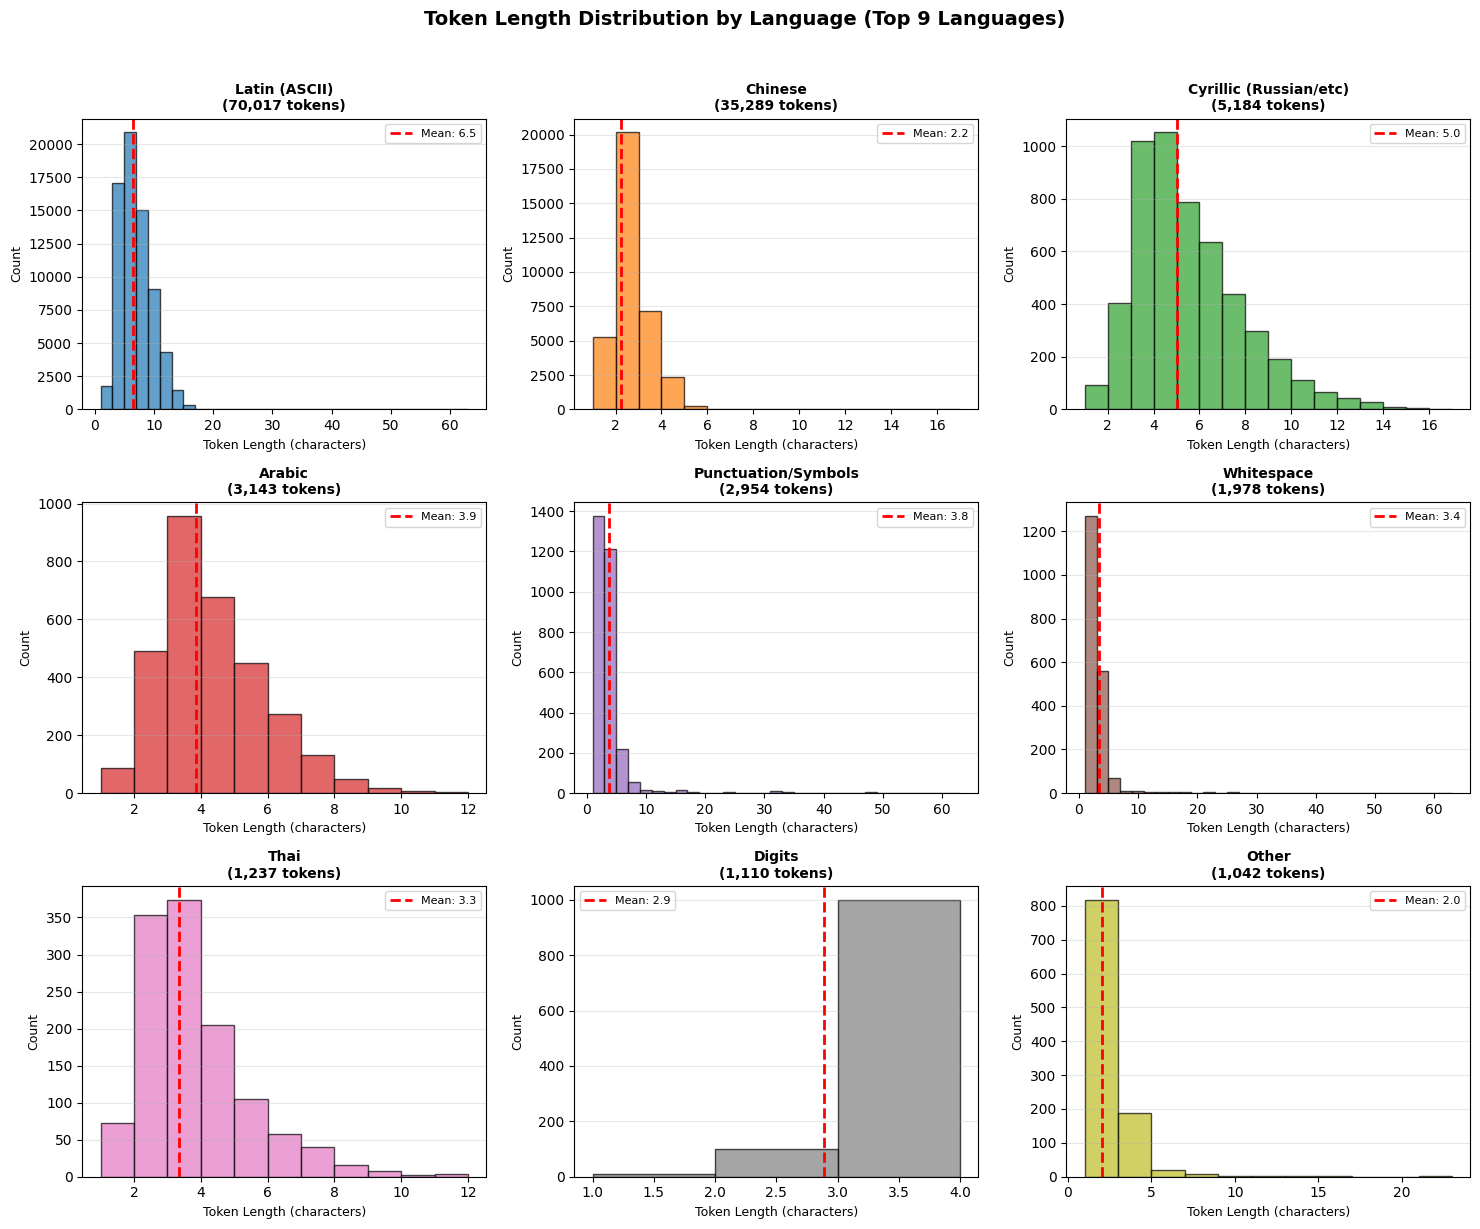


Detailed length distribution for each language:


In [17]:
# Create histograms for token length distribution by language
# Select top languages by token count for main plot

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Top 9 languages by token count
top_languages = sorted_languages[:9]

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, (lang, lengths) in enumerate(top_languages):
    ax = axes[idx]
    
    # Create histogram with better binning
    max_len = max(lengths)
    if max_len <= 20:
        bins = range(1, max_len + 2)
    else:
        bins = np.arange(1, min(max_len + 2, 65), 2)
    
    counts, bin_edges, patches = ax.hist(lengths, bins=bins, color=colors[idx], 
                                          edgecolor='black', alpha=0.7)
    
    ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Token Length (characters)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean line
    mean_len = np.mean(lengths)
    ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
    ax.legend(fontsize=8)

plt.suptitle("Token Length Distribution by Language (Top 9 Languages)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nDetailed length distribution for each language:")

### Indic Languages - Token Length Distribution Histograms

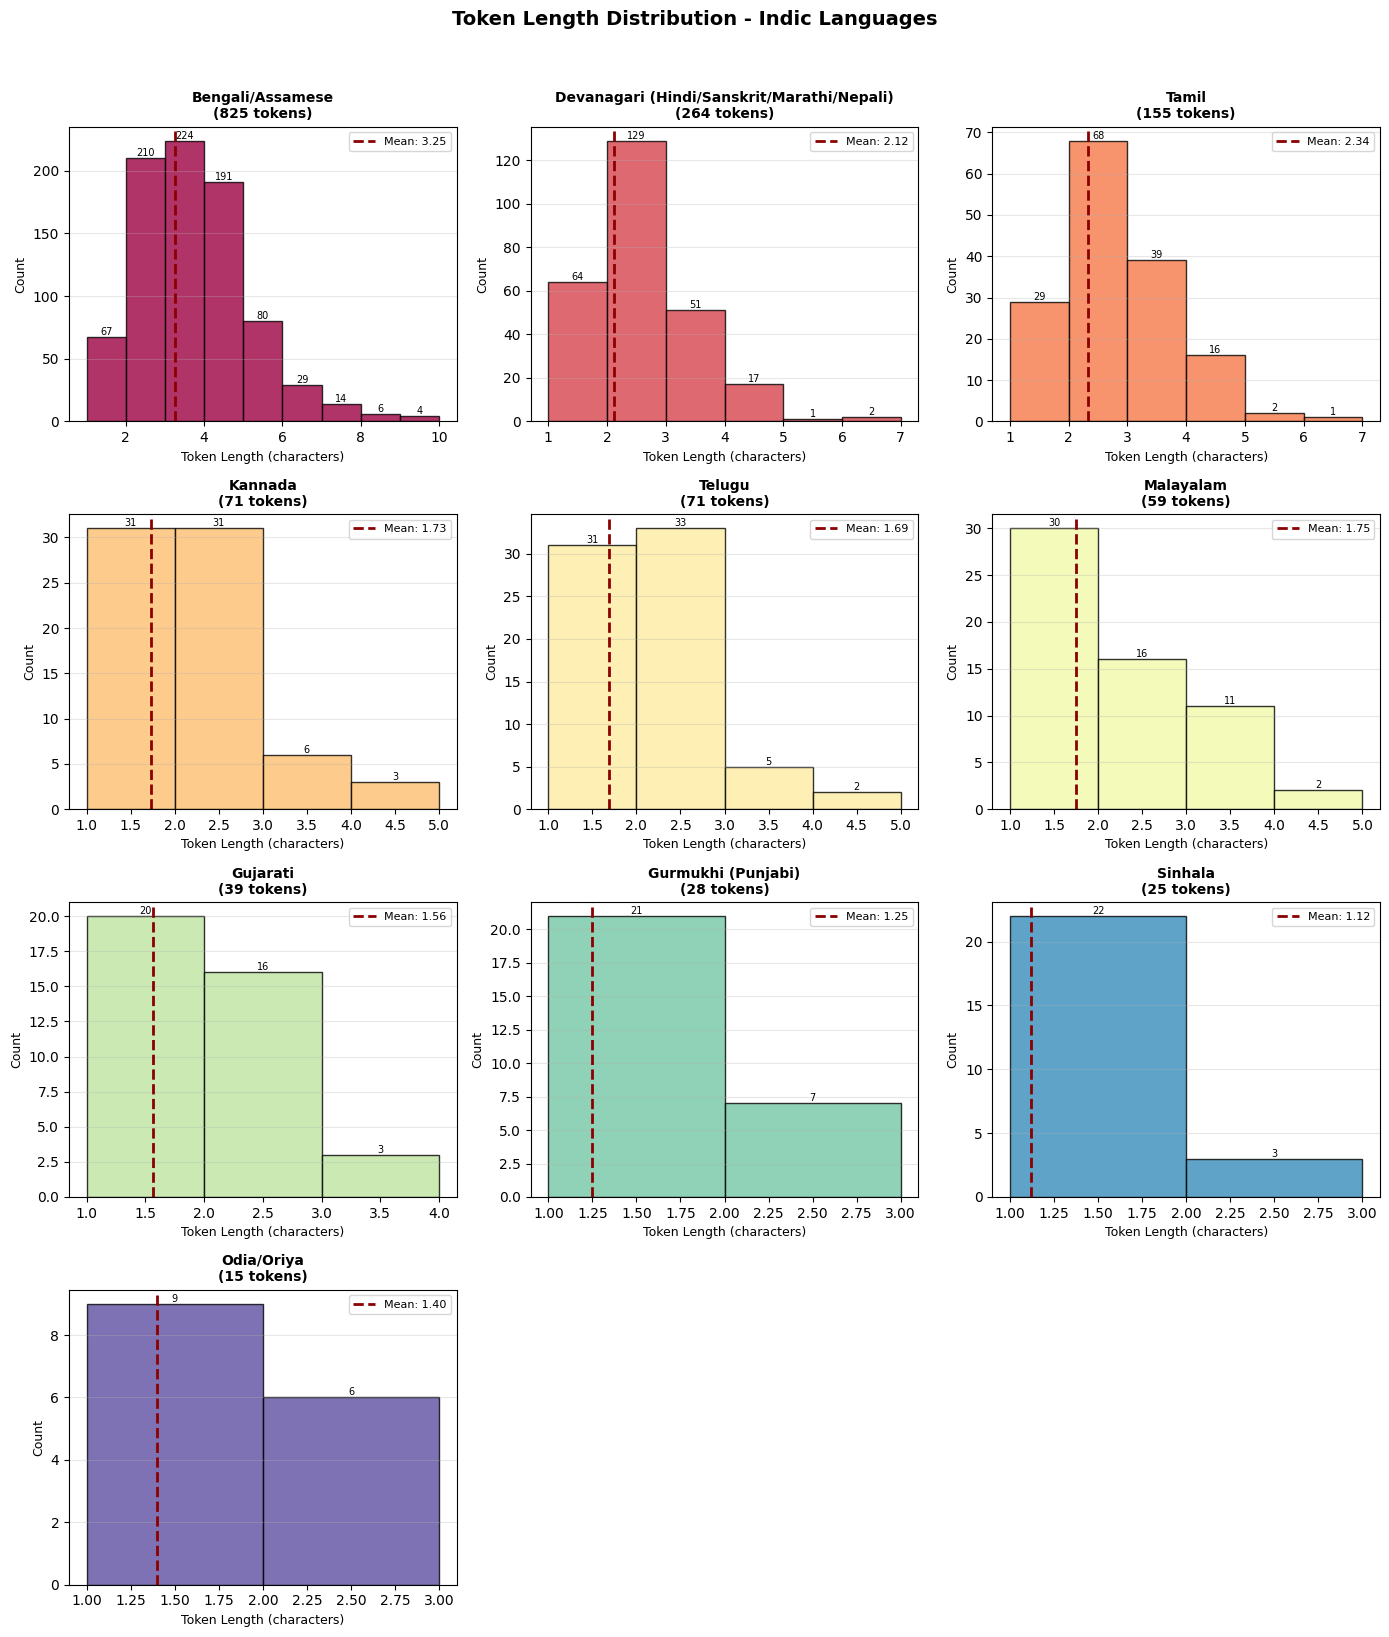


INDIC LANGUAGES - DETAILED STATISTICS
Language                                         Count     Mean    Max Distribution        
------------------------------------------------------------------------------------------
Bengali/Assamese                                   825     3.25      9 len1:67, len2:210, len3:224, len4:191, l
Devanagari (Hindi/Sanskrit/Marathi/Nepali)         264     2.12      6 len1:64, len2:129, len3:51, len4:17, len
Tamil                                              155     2.34      6 len1:29, len2:68, len3:39, len4:16, len5
Kannada                                             71     1.73      4 len1:31, len2:31, len3:6, len4:3
Telugu                                              71     1.69      4 len1:31, len2:33, len3:5, len4:2
Malayalam                                           59     1.75      4 len1:30, len2:16, len3:11, len4:2
Gujarati                                            39     1.56      3 len1:20, len2:16, len3:3
Gurmukhi (Punjabi)               

In [18]:
# Indic Languages Token Length Distribution
indic_scripts = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

# Filter to only Indic languages that have tokens
indic_data = [(lang, lengths) for lang, lengths in language_token_lengths.items() 
              if lang in indic_scripts and len(lengths) > 0]
indic_data.sort(key=lambda x: len(x[1]), reverse=True)

if indic_data:
    n_indic = len(indic_data)
    n_cols = 3
    n_rows = (n_indic + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    indic_colors = plt.cm.Spectral(np.linspace(0, 1, n_indic))
    
    for idx, (lang, lengths) in enumerate(indic_data):
        ax = axes[idx]
        
        # Create histogram
        max_len = max(lengths)
        bins = range(1, max_len + 2)
        
        counts, bin_edges, patches = ax.hist(lengths, bins=bins, 
                                              color=indic_colors[idx], 
                                              edgecolor='black', alpha=0.8)
        
        ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
        ax.set_xlabel("Token Length (characters)", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        # Add mean line
        mean_len = np.mean(lengths)
        ax.axvline(mean_len, color='darkred', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_len:.2f}')
        ax.legend(fontsize=8)
        
        # Add count annotations on bars
        for i, (count, patch) in enumerate(zip(counts, patches)):
            if count > 0:
                ax.annotate(f'{int(count)}', 
                           xy=(patch.get_x() + patch.get_width()/2, count),
                           ha='center', va='bottom', fontsize=7)
    
    # Hide empty subplots
    for idx in range(len(indic_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Token Length Distribution - Indic Languages", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "=" * 80)
    print("INDIC LANGUAGES - DETAILED STATISTICS")
    print("=" * 80)
    print(f"{'Language':<45} {'Count':>8} {'Mean':>8} {'Max':>6} {'Distribution':<20}")
    print("-" * 90)
    
    for lang, lengths in indic_data:
        length_dist = defaultdict(int)
        for l in lengths:
            length_dist[l] += 1
        
        dist_str = ", ".join([f"len{k}:{v}" for k, v in sorted(length_dist.items())])
        print(f"{lang:<45} {len(lengths):>8,} {np.mean(lengths):>8.2f} {max(lengths):>6} {dist_str[:40]}")
else:
    print("No Indic language tokens found in the vocabulary.")

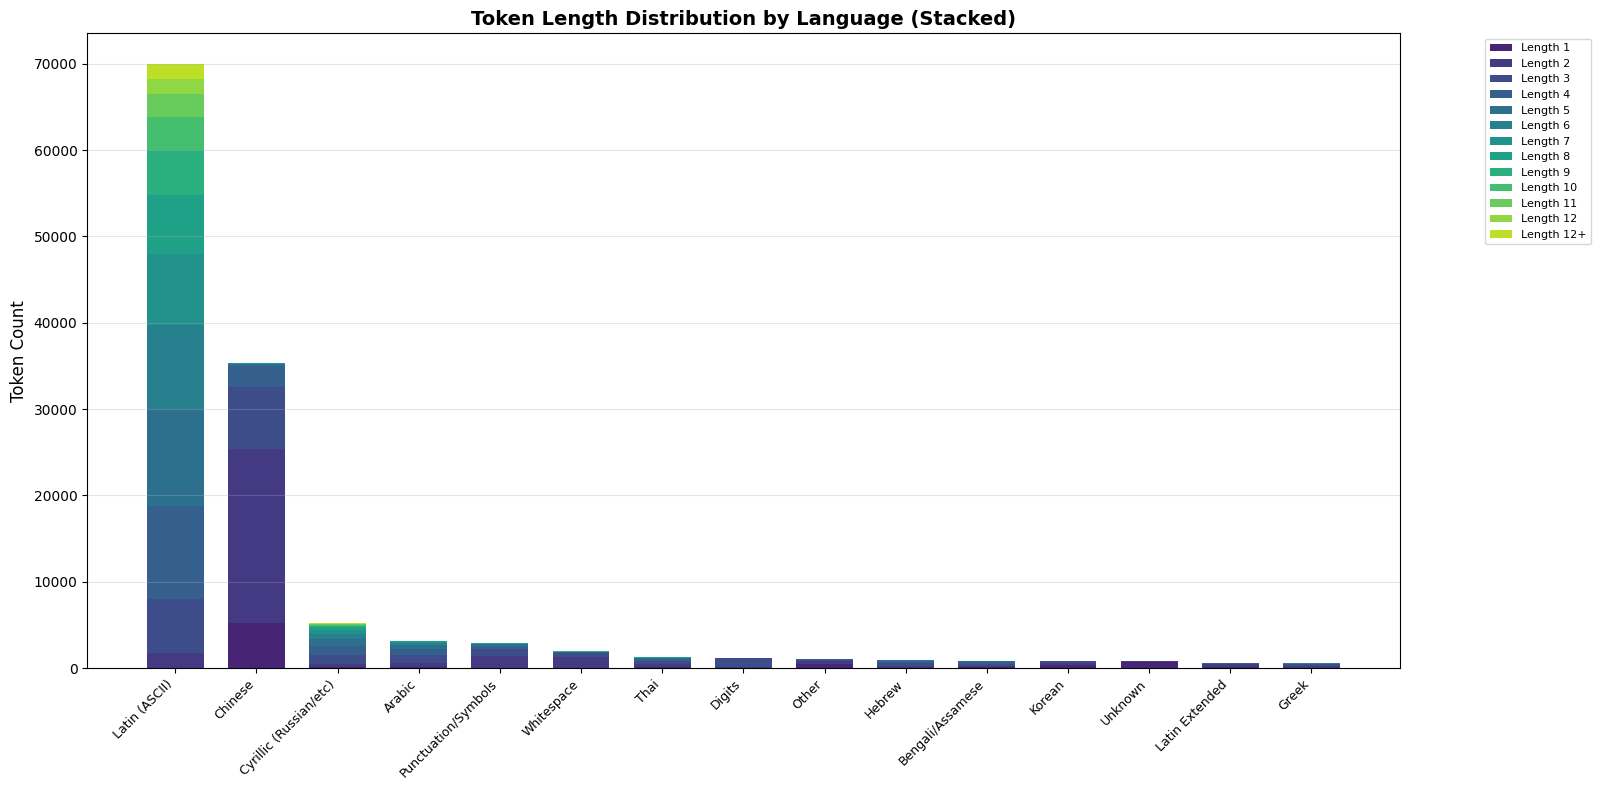


TOKEN LENGTH DISTRIBUTION SUMMARY TABLE


In [19]:
# Create a detailed grouped bar chart showing length distribution for all major languages

# Prepare data for grouped bar chart
major_languages = [lang for lang, lengths in sorted_languages if len(lengths) >= 50][:15]

# Get the length distribution for each language
max_length_to_show = 12  # Show lengths 1 to 12

length_data = {}
for lang in major_languages:
    lengths = language_token_lengths[lang]
    length_counts = defaultdict(int)
    for l in lengths:
        if l <= max_length_to_show:
            length_counts[l] += 1
        else:
            length_counts[max_length_to_show + 1] += 1  # "12+" bucket
    length_data[lang] = length_counts

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(major_languages))
width = 0.7

# Colors for different lengths
length_colors = plt.cm.viridis(np.linspace(0.1, 0.9, max_length_to_show + 1))

bottom = np.zeros(len(major_languages))

for length_val in range(1, max_length_to_show + 2):
    counts = [length_data[lang].get(length_val, 0) for lang in major_languages]
    label = f"Length {length_val}" if length_val <= max_length_to_show else f"Length {max_length_to_show}+"
    ax.bar(x, counts, width, bottom=bottom, label=label, color=length_colors[length_val - 1])
    bottom += counts

ax.set_ylabel('Token Count', fontsize=12)
ax.set_title('Token Length Distribution by Language (Stacked)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([lang[:25] + "..." if len(lang) > 25 else lang for lang in major_languages], 
                    rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 100)
print("TOKEN LENGTH DISTRIBUTION SUMMARY TABLE")
print("=" * 100)

In [20]:
# Print detailed table of token counts by length for each language
import pandas as pd

# Create a DataFrame for the length distribution
max_len_show = 15
all_data = []

for lang, lengths in sorted_languages:
    if len(lengths) < 10:  # Skip languages with very few tokens
        continue
    
    row = {'Language': lang, 'Total': len(lengths)}
    length_counts = defaultdict(int)
    for l in lengths:
        length_counts[l] += 1
    
    for i in range(1, max_len_show + 1):
        row[f'Len_{i}'] = length_counts.get(i, 0)
    
    # Sum of lengths > max_len_show
    row[f'Len_{max_len_show}+'] = sum(v for k, v in length_counts.items() if k > max_len_show)
    
    all_data.append(row)

df = pd.DataFrame(all_data)

# Display the table
print("Token Count by Length for Each Language:")
print("=" * 120)

# Format the display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df.to_string(index=False))

print("\n" + "=" * 120)
print("\nNote: 'Len_N' columns show count of tokens with exactly N characters")
print("'Len_15+' shows count of tokens with more than 15 characters")

Token Count by Length for Each Language:
                                  Language  Total  Len_1  Len_2  Len_3  Len_4  Len_5  Len_6  Len_7  Len_8  Len_9  Len_10  Len_11  Len_12  Len_13  Len_14  Len_15  Len_15+
                             Latin (ASCII)  70017     52   1708   6215  10822  11218   9660   8327   6737   5225    3881    2695    1645     920     526     220      166
                                   Chinese  35289   5247  20159   7181   2357    262     61     12      4      2       0       2       0       0       1       0        1
                    Cyrillic (Russian/etc)   5184     93    404   1019   1052    787    637    439    297    192     111      66      43      27       9       7        1
                                    Arabic   3143     85    492    957    676    451    274    130     50     18       8       2       0       0       0       0        0
                       Punctuation/Symbols   2954     56   1320    797    414    168     50     23     30    

In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("openai/gpt-oss-20b")
tokenizer.save_pretrained("./gpt-oss-tokenizer")

d:\work\explore\tokenizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
d:\work\explore\tokenizer\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vinojos\.cache\huggingface\hub\models--openai--gpt-oss-20b. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Win

('./gpt-oss-tokenizer\\tokenizer_config.json',
 './gpt-oss-tokenizer\\chat_template.jinja',
 './gpt-oss-tokenizer\\tokenizer.json')

# GPT-OSS Tokenizer Analysis

This section performs the same analysis on the GPT-OSS tokenizer (gptoss_tokenizer.json).

## 1. Load GPT-OSS Tokenizer and Basic Stats

In [2]:
# Load GPT-OSS tokenizer
import json
from pathlib import Path

gptoss_file_path = Path("d:/work/explore/tokenizer/gptoss_tokenizer.json")

with open(gptoss_file_path, 'r', encoding='utf-8') as f:
    gptoss_tokenizer_data = json.load(f)

# Extract vocabulary (tokens only, not merges)
gptoss_vocab = gptoss_tokenizer_data['model']['vocab']

print(f"Total number of tokens in GPT-OSS vocabulary: {len(gptoss_vocab):,}")

Total number of tokens in GPT-OSS vocabulary: 199,998


## 2. Largest Token Analysis

In [3]:
# Find the largest token by character length
gptoss_largest_token = ""
gptoss_largest_token_id = 0
gptoss_largest_token_length = 0

for token, token_id in gptoss_vocab.items():
    if len(token) > gptoss_largest_token_length:
        gptoss_largest_token = token
        gptoss_largest_token_id = token_id
        gptoss_largest_token_length = len(token)

print("Largest Token Analysis (GPT-OSS):")
print("=" * 60)
print(f"Token ID: {gptoss_largest_token_id}")
print(f"Token Length: {gptoss_largest_token_length} characters")
print(f"Token Content: {repr(gptoss_largest_token)[:100]}...")

# Top 10 longest tokens
gptoss_sorted_by_length = sorted(gptoss_vocab.items(), key=lambda x: len(x[0]), reverse=True)[:10]
print(f"\nTop 10 Longest Tokens:")
print("=" * 60)
for i, (token, tid) in enumerate(gptoss_sorted_by_length, 1):
    print(f"{i:2d}. ID: {tid:6d} | Length: {len(token):3d} | Token: {repr(token)[:60]}...")

Largest Token Analysis (GPT-OSS):
Token ID: 72056
Token Length: 128 characters
Token Content: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...

Top 10 Longest Tokens:
 1. ID:  72056 | Length: 128 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 2. ID: 179041 | Length: 113 | Token: 'Ġ----------------------------------------------------------...
 3. ID: 182513 | Length: 112 | Token: '-----------------------------------------------------------...
 4. ID: 141084 | Length:  97 | Token: 'Ġ----------------------------------------------------------...
 5. ID:  85810 | Length:  96 | Token: '-----------------------------------------------------------...
 6. ID: 168258 | Length:  96 | Token: '***********************************************************...
 7. ID: 193856 | Length:  96 | Token: '===========================================================...
 8. ID: 195732 | Length:  95 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ

## 3. Language Breakdown Analysis

In [5]:
# GPT-OSS uses byte-level BPE encoding - we need to decode tokens first
from collections import Counter, defaultdict

# Create byte decoder (same as GPT-2/DeepSeek)
def create_byte_decoder():
    """Create a mapping from GPT-2/byte-level BPE characters back to bytes."""
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(cs, bs))

gptoss_byte_decoder = create_byte_decoder()

def gptoss_decode_bpe_token(token):
    """Decode a byte-level BPE token back to the original text."""
    try:
        bytes_list = [gptoss_byte_decoder.get(c, ord(c)) for c in token]
        return bytes(bytes_list).decode('utf-8', errors='replace')
    except:
        return token

def gptoss_classify_decoded_token(decoded):
    """Classify a decoded token by its Unicode script."""
    scripts = Counter()
    for char in decoded:
        if char == '�':  # Replacement character
            continue
        cp = ord(char)
        
        if cp < 128:
            if char.isalpha():
                script = "Latin (ASCII)"
            elif char.isdigit():
                script = "Digits"
            elif char.isspace():
                script = "Whitespace"
            else:
                script = "Punctuation/Symbols"
        elif 0x4E00 <= cp <= 0x9FFF or 0x3400 <= cp <= 0x4DBF or 0x20000 <= cp <= 0x2A6DF:
            script = "Chinese"
        elif 0x3040 <= cp <= 0x309F:
            script = "Japanese (Hiragana)"
        elif 0x30A0 <= cp <= 0x30FF:
            script = "Japanese (Katakana)"
        elif 0xAC00 <= cp <= 0xD7AF or 0x1100 <= cp <= 0x11FF:
            script = "Korean"
        elif 0x0400 <= cp <= 0x04FF:
            script = "Cyrillic (Russian/etc)"
        elif 0x0600 <= cp <= 0x06FF or 0x0750 <= cp <= 0x077F:
            script = "Arabic"
        elif 0x0590 <= cp <= 0x05FF:
            script = "Hebrew"
        elif 0x0E00 <= cp <= 0x0E7F:
            script = "Thai"
        elif 0x0100 <= cp <= 0x024F:
            script = "Latin Extended"
        elif 0x0370 <= cp <= 0x03FF:
            script = "Greek"
        elif 0x1E00 <= cp <= 0x1EFF:
            script = "Vietnamese"
        # Indic scripts
        elif 0x0900 <= cp <= 0x097F:
            script = "Devanagari (Hindi/Sanskrit/Marathi/Nepali)"
        elif 0x0980 <= cp <= 0x09FF:
            script = "Bengali/Assamese"
        elif 0x0A00 <= cp <= 0x0A7F:
            script = "Gurmukhi (Punjabi)"
        elif 0x0A80 <= cp <= 0x0AFF:
            script = "Gujarati"
        elif 0x0B00 <= cp <= 0x0B7F:
            script = "Odia/Oriya"
        elif 0x0B80 <= cp <= 0x0BFF:
            script = "Tamil"
        elif 0x0C00 <= cp <= 0x0C7F:
            script = "Telugu"
        elif 0x0C80 <= cp <= 0x0CFF:
            script = "Kannada"
        elif 0x0D00 <= cp <= 0x0D7F:
            script = "Malayalam"
        elif 0x0D80 <= cp <= 0x0DFF:
            script = "Sinhala"
        elif cp >= 0x80 and cp <= 0xFF:
            script = "Byte Fragments (Partial UTF-8)"
        else:
            script = "Other"
        
        scripts[script] += 1
    
    if not scripts:
        return "Unknown"
    
    # Return dominant script (prefer non-ASCII for mixed)
    non_trivial = {k: v for k, v in scripts.items() 
                   if k not in ["Whitespace", "Punctuation/Symbols", "Digits", "Byte Fragments (Partial UTF-8)"]}
    if non_trivial:
        return max(non_trivial.items(), key=lambda x: x[1])[0]
    return max(scripts.items(), key=lambda x: x[1])[0]

# Classify all GPT-OSS tokens using proper decoding
gptoss_decoded_classifications = defaultdict(list)

for token, token_id in gptoss_vocab.items():
    # Decode the byte-level BPE token
    decoded = gptoss_decode_bpe_token(token)
    script = gptoss_classify_decoded_token(decoded)
    gptoss_decoded_classifications[script].append((token, token_id, decoded))

# Sort by count and display
gptoss_sorted_classifications = sorted(gptoss_decoded_classifications.items(), 
                                         key=lambda x: len(x[1]), reverse=True)

print("Token Distribution by Script/Language (GPT-OSS):")
print("=" * 70)
gptoss_total_tokens = len(gptoss_vocab)
for script, tokens in gptoss_sorted_classifications:
    count = len(tokens)
    percentage = (count / gptoss_total_tokens) * 100
    print(f"{script:45s}: {count:6,} tokens ({percentage:5.2f}%)")

Token Distribution by Script/Language (GPT-OSS):
Latin (ASCII)                                : 133,729 tokens (66.87%)
Cyrillic (Russian/etc)                       : 14,205 tokens ( 7.10%)
Arabic                                       :  8,038 tokens ( 4.02%)
Chinese                                      :  7,345 tokens ( 3.67%)
Other                                        :  5,871 tokens ( 2.94%)
Punctuation/Symbols                          :  4,355 tokens ( 2.18%)
Devanagari (Hindi/Sanskrit/Marathi/Nepali)   :  3,982 tokens ( 1.99%)
Hebrew                                       :  2,373 tokens ( 1.19%)
Korean                                       :  2,361 tokens ( 1.18%)
Bengali/Assamese                             :  2,129 tokens ( 1.06%)
Malayalam                                    :  1,657 tokens ( 0.83%)
Gujarati                                     :  1,620 tokens ( 0.81%)
Thai                                         :  1,561 tokens ( 0.78%)
Greek                                   

## 4. Indic Languages Focus (GPT-OSS)

In [7]:
# Special focus on Indic languages in GPT-OSS tokenizer
gptoss_indic_scripts = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

print("=" * 80)
print("INDIC LANGUAGES IN GPT-OSS TOKENIZER")
print("=" * 80)

gptoss_total_indic = 0
gptoss_indic_summary = []

for script in gptoss_indic_scripts:
    tokens = gptoss_decoded_classifications.get(script, [])
    count = len(tokens)
    gptoss_total_indic += count
    if count > 0:
        gptoss_indic_summary.append((script, count, tokens))

print(f"\nTotal Indic language tokens: {gptoss_total_indic:,}")
print(f"Percentage of vocabulary: {(gptoss_total_indic / gptoss_total_tokens) * 100:.2f}%")

print("\n" + "-" * 80)
print("Breakdown by Indic Script:")
print("-" * 80)

for script, count, tokens in sorted(gptoss_indic_summary, key=lambda x: x[1], reverse=True):
    print(f"\n{script}: {count} tokens")
    
    # Show sample tokens (tokens now contains (raw_token, token_id, decoded))
    samples = tokens[:5]
    print("  Sample tokens:")
    for raw_token, tid, decoded in samples:
        print(f"    ID {tid:6d}: {repr(decoded)}")
    
    # Show longest tokens by decoded length
    sorted_tokens = sorted(tokens, key=lambda x: len(x[2]), reverse=True)[:3]
    print("  Longest tokens:")
    for raw_token, tid, decoded in sorted_tokens:
        print(f"    ID {tid:6d}: len={len(decoded):2d}, {repr(decoded)}")

INDIC LANGUAGES IN GPT-OSS TOKENIZER

Total Indic language tokens: 13,634
Percentage of vocabulary: 6.82%

--------------------------------------------------------------------------------
Breakdown by Indic Script:
--------------------------------------------------------------------------------

Devanagari (Hindi/Sanskrit/Marathi/Nepali): 3982 tokens
  Sample tokens:
    ID    519: 'ा'
    ID    628: 'े'
    ID    632: 'र'
    ID    682: '्'
    ID    721: 'ा�'
  Longest tokens:
    ID 132700: len=14, ' प्रधानमन्त्री'
    ID 162457: len=14, ' विश्वविद्यालय'
    ID 109686: len=13, ' प्रधानमंत्री'

Bengali/Assamese: 2129 tokens
  Sample tokens:
    ID    797: 'া'
    ID    917: 'ে'
    ID    967: 'া�'
    ID   1080: '্'
    ID   1090: 'ি'
  Longest tokens:
    ID 134086: len=14, ' প্রধানমন্ত্রী'
    ID 130283: len=13, ' বিশ্ববিদ্যাল'
    ID 181305: len=13, ' গুরুত্বপূর্ণ'

Malayalam: 1657 tokens
  Sample tokens:
    ID    674: '്'
    ID    832: '്�'
    ID   1075: 'ി'
    ID   1306: 'ി�

## 5. Token Length Distribution by Language (GPT-OSS)

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Collect token lengths by language/script for GPT-OSS (using decoded length)
gptoss_language_token_lengths = defaultdict(list)

for token, token_id in gptoss_vocab.items():
    # Decode the token
    decoded = gptoss_decode_bpe_token(token)
    token_len = len(decoded)
    
    if token_len == 0:
        continue
    
    script = gptoss_classify_decoded_token(decoded)
    gptoss_language_token_lengths[script].append(token_len)

# Sort languages by token count (descending)
gptoss_sorted_languages = sorted(gptoss_language_token_lengths.items(), key=lambda x: len(x[1]), reverse=True)

print("Token count and length stats by language/script (GPT-OSS):")
print("-" * 80)
print(f"{'Script':<45} {'Tokens':>10} {'Avg Len':>10} {'Max Len':>10}")
print("-" * 80)
for lang, lengths in gptoss_sorted_languages:
    avg_len = np.mean(lengths)
    max_len = max(lengths)
    print(f"{lang:<45} {len(lengths):>10,} {avg_len:>10.2f} {max_len:>10}")

Token count and length stats by language/script (GPT-OSS):
--------------------------------------------------------------------------------
Script                                            Tokens    Avg Len    Max Len
--------------------------------------------------------------------------------
Latin (ASCII)                                    133,729       6.27         26
Cyrillic (Russian/etc)                            14,205       5.05         17
Arabic                                             8,038       4.30         12
Chinese                                            7,345       2.17         11
Other                                              5,871       3.70         16
Punctuation/Symbols                                4,355       5.46        113
Devanagari (Hindi/Sanskrit/Marathi/Nepali)         3,982       4.21         14
Hebrew                                             2,373       3.65         11
Korean                                             2,361       2.14 

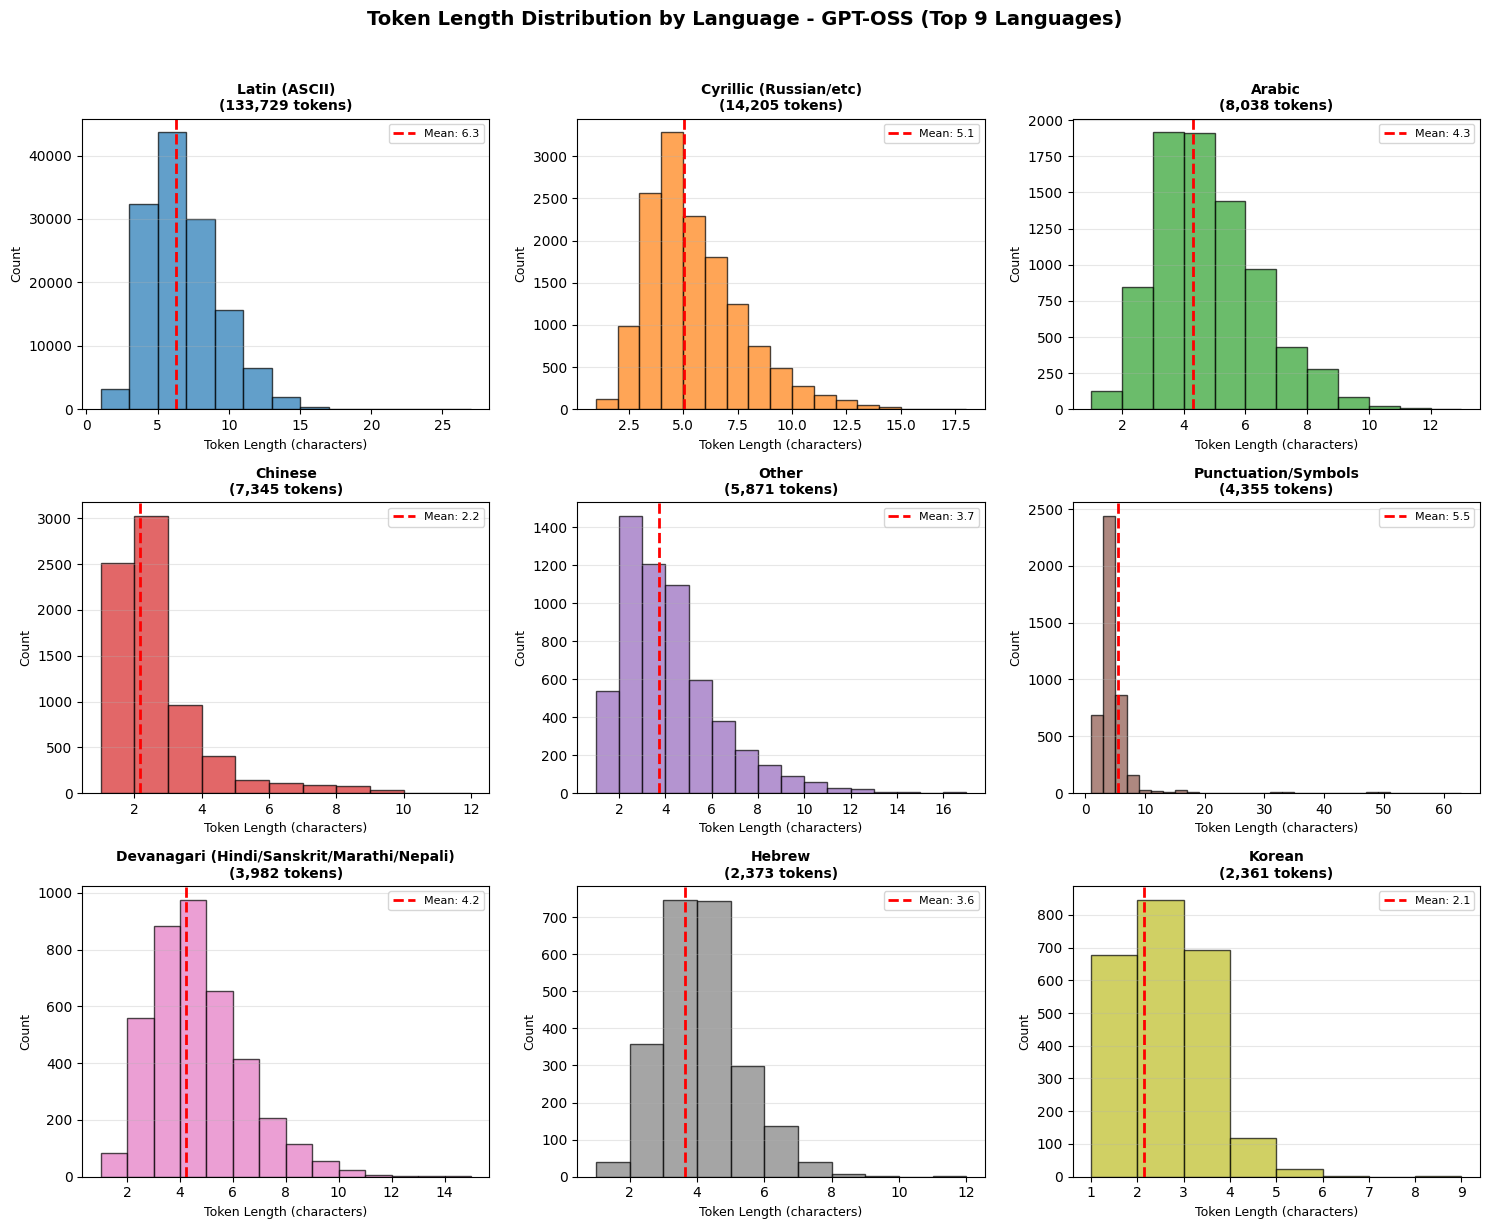

In [10]:
# Create histograms for token length distribution by language (GPT-OSS)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Top 9 languages by token count
gptoss_top_languages = gptoss_sorted_languages[:9]

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, (lang, lengths) in enumerate(gptoss_top_languages):
    ax = axes[idx]
    
    # Create histogram with better binning
    max_len = max(lengths)
    if max_len <= 20:
        bins = range(1, max_len + 2)
    else:
        bins = np.arange(1, min(max_len + 2, 65), 2)
    
    counts, bin_edges, patches = ax.hist(lengths, bins=bins, color=colors[idx], 
                                          edgecolor='black', alpha=0.7)
    
    ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Token Length (characters)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean line
    mean_len = np.mean(lengths)
    ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
    ax.legend(fontsize=8)

plt.suptitle("Token Length Distribution by Language - GPT-OSS (Top 9 Languages)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Indic Languages - Token Length Distribution Histograms (GPT-OSS)

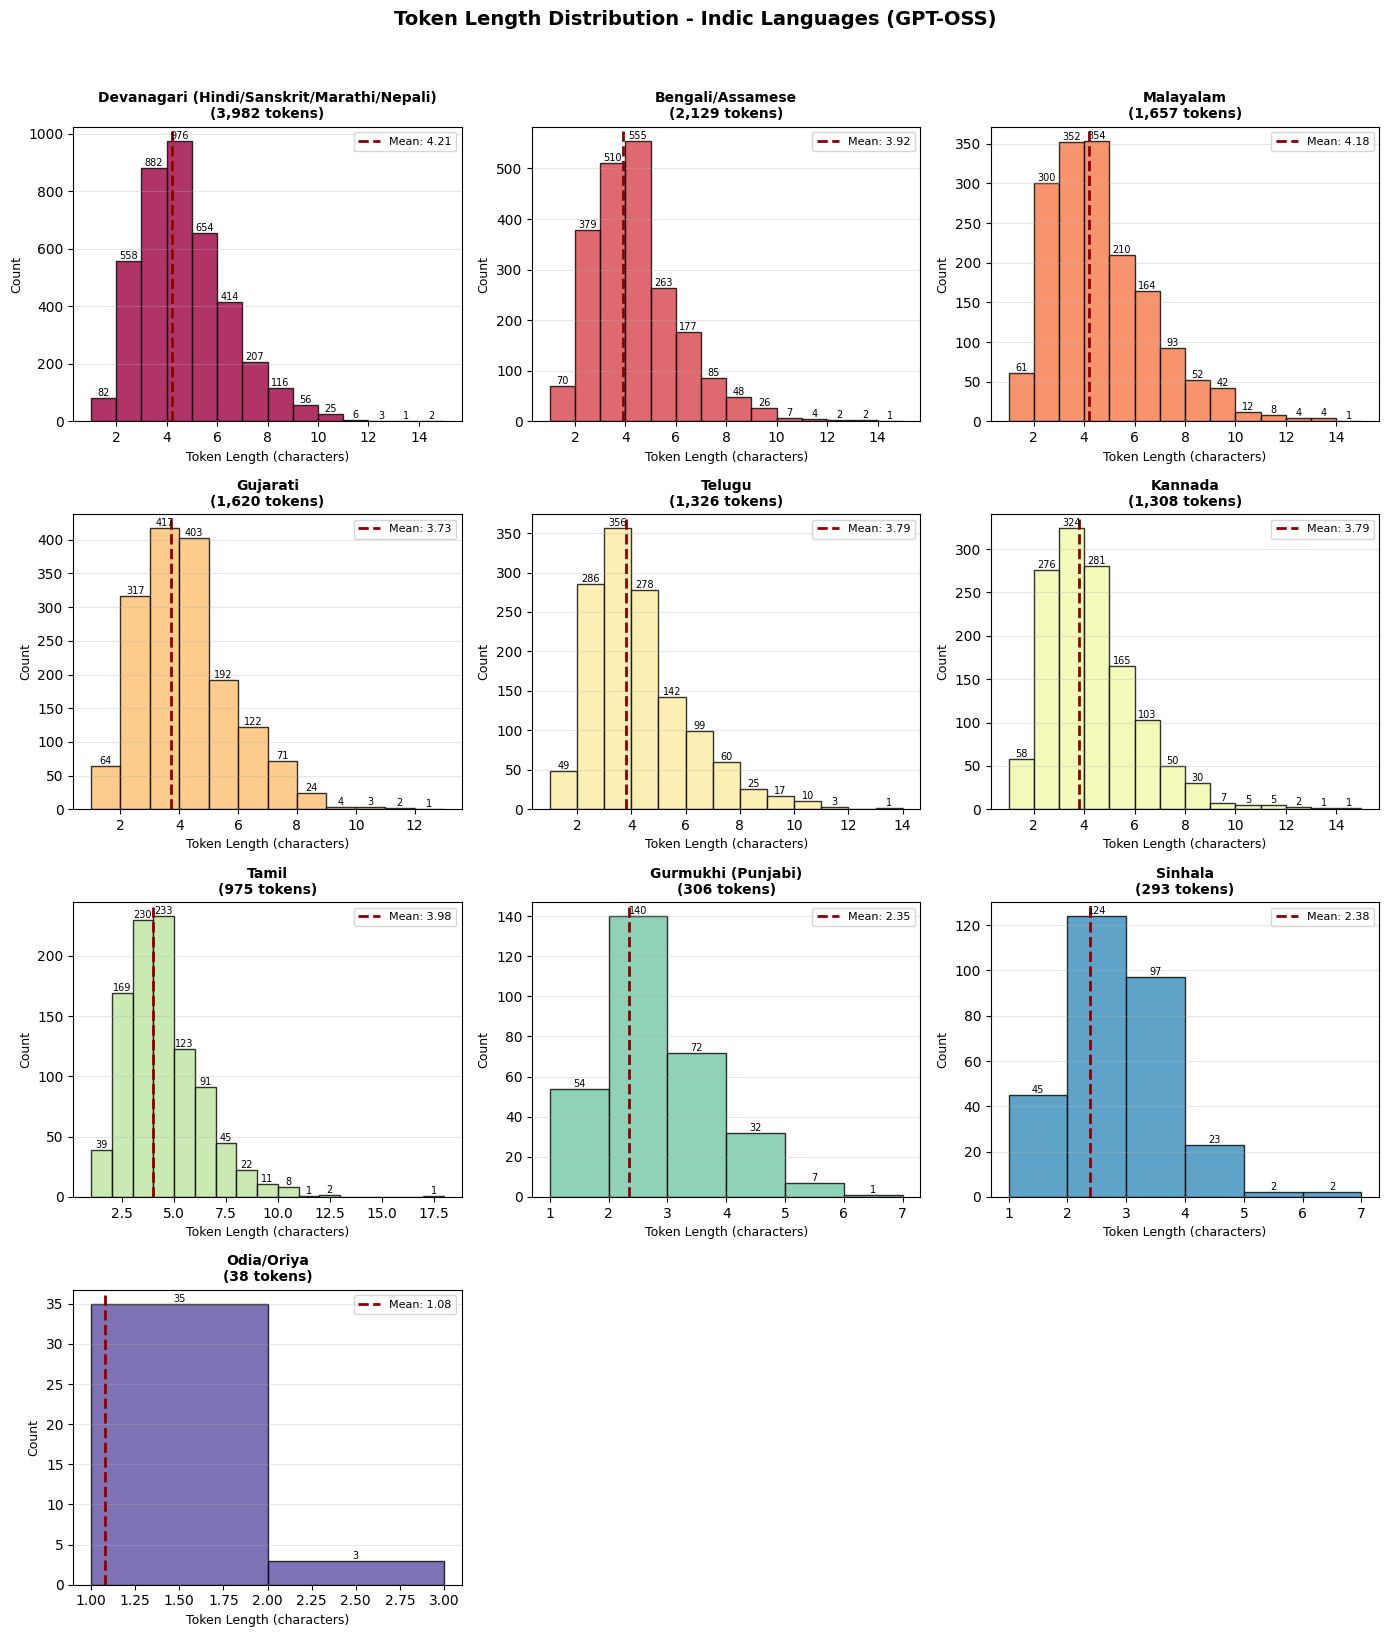


INDIC LANGUAGES (GPT-OSS) - DETAILED STATISTICS
Language                                         Count     Mean    Max
----------------------------------------------------------------------
Devanagari (Hindi/Sanskrit/Marathi/Nepali)       3,982     4.21     14
Bengali/Assamese                                 2,129     3.92     14
Malayalam                                        1,657     4.18     14
Gujarati                                         1,620     3.73     12
Telugu                                           1,326     3.79     13
Kannada                                          1,308     3.79     14
Tamil                                              975     3.98     17
Gurmukhi (Punjabi)                                 306     2.35      6
Sinhala                                            293     2.38      6
Odia/Oriya                                          38     1.08      2


In [11]:
# Indic Languages Token Length Distribution (GPT-OSS)
gptoss_indic_scripts_list = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

# Filter to only Indic languages that have tokens
gptoss_indic_data = [(lang, lengths) for lang, lengths in gptoss_language_token_lengths.items() 
                      if lang in gptoss_indic_scripts_list and len(lengths) > 0]
gptoss_indic_data.sort(key=lambda x: len(x[1]), reverse=True)

if gptoss_indic_data:
    n_indic = len(gptoss_indic_data)
    n_cols = 3
    n_rows = (n_indic + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    indic_colors = plt.cm.Spectral(np.linspace(0, 1, n_indic))
    
    for idx, (lang, lengths) in enumerate(gptoss_indic_data):
        ax = axes[idx]
        
        # Create histogram
        max_len = max(lengths)
        bins = range(1, max_len + 2)
        
        counts, bin_edges, patches = ax.hist(lengths, bins=bins, 
                                              color=indic_colors[idx], 
                                              edgecolor='black', alpha=0.8)
        
        ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
        ax.set_xlabel("Token Length (characters)", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        # Add mean line
        mean_len = np.mean(lengths)
        ax.axvline(mean_len, color='darkred', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_len:.2f}')
        ax.legend(fontsize=8)
        
        # Add count annotations on bars
        for i, (count, patch) in enumerate(zip(counts, patches)):
            if count > 0:
                ax.annotate(f'{int(count)}', 
                           xy=(patch.get_x() + patch.get_width()/2, count),
                           ha='center', va='bottom', fontsize=7)
    
    # Hide empty subplots
    for idx in range(len(gptoss_indic_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Token Length Distribution - Indic Languages (GPT-OSS)", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "=" * 80)
    print("INDIC LANGUAGES (GPT-OSS) - DETAILED STATISTICS")
    print("=" * 80)
    print(f"{'Language':<45} {'Count':>8} {'Mean':>8} {'Max':>6}")
    print("-" * 70)
    
    for lang, lengths in gptoss_indic_data:
        print(f"{lang:<45} {len(lengths):>8,} {np.mean(lengths):>8.2f} {max(lengths):>6}")
else:
    print("No Indic language tokens found in the GPT-OSS vocabulary.")

## 6. Stacked Bar Chart - All Languages (GPT-OSS)

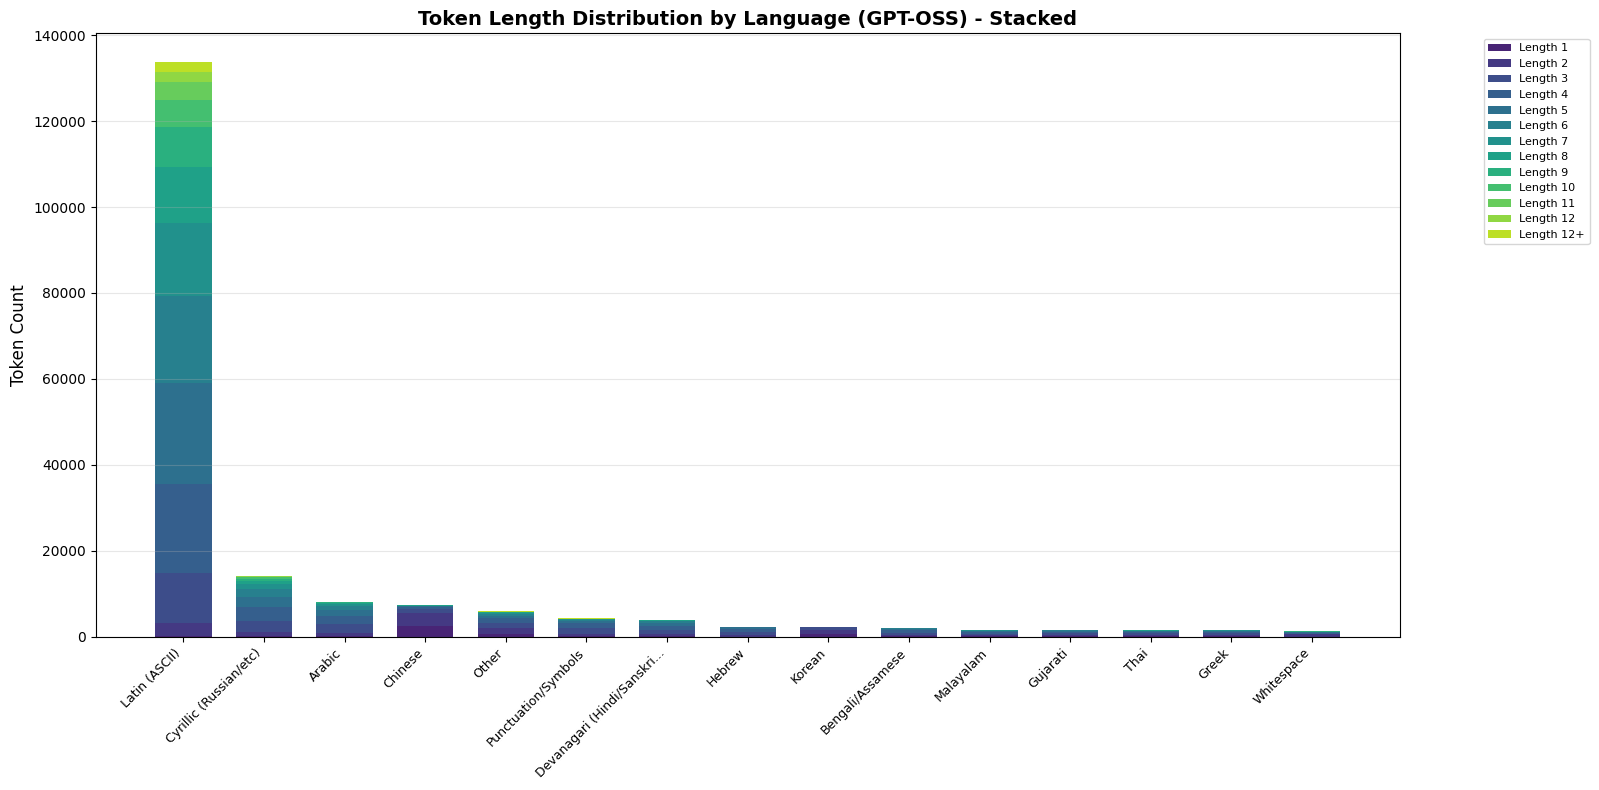

In [12]:
# Create a detailed grouped bar chart showing length distribution for all major languages (GPT-OSS)
gptoss_major_languages = [lang for lang, lengths in gptoss_sorted_languages if len(lengths) >= 50][:15]

# Get the length distribution for each language
max_length_to_show = 12  # Show lengths 1 to 12

gptoss_length_data = {}
for lang in gptoss_major_languages:
    lengths = gptoss_language_token_lengths[lang]
    length_counts = defaultdict(int)
    for l in lengths:
        if l <= max_length_to_show:
            length_counts[l] += 1
        else:
            length_counts[max_length_to_show + 1] += 1  # "12+" bucket
    gptoss_length_data[lang] = length_counts

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(gptoss_major_languages))
width = 0.7

# Colors for different lengths
length_colors = plt.cm.viridis(np.linspace(0.1, 0.9, max_length_to_show + 1))

bottom = np.zeros(len(gptoss_major_languages))

for length_val in range(1, max_length_to_show + 2):
    counts = [gptoss_length_data[lang].get(length_val, 0) for lang in gptoss_major_languages]
    label = f"Length {length_val}" if length_val <= max_length_to_show else f"Length {max_length_to_show}+"
    ax.bar(x, counts, width, bottom=bottom, label=label, color=length_colors[length_val - 1])
    bottom += counts

ax.set_ylabel('Token Count', fontsize=12)
ax.set_title('Token Length Distribution by Language (GPT-OSS) - Stacked', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([lang[:25] + "..." if len(lang) > 25 else lang for lang in gptoss_major_languages], 
                    rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary Comparison: DeepSeek V3 vs GPT-OSS

In [16]:
# Summary comparison between DeepSeek V3 and GPT-OSS tokenizers
print("=" * 90)
print("TOKENIZER COMPARISON: DeepSeek V3 vs GPT-OSS")
print("=" * 90)

print(f"\n{'Metric':<40} {'DeepSeek V3':>20} {'GPT-OSS':>20}")
print("-" * 82)

# Load DeepSeek data if not already loaded
try:
    ds_vocab_size = len(vocab)
except:
    ds_vocab_size = "N/A (run DS cells first)"

print(f"{'Total vocabulary size':<40} {ds_vocab_size:>20,} {len(gptoss_vocab):>20,}")

# Compare Indic language coverage
ds_indic_total = sum(len(decoded_classifications.get(s, [])) for s in gptoss_indic_scripts_list) if 'decoded_classifications' in dir() else "N/A"
gptoss_indic_total = sum(len(gptoss_decoded_classifications.get(s, [])) for s in gptoss_indic_scripts_list)

print(f"{'Total Indic tokens':<40} {ds_indic_total:>20,} {gptoss_indic_total:>20,}")

if isinstance(ds_indic_total, int):
    ds_indic_pct = (ds_indic_total / ds_vocab_size) * 100
    gptoss_indic_pct = (gptoss_indic_total / len(gptoss_vocab)) * 100
    print(f"{'Indic tokens (%)':<40} {ds_indic_pct:>19.2f}% {gptoss_indic_pct:>19.2f}%")

print("\n" + "-" * 82)
print("Indic Language Breakdown:")
print("-" * 82)
print(f"{'Language':<45} {'DeepSeek V3':>15} {'GPT-OSS':>15}")
print("-" * 82)

for script in gptoss_indic_scripts_list:
    try:
        ds_count = len(decoded_classifications.get(script, []))
    except:
        ds_count = "N/A"
    gptoss_count = len(gptoss_decoded_classifications.get(script, []))
    
    if isinstance(ds_count, int):
        print(f"{script:<45} {ds_count:>15,} {gptoss_count:>15,}")
    else:
        print(f"{script:<45} {ds_count:>15} {gptoss_count:>15,}")

TOKENIZER COMPARISON: DeepSeek V3 vs GPT-OSS

Metric                                            DeepSeek V3              GPT-OSS
----------------------------------------------------------------------------------
Total vocabulary size                                 128,000              199,998
Total Indic tokens                                      1,473               13,634
Indic tokens (%)                                        1.15%                6.82%

----------------------------------------------------------------------------------
Indic Language Breakdown:
----------------------------------------------------------------------------------
Language                                          DeepSeek V3         GPT-OSS
----------------------------------------------------------------------------------
Devanagari (Hindi/Sanskrit/Marathi/Nepali)                258           3,982
Bengali/Assamese                                          806           2,129
Tamil                        

# Qwen Tokenizer Analysis

This section performs the same analysis on the Qwen tokenizer (qwen_tokenizer.json).

## 1. Load Qwen Tokenizer and Basic Stats

In [17]:
# Load Qwen tokenizer
import json
from pathlib import Path

qwen_file_path = Path("d:/work/explore/tokenizer/qwen_tokenizer.json")

with open(qwen_file_path, 'r', encoding='utf-8') as f:
    qwen_tokenizer_data = json.load(f)

# Extract vocabulary (tokens only, not merges)
qwen_vocab = qwen_tokenizer_data['model']['vocab']

print(f"Total number of tokens in Qwen vocabulary: {len(qwen_vocab):,}")

Total number of tokens in Qwen vocabulary: 151,643


## 2. Largest Token Analysis

In [18]:
# Find the largest token by character length (Qwen)
qwen_largest_token = ""
qwen_largest_token_id = 0
qwen_largest_token_length = 0

for token, token_id in qwen_vocab.items():
    if len(token) > qwen_largest_token_length:
        qwen_largest_token = token
        qwen_largest_token_id = token_id
        qwen_largest_token_length = len(token)

print("Largest Token Analysis (Qwen):")
print("=" * 60)
print(f"Token ID: {qwen_largest_token_id}")
print(f"Token Length: {qwen_largest_token_length} characters")
print(f"Token Content: {repr(qwen_largest_token)[:100]}...")

# Top 10 longest tokens
qwen_sorted_by_length = sorted(qwen_vocab.items(), key=lambda x: len(x[0]), reverse=True)[:10]
print(f"\nTop 10 Longest Tokens:")
print("=" * 60)
for i, (token, tid) in enumerate(qwen_sorted_by_length, 1):
    print(f"{i:2d}. ID: {tid:6d} | Length: {len(token):3d} | Token: {repr(token)[:60]}...")

Largest Token Analysis (Qwen):
Token ID: 56940
Token Length: 128 characters
Token Content: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...

Top 10 Longest Tokens:
 1. ID:  56940 | Length: 128 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 2. ID:  89180 | Length: 114 | Token: '//---------------------------------------------------------...
 3. ID:  66207 | Length: 113 | Token: 'Ġ----------------------------------------------------------...
 4. ID:  56342 | Length:  98 | Token: '//---------------------------------------------------------...
 5. ID:  59809 | Length:  97 | Token: 'Ġ----------------------------------------------------------...
 6. ID:  86544 | Length:  97 | Token: '/**********************************************************...
 7. ID:  60629 | Length:  96 | Token: '///////////////////////////////////////////////////////////...
 8. ID:  98474 | Length:  96 | Token: '----------------------------

## 3. Language Breakdown Analysis

In [19]:
# Qwen uses byte-level BPE encoding - we need to decode tokens first
from collections import Counter, defaultdict

# Create byte decoder (same as GPT-2/DeepSeek/GPT-OSS)
def qwen_create_byte_decoder():
    """Create a mapping from GPT-2/byte-level BPE characters back to bytes."""
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(cs, bs))

qwen_byte_decoder = qwen_create_byte_decoder()

def qwen_decode_bpe_token(token):
    """Decode a byte-level BPE token back to the original text."""
    try:
        bytes_list = [qwen_byte_decoder.get(c, ord(c)) for c in token]
        return bytes(bytes_list).decode('utf-8', errors='replace')
    except:
        return token

def qwen_classify_decoded_token(decoded):
    """Classify a decoded token by its Unicode script."""
    scripts = Counter()
    for char in decoded:
        if char == '�':  # Replacement character
            continue
        cp = ord(char)
        
        if cp < 128:
            if char.isalpha():
                script = "Latin (ASCII)"
            elif char.isdigit():
                script = "Digits"
            elif char.isspace():
                script = "Whitespace"
            else:
                script = "Punctuation/Symbols"
        elif 0x4E00 <= cp <= 0x9FFF or 0x3400 <= cp <= 0x4DBF or 0x20000 <= cp <= 0x2A6DF:
            script = "Chinese"
        elif 0x3040 <= cp <= 0x309F:
            script = "Japanese (Hiragana)"
        elif 0x30A0 <= cp <= 0x30FF:
            script = "Japanese (Katakana)"
        elif 0xAC00 <= cp <= 0xD7AF or 0x1100 <= cp <= 0x11FF:
            script = "Korean"
        elif 0x0400 <= cp <= 0x04FF:
            script = "Cyrillic (Russian/etc)"
        elif 0x0600 <= cp <= 0x06FF or 0x0750 <= cp <= 0x077F:
            script = "Arabic"
        elif 0x0590 <= cp <= 0x05FF:
            script = "Hebrew"
        elif 0x0E00 <= cp <= 0x0E7F:
            script = "Thai"
        elif 0x0100 <= cp <= 0x024F:
            script = "Latin Extended"
        elif 0x0370 <= cp <= 0x03FF:
            script = "Greek"
        elif 0x1E00 <= cp <= 0x1EFF:
            script = "Vietnamese"
        # Indic scripts
        elif 0x0900 <= cp <= 0x097F:
            script = "Devanagari (Hindi/Sanskrit/Marathi/Nepali)"
        elif 0x0980 <= cp <= 0x09FF:
            script = "Bengali/Assamese"
        elif 0x0A00 <= cp <= 0x0A7F:
            script = "Gurmukhi (Punjabi)"
        elif 0x0A80 <= cp <= 0x0AFF:
            script = "Gujarati"
        elif 0x0B00 <= cp <= 0x0B7F:
            script = "Odia/Oriya"
        elif 0x0B80 <= cp <= 0x0BFF:
            script = "Tamil"
        elif 0x0C00 <= cp <= 0x0C7F:
            script = "Telugu"
        elif 0x0C80 <= cp <= 0x0CFF:
            script = "Kannada"
        elif 0x0D00 <= cp <= 0x0D7F:
            script = "Malayalam"
        elif 0x0D80 <= cp <= 0x0DFF:
            script = "Sinhala"
        elif cp >= 0x80 and cp <= 0xFF:
            script = "Byte Fragments (Partial UTF-8)"
        else:
            script = "Other"
        
        scripts[script] += 1
    
    if not scripts:
        return "Unknown"
    
    # Return dominant script (prefer non-ASCII for mixed)
    non_trivial = {k: v for k, v in scripts.items() 
                   if k not in ["Whitespace", "Punctuation/Symbols", "Digits", "Byte Fragments (Partial UTF-8)"]}
    if non_trivial:
        return max(non_trivial.items(), key=lambda x: x[1])[0]
    return max(scripts.items(), key=lambda x: x[1])[0]

# Classify all Qwen tokens using proper decoding
qwen_decoded_classifications = defaultdict(list)

for token, token_id in qwen_vocab.items():
    # Decode the byte-level BPE token
    decoded = qwen_decode_bpe_token(token)
    script = qwen_classify_decoded_token(decoded)
    qwen_decoded_classifications[script].append((token, token_id, decoded))

# Sort by count and display
qwen_sorted_classifications = sorted(qwen_decoded_classifications.items(), 
                                       key=lambda x: len(x[1]), reverse=True)

print("Token Distribution by Script/Language (Qwen):")
print("=" * 70)
qwen_total_tokens = len(qwen_vocab)
for script, tokens in qwen_sorted_classifications:
    count = len(tokens)
    percentage = (count / qwen_total_tokens) * 100
    print(f"{script:45s}: {count:6,} tokens ({percentage:5.2f}%)")

Token Distribution by Script/Language (Qwen):
Latin (ASCII)                                : 93,525 tokens (61.67%)
Chinese                                      : 25,463 tokens (16.79%)
Other                                        :  5,220 tokens ( 3.44%)
Punctuation/Symbols                          :  4,894 tokens ( 3.23%)
Cyrillic (Russian/etc)                       :  4,129 tokens ( 2.72%)
Arabic                                       :  3,643 tokens ( 2.40%)
Korean                                       :  3,544 tokens ( 2.34%)
Hebrew                                       :  3,164 tokens ( 2.09%)
Thai                                         :  2,571 tokens ( 1.70%)
Whitespace                                   :  1,221 tokens ( 0.81%)
Japanese (Hiragana)                          :  1,181 tokens ( 0.78%)
Unknown                                      :  1,141 tokens ( 0.75%)
Japanese (Katakana)                          :    595 tokens ( 0.39%)
Latin Extended                              

## 4. Indic Languages Focus (Qwen)

In [20]:
# Special focus on Indic languages in Qwen tokenizer
qwen_indic_scripts = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

print("=" * 80)
print("INDIC LANGUAGES IN QWEN TOKENIZER")
print("=" * 80)

qwen_total_indic = 0
qwen_indic_summary = []

for script in qwen_indic_scripts:
    tokens = qwen_decoded_classifications.get(script, [])
    count = len(tokens)
    qwen_total_indic += count
    if count > 0:
        qwen_indic_summary.append((script, count, tokens))

print(f"\nTotal Indic language tokens: {qwen_total_indic:,}")
print(f"Percentage of vocabulary: {(qwen_total_indic / qwen_total_tokens) * 100:.2f}%")

print("\n" + "-" * 80)
print("Breakdown by Indic Script:")
print("-" * 80)

for script, count, tokens in sorted(qwen_indic_summary, key=lambda x: x[1], reverse=True):
    print(f"\n{script}: {count} tokens")
    
    # Show sample tokens (tokens now contains (raw_token, token_id, decoded))
    samples = tokens[:5]
    print("  Sample tokens:")
    for raw_token, tid, decoded in samples:
        print(f"    ID {tid:6d}: {repr(decoded)}")
    
    # Show longest tokens by decoded length
    sorted_tokens = sorted(tokens, key=lambda x: len(x[2]), reverse=True)[:3]
    print("  Longest tokens:")
    for raw_token, tid, decoded in sorted_tokens:
        print(f"    ID {tid:6d}: len={len(decoded):2d}, {repr(decoded)}")

INDIC LANGUAGES IN QWEN TOKENIZER

Total Indic language tokens: 279
Percentage of vocabulary: 0.18%

--------------------------------------------------------------------------------
Breakdown by Indic Script:
--------------------------------------------------------------------------------

Devanagari (Hindi/Sanskrit/Marathi/Nepali): 71 tokens
  Sample tokens:
    ID  23868: 'ा'
    ID  29607: '्'
    ID  30484: '्�'
    ID  31411: 'ा�'
    ID  34370: 'े'
  Longest tokens:
    ID  30484: len= 2, '्�'
    ID  31411: len= 2, 'ा�'
    ID  42311: len= 2, 'ि�'

Bengali/Assamese: 47 tokens
  Sample tokens:
    ID  41312: 'া'
    ID  49128: 'া�'
    ID  52595: '্'
    ID  52806: '্�'
    ID  58908: 'ে'
  Longest tokens:
    ID  49128: len= 2, 'া�'
    ID  52806: len= 2, '্�'
    ID  80178: len= 2, 'ি�'

Malayalam: 33 tokens
  Sample tokens:
    ID  72567: '്'
    ID  84705: '്�'
    ID 146363: 'മ'
    ID 146367: 'യ'
    ID 146476: 'ല'
  Longest tokens:
    ID  84705: len= 2, '്�'
    ID  72567

## 5. Token Length Distribution by Language (Qwen)

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Collect token lengths by language/script for Qwen (using decoded length)
qwen_language_token_lengths = defaultdict(list)

for token, token_id in qwen_vocab.items():
    # Decode the token
    decoded = qwen_decode_bpe_token(token)
    token_len = len(decoded)
    
    if token_len == 0:
        continue
    
    script = qwen_classify_decoded_token(decoded)
    qwen_language_token_lengths[script].append(token_len)

# Sort languages by token count (descending)
qwen_sorted_languages = sorted(qwen_language_token_lengths.items(), key=lambda x: len(x[1]), reverse=True)

print("Token count and length stats by language/script (Qwen):")
print("-" * 80)
print(f"{'Script':<45} {'Tokens':>10} {'Avg Len':>10} {'Max Len':>10}")
print("-" * 80)
for lang, lengths in qwen_sorted_languages:
    avg_len = np.mean(lengths)
    max_len = max(lengths)
    print(f"{lang:<45} {len(lengths):>10,} {avg_len:>10.2f} {max_len:>10}")

Token count and length stats by language/script (Qwen):
--------------------------------------------------------------------------------
Script                                            Tokens    Avg Len    Max Len
--------------------------------------------------------------------------------
Latin (ASCII)                                     93,525       6.49         42
Chinese                                           25,463       1.92          7
Other                                              5,220       1.09         16
Punctuation/Symbols                                4,894       5.97        114
Cyrillic (Russian/etc)                             4,129       4.86         15
Arabic                                             3,643       3.99         12
Korean                                             3,544       1.46          5
Hebrew                                             3,164       3.94         10
Thai                                               2,571       4.29    

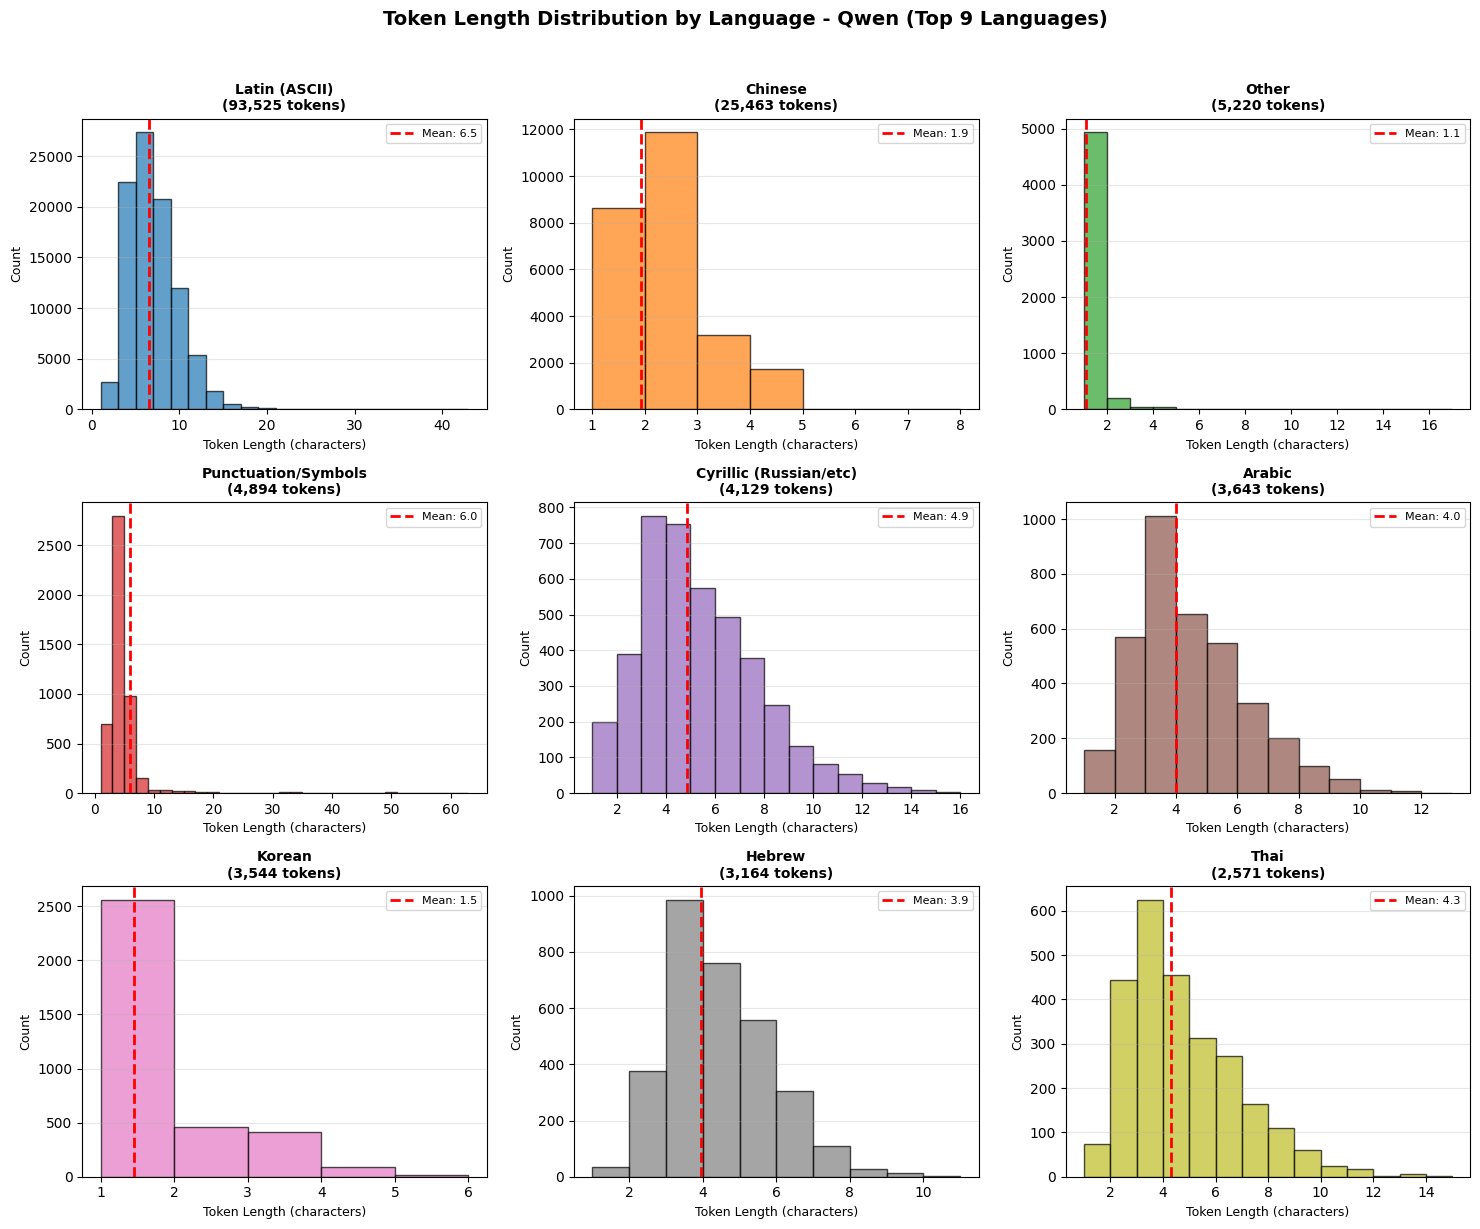

In [22]:
# Create histograms for token length distribution by language (Qwen)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Top 9 languages by token count
qwen_top_languages = qwen_sorted_languages[:9]

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, (lang, lengths) in enumerate(qwen_top_languages):
    ax = axes[idx]
    
    # Create histogram with better binning
    max_len = max(lengths)
    if max_len <= 20:
        bins = range(1, max_len + 2)
    else:
        bins = np.arange(1, min(max_len + 2, 65), 2)
    
    counts, bin_edges, patches = ax.hist(lengths, bins=bins, color=colors[idx], 
                                          edgecolor='black', alpha=0.7)
    
    ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Token Length (characters)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean line
    mean_len = np.mean(lengths)
    ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
    ax.legend(fontsize=8)

plt.suptitle("Token Length Distribution by Language - Qwen (Top 9 Languages)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Indic Languages - Token Length Distribution Histograms (Qwen)

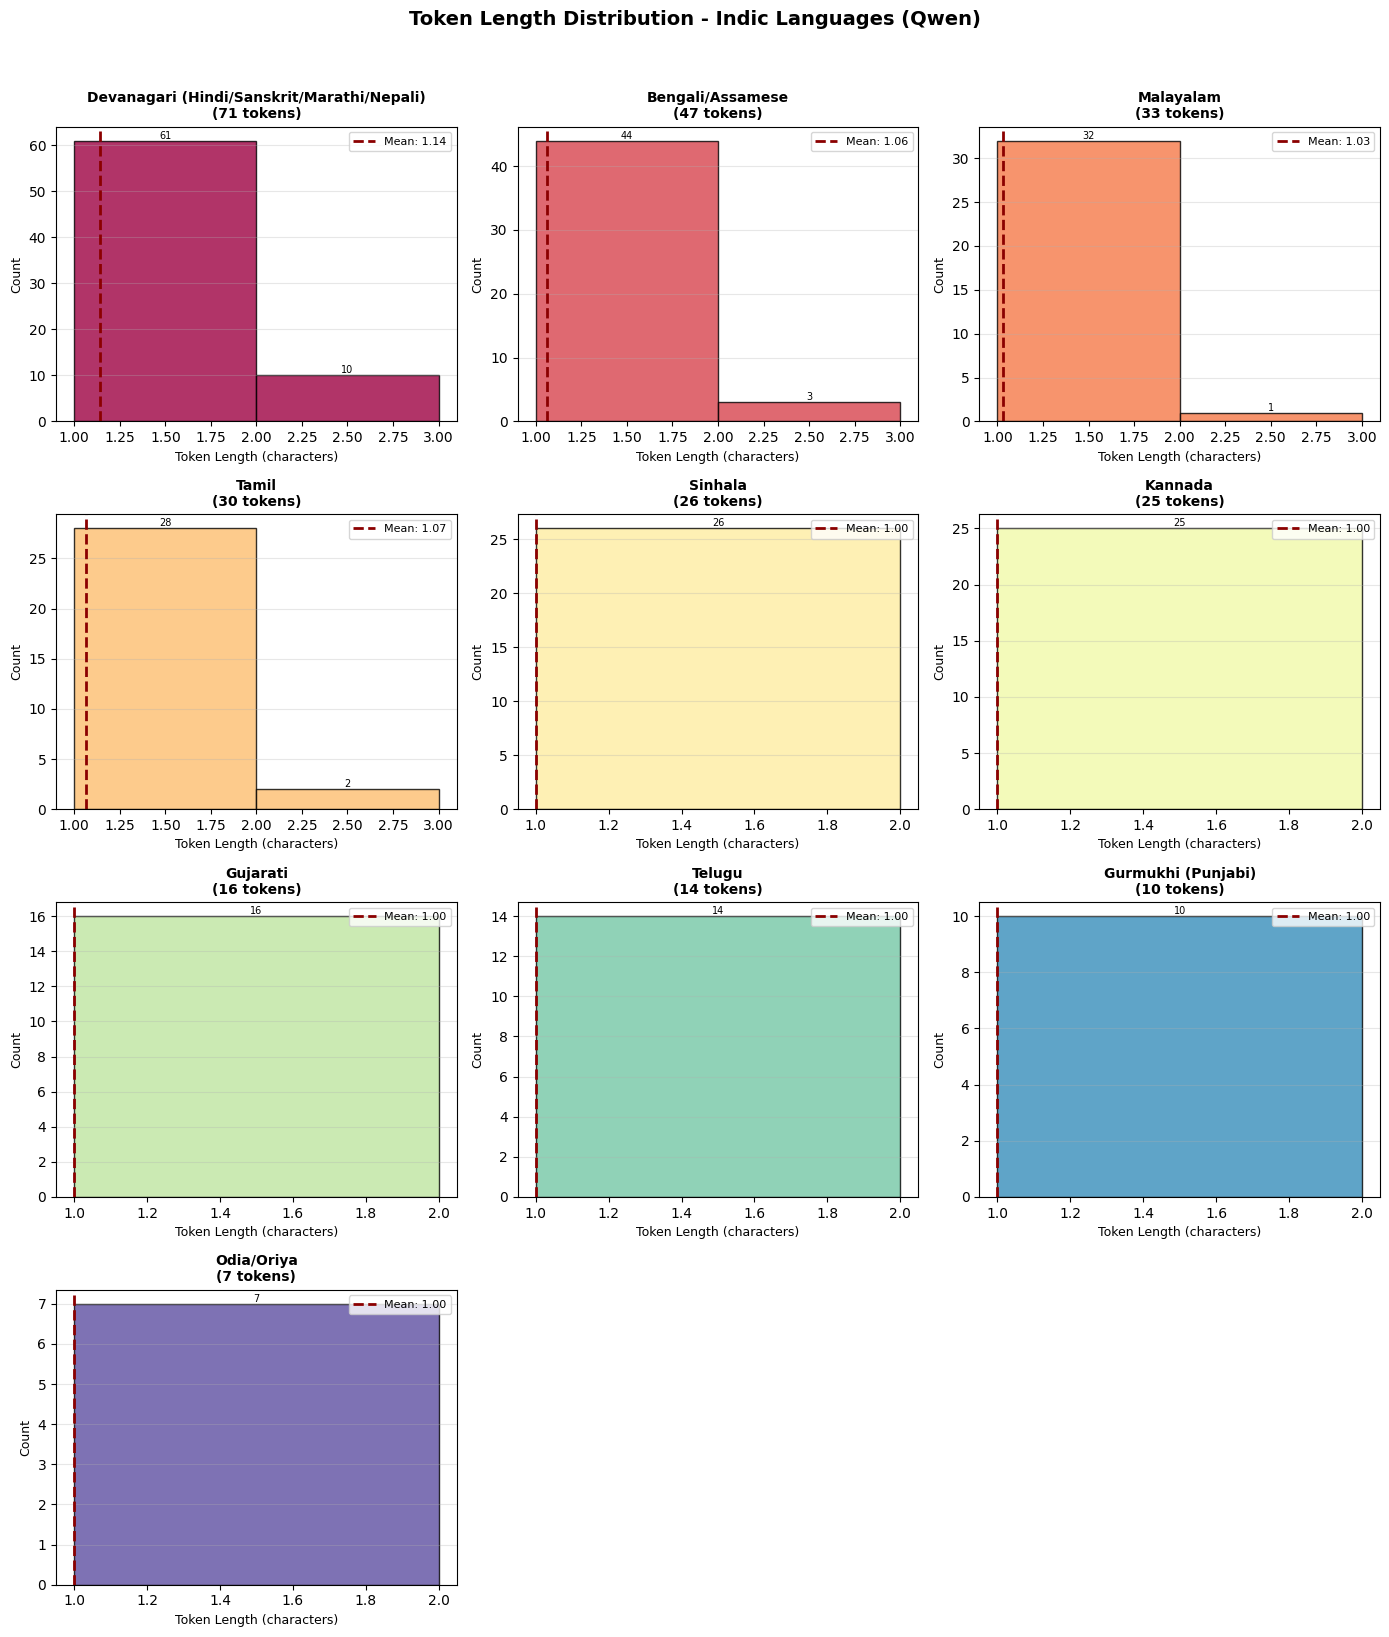


INDIC LANGUAGES (Qwen) - DETAILED STATISTICS
Language                                         Count     Mean    Max
----------------------------------------------------------------------
Devanagari (Hindi/Sanskrit/Marathi/Nepali)          71     1.14      2
Bengali/Assamese                                    47     1.06      2
Malayalam                                           33     1.03      2
Tamil                                               30     1.07      2
Sinhala                                             26     1.00      1
Kannada                                             25     1.00      1
Gujarati                                            16     1.00      1
Telugu                                              14     1.00      1
Gurmukhi (Punjabi)                                  10     1.00      1
Odia/Oriya                                           7     1.00      1


In [23]:
# Indic Languages Token Length Distribution (Qwen)
qwen_indic_scripts_list = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

# Filter to only Indic languages that have tokens
qwen_indic_data = [(lang, lengths) for lang, lengths in qwen_language_token_lengths.items() 
                    if lang in qwen_indic_scripts_list and len(lengths) > 0]
qwen_indic_data.sort(key=lambda x: len(x[1]), reverse=True)

if qwen_indic_data:
    n_indic = len(qwen_indic_data)
    n_cols = 3
    n_rows = (n_indic + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    indic_colors = plt.cm.Spectral(np.linspace(0, 1, n_indic))
    
    for idx, (lang, lengths) in enumerate(qwen_indic_data):
        ax = axes[idx]
        
        # Create histogram
        max_len = max(lengths)
        bins = range(1, max_len + 2)
        
        counts, bin_edges, patches = ax.hist(lengths, bins=bins, 
                                              color=indic_colors[idx], 
                                              edgecolor='black', alpha=0.8)
        
        ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
        ax.set_xlabel("Token Length (characters)", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        # Add mean line
        mean_len = np.mean(lengths)
        ax.axvline(mean_len, color='darkred', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_len:.2f}')
        ax.legend(fontsize=8)
        
        # Add count annotations on bars
        for i, (count, patch) in enumerate(zip(counts, patches)):
            if count > 0:
                ax.annotate(f'{int(count)}', 
                           xy=(patch.get_x() + patch.get_width()/2, count),
                           ha='center', va='bottom', fontsize=7)
    
    # Hide empty subplots
    for idx in range(len(qwen_indic_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Token Length Distribution - Indic Languages (Qwen)", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "=" * 80)
    print("INDIC LANGUAGES (Qwen) - DETAILED STATISTICS")
    print("=" * 80)
    print(f"{'Language':<45} {'Count':>8} {'Mean':>8} {'Max':>6}")
    print("-" * 70)
    
    for lang, lengths in qwen_indic_data:
        print(f"{lang:<45} {len(lengths):>8,} {np.mean(lengths):>8.2f} {max(lengths):>6}")
else:
    print("No Indic language tokens found in the Qwen vocabulary.")

## 6. Stacked Bar Chart - All Languages (Qwen)

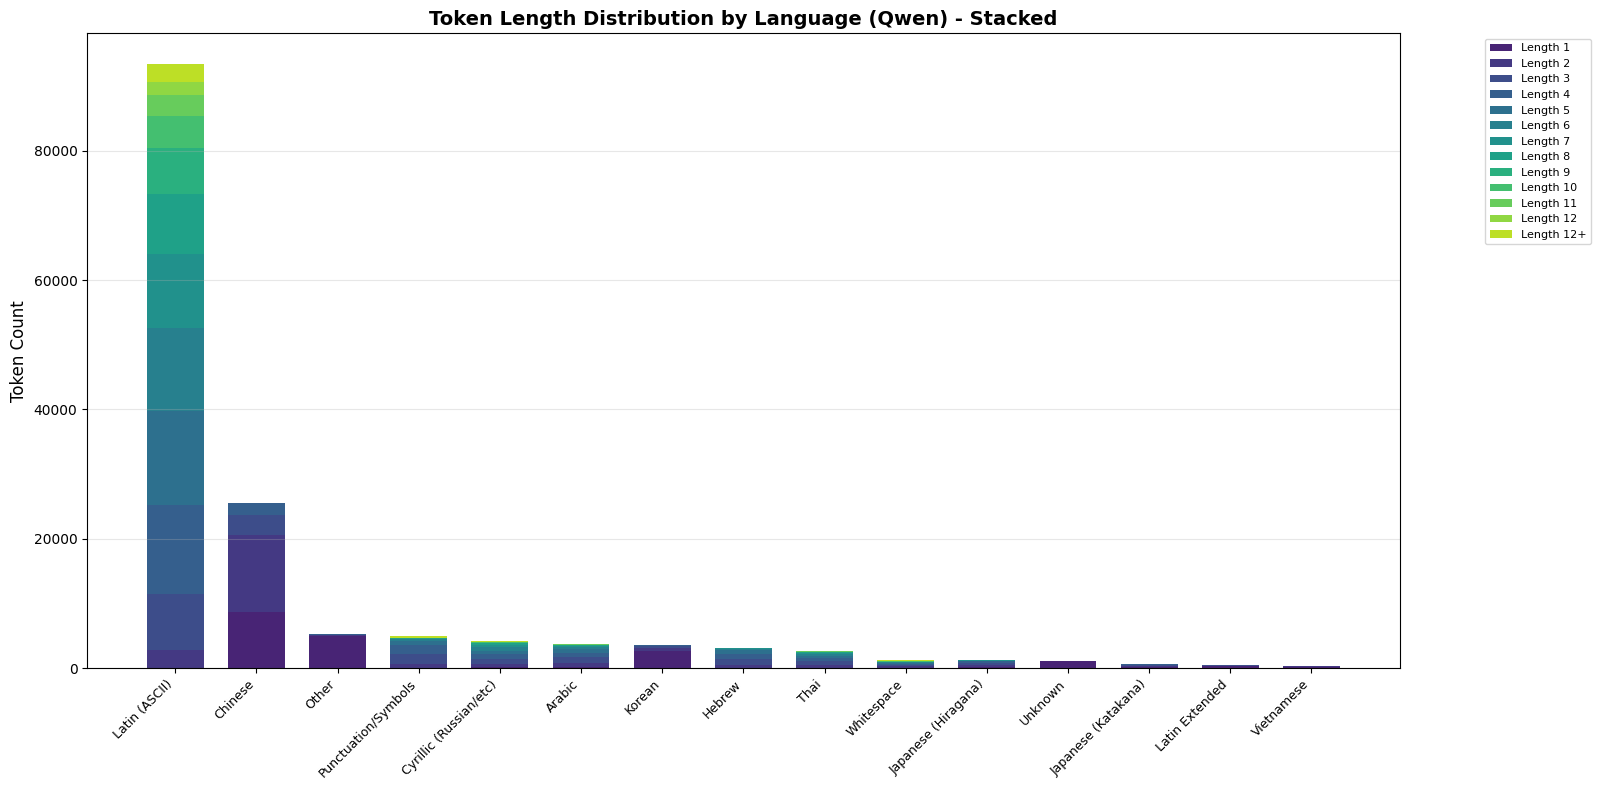

In [24]:
# Create a detailed grouped bar chart showing length distribution for all major languages (Qwen)
qwen_major_languages = [lang for lang, lengths in qwen_sorted_languages if len(lengths) >= 50][:15]

# Get the length distribution for each language
max_length_to_show = 12  # Show lengths 1 to 12

qwen_length_data = {}
for lang in qwen_major_languages:
    lengths = qwen_language_token_lengths[lang]
    length_counts = defaultdict(int)
    for l in lengths:
        if l <= max_length_to_show:
            length_counts[l] += 1
        else:
            length_counts[max_length_to_show + 1] += 1  # "12+" bucket
    qwen_length_data[lang] = length_counts

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(qwen_major_languages))
width = 0.7

# Colors for different lengths
length_colors = plt.cm.viridis(np.linspace(0.1, 0.9, max_length_to_show + 1))

bottom = np.zeros(len(qwen_major_languages))

for length_val in range(1, max_length_to_show + 2):
    counts = [qwen_length_data[lang].get(length_val, 0) for lang in qwen_major_languages]
    label = f"Length {length_val}" if length_val <= max_length_to_show else f"Length {max_length_to_show}+"
    ax.bar(x, counts, width, bottom=bottom, label=label, color=length_colors[length_val - 1])
    bottom += counts

ax.set_ylabel('Token Count', fontsize=12)
ax.set_title('Token Length Distribution by Language (Qwen) - Stacked', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([lang[:25] + "..." if len(lang) > 25 else lang for lang in qwen_major_languages], 
                    rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary Comparison: DeepSeek V3 vs GPT-OSS vs Qwen

In [27]:
# Summary comparison between DeepSeek V3, GPT-OSS, and Qwen tokenizers
print("=" * 110)
print("TOKENIZER COMPARISON: DeepSeek V3 vs GPT-OSS vs Qwen")
print("=" * 110)

print(f"\n{'Metric':<45} {'DeepSeek V3':>20} {'GPT-OSS':>20} {'Qwen':>20}")
print("-" * 107)

# Vocabulary sizes
ds_vocab_size = len(vocab) if 'vocab' in dir() else "N/A"
gptoss_vocab_size = len(gptoss_vocab) if 'gptoss_vocab' in dir() else "N/A"
qwen_vocab_size = len(qwen_vocab)

print(f"{'Total vocabulary size':<45} {ds_vocab_size:>20,} {gptoss_vocab_size:>20,} {qwen_vocab_size:>20,}")

# Indic language totals
indic_scripts_list = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

ds_indic_total = sum(len(decoded_classifications.get(s, [])) for s in indic_scripts_list) if 'decoded_classifications' in dir() else 0
gptoss_indic_total = sum(len(gptoss_decoded_classifications.get(s, [])) for s in indic_scripts_list) if 'gptoss_decoded_classifications' in dir() else 0
qwen_indic_total = sum(len(qwen_decoded_classifications.get(s, [])) for s in indic_scripts_list)

print(f"{'Total Indic tokens':<45} {ds_indic_total:>20,} {gptoss_indic_total:>20,} {qwen_indic_total:>20,}")

if isinstance(ds_vocab_size, int) and isinstance(gptoss_vocab_size, int):
    ds_indic_pct = (ds_indic_total / ds_vocab_size) * 100
    gptoss_indic_pct = (gptoss_indic_total / gptoss_vocab_size) * 100
    qwen_indic_pct = (qwen_indic_total / qwen_vocab_size) * 100
    print(f"{'Indic tokens (%)':<45} {ds_indic_pct:>19.2f}% {gptoss_indic_pct:>19.2f}% {qwen_indic_pct:>19.2f}%")

# Count tokens with length > 32
ds_long_tokens = sum(1 for token in vocab.keys() if len(decode_bpe_token(token)) > 32) if 'vocab' in dir() else 0
gptoss_long_tokens = sum(1 for token in gptoss_vocab.keys() if len(gptoss_decode_bpe_token(token)) > 32) if 'gptoss_vocab' in dir() else 0
qwen_long_tokens = sum(1 for token in qwen_vocab.keys() if len(qwen_decode_bpe_token(token)) > 32)

print(f"{'Tokens with length > 32':<45} {ds_long_tokens:>20,} {gptoss_long_tokens:>20,} {qwen_long_tokens:>20,}")

if isinstance(ds_vocab_size, int) and isinstance(gptoss_vocab_size, int):
    ds_long_pct = (ds_long_tokens / ds_vocab_size) * 100
    gptoss_long_pct = (gptoss_long_tokens / gptoss_vocab_size) * 100
    qwen_long_pct = (qwen_long_tokens / qwen_vocab_size) * 100
    print(f"{'Long tokens (>32) (%)':<45} {ds_long_pct:>19.2f}% {gptoss_long_pct:>19.2f}% {qwen_long_pct:>19.2f}%")

print("\n" + "-" * 107)
print("Indic Language Breakdown:")
print("-" * 107)
print(f"{'Language':<45} {'DeepSeek V3':>20} {'GPT-OSS':>20} {'Qwen':>20}")
print("-" * 107)

for script in indic_scripts_list:
    ds_count = len(decoded_classifications.get(script, [])) if 'decoded_classifications' in dir() else 0
    gptoss_count = len(gptoss_decoded_classifications.get(script, [])) if 'gptoss_decoded_classifications' in dir() else 0
    qwen_count = len(qwen_decoded_classifications.get(script, []))
    
    print(f"{script:<45} {ds_count:>20,} {gptoss_count:>20,} {qwen_count:>20,}")

TOKENIZER COMPARISON: DeepSeek V3 vs GPT-OSS vs Qwen

Metric                                                 DeepSeek V3              GPT-OSS                 Qwen
-----------------------------------------------------------------------------------------------------------
Total vocabulary size                                      128,000              199,998              151,643
Total Indic tokens                                           1,473               13,634                  279
Indic tokens (%)                                             1.15%                6.82%                0.18%
Tokens with length > 32                                         56                  157                  211
Long tokens (>32) (%)                                        0.04%                0.08%                0.14%

-----------------------------------------------------------------------------------------------------------
Indic Language Breakdown:
-------------------------------------------------

# Mistral Tokenizer Analysis

This section performs the same analysis on the Mistral tokenizer (mistral_tokenizer.json).

## 1. Load Mistral Tokenizer and Basic Stats

In [28]:
# Load Mistral tokenizer
import json
from pathlib import Path

mistral_file_path = Path("d:/work/explore/tokenizer/mistral_tokenizer.json")

with open(mistral_file_path, 'r', encoding='utf-8') as f:
    mistral_tokenizer_data = json.load(f)

# Extract vocabulary (tokens only, not merges)
mistral_vocab = mistral_tokenizer_data['model']['vocab']

print(f"Total number of tokens in Mistral vocabulary: {len(mistral_vocab):,}")

Total number of tokens in Mistral vocabulary: 131,072


## 2. Largest Token Analysis

In [29]:
# Find the largest token by character length (Mistral)
mistral_largest_token = ""
mistral_largest_token_id = 0
mistral_largest_token_length = 0

for token, token_id in mistral_vocab.items():
    if len(token) > mistral_largest_token_length:
        mistral_largest_token = token
        mistral_largest_token_id = token_id
        mistral_largest_token_length = len(token)

print("Largest Token Analysis (Mistral):")
print("=" * 60)
print(f"Token ID: {mistral_largest_token_id}")
print(f"Token Length: {mistral_largest_token_length} characters")
print(f"Token Content: {repr(mistral_largest_token)[:100]}...")

# Top 10 longest tokens
mistral_sorted_by_length = sorted(mistral_vocab.items(), key=lambda x: len(x[0]), reverse=True)[:10]
print(f"\nTop 10 Longest Tokens:")
print("=" * 60)
for i, (token, tid) in enumerate(mistral_sorted_by_length, 1):
    print(f"{i:2d}. ID: {tid:6d} | Length: {len(token):3d} | Token: {repr(token)[:60]}...")

Largest Token Analysis (Mistral):
Token ID: 99679
Token Length: 76 characters
Token Content: '----------------------------------------------------------------------------'...

Top 10 Longest Tokens:
 1. ID:  99679 | Length:  76 | Token: '-----------------------------------------------------------...
 2. ID:  79343 | Length:  75 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 3. ID: 126218 | Length:  75 | Token: 'Ġ**********************************************************...
 4. ID:  93606 | Length:  74 | Token: 'Ġ**********************************************************...
 5. ID:  52603 | Length:  72 | Token: '***********************************************************...
 6. ID:  85449 | Length:  72 | Token: '-----------------------------------------------------------...
 7. ID: 109060 | Length:  71 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 8. ID:  88644 | Length:  67 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ

## 3. Language Breakdown Analysis

In [30]:
# Mistral uses byte-level BPE encoding - we need to decode tokens first
from collections import Counter, defaultdict

# Create byte decoder (same as GPT-2/DeepSeek/GPT-OSS/Qwen)
def mistral_create_byte_decoder():
    """Create a mapping from GPT-2/byte-level BPE characters back to bytes."""
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(cs, bs))

mistral_byte_decoder = mistral_create_byte_decoder()

def mistral_decode_bpe_token(token):
    """Decode a byte-level BPE token back to the original text."""
    try:
        bytes_list = [mistral_byte_decoder.get(c, ord(c)) for c in token]
        return bytes(bytes_list).decode('utf-8', errors='replace')
    except:
        return token

def mistral_classify_decoded_token(decoded):
    """Classify a decoded token by its Unicode script."""
    scripts = Counter()
    for char in decoded:
        if char == '�':  # Replacement character
            continue
        cp = ord(char)
        
        if cp < 128:
            if char.isalpha():
                script = "Latin (ASCII)"
            elif char.isdigit():
                script = "Digits"
            elif char.isspace():
                script = "Whitespace"
            else:
                script = "Punctuation/Symbols"
        elif 0x4E00 <= cp <= 0x9FFF or 0x3400 <= cp <= 0x4DBF or 0x20000 <= cp <= 0x2A6DF:
            script = "Chinese"
        elif 0x3040 <= cp <= 0x309F:
            script = "Japanese (Hiragana)"
        elif 0x30A0 <= cp <= 0x30FF:
            script = "Japanese (Katakana)"
        elif 0xAC00 <= cp <= 0xD7AF or 0x1100 <= cp <= 0x11FF:
            script = "Korean"
        elif 0x0400 <= cp <= 0x04FF:
            script = "Cyrillic (Russian/etc)"
        elif 0x0600 <= cp <= 0x06FF or 0x0750 <= cp <= 0x077F:
            script = "Arabic"
        elif 0x0590 <= cp <= 0x05FF:
            script = "Hebrew"
        elif 0x0E00 <= cp <= 0x0E7F:
            script = "Thai"
        elif 0x0100 <= cp <= 0x024F:
            script = "Latin Extended"
        elif 0x0370 <= cp <= 0x03FF:
            script = "Greek"
        elif 0x1E00 <= cp <= 0x1EFF:
            script = "Vietnamese"
        # Indic scripts
        elif 0x0900 <= cp <= 0x097F:
            script = "Devanagari (Hindi/Sanskrit/Marathi/Nepali)"
        elif 0x0980 <= cp <= 0x09FF:
            script = "Bengali/Assamese"
        elif 0x0A00 <= cp <= 0x0A7F:
            script = "Gurmukhi (Punjabi)"
        elif 0x0A80 <= cp <= 0x0AFF:
            script = "Gujarati"
        elif 0x0B00 <= cp <= 0x0B7F:
            script = "Odia/Oriya"
        elif 0x0B80 <= cp <= 0x0BFF:
            script = "Tamil"
        elif 0x0C00 <= cp <= 0x0C7F:
            script = "Telugu"
        elif 0x0C80 <= cp <= 0x0CFF:
            script = "Kannada"
        elif 0x0D00 <= cp <= 0x0D7F:
            script = "Malayalam"
        elif 0x0D80 <= cp <= 0x0DFF:
            script = "Sinhala"
        elif cp >= 0x80 and cp <= 0xFF:
            script = "Byte Fragments (Partial UTF-8)"
        else:
            script = "Other"
        
        scripts[script] += 1
    
    if not scripts:
        return "Unknown"
    
    # Return dominant script (prefer non-ASCII for mixed)
    non_trivial = {k: v for k, v in scripts.items() 
                   if k not in ["Whitespace", "Punctuation/Symbols", "Digits", "Byte Fragments (Partial UTF-8)"]}
    if non_trivial:
        return max(non_trivial.items(), key=lambda x: x[1])[0]
    return max(scripts.items(), key=lambda x: x[1])[0]

# Classify all Mistral tokens using proper decoding
mistral_decoded_classifications = defaultdict(list)

for token, token_id in mistral_vocab.items():
    # Decode the byte-level BPE token
    decoded = mistral_decode_bpe_token(token)
    script = mistral_classify_decoded_token(decoded)
    mistral_decoded_classifications[script].append((token, token_id, decoded))

# Sort by count and display
mistral_sorted_classifications = sorted(mistral_decoded_classifications.items(), 
                                          key=lambda x: len(x[1]), reverse=True)

print("Token Distribution by Script/Language (Mistral):")
print("=" * 70)
mistral_total_tokens = len(mistral_vocab)
for script, tokens in mistral_sorted_classifications:
    count = len(tokens)
    percentage = (count / mistral_total_tokens) * 100
    print(f"{script:45s}: {count:6,} tokens ({percentage:5.2f}%)")

Token Distribution by Script/Language (Mistral):
Latin (ASCII)                                : 88,503 tokens (67.52%)
Arabic                                       :  9,431 tokens ( 7.20%)
Cyrillic (Russian/etc)                       :  7,685 tokens ( 5.86%)
Korean                                       :  4,472 tokens ( 3.41%)
Chinese                                      :  3,589 tokens ( 2.74%)
Other                                        :  2,839 tokens ( 2.17%)
Punctuation/Symbols                          :  2,640 tokens ( 2.01%)
Devanagari (Hindi/Sanskrit/Marathi/Nepali)   :  1,565 tokens ( 1.19%)
Greek                                        :  1,504 tokens ( 1.15%)
Hebrew                                       :  1,002 tokens ( 0.76%)
Telugu                                       :    920 tokens ( 0.70%)
Japanese (Hiragana)                          :    885 tokens ( 0.68%)
Bengali/Assamese                             :    839 tokens ( 0.64%)
Unknown                                  

## 4. Indic Languages Focus (Mistral)

In [31]:
# Special focus on Indic languages in Mistral tokenizer
mistral_indic_scripts = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

print("=" * 80)
print("INDIC LANGUAGES IN MISTRAL TOKENIZER")
print("=" * 80)

mistral_total_indic = 0
mistral_indic_summary = []

for script in mistral_indic_scripts:
    tokens = mistral_decoded_classifications.get(script, [])
    count = len(tokens)
    mistral_total_indic += count
    if count > 0:
        mistral_indic_summary.append((script, count, tokens))

print(f"\nTotal Indic language tokens: {mistral_total_indic:,}")
print(f"Percentage of vocabulary: {(mistral_total_indic / mistral_total_tokens) * 100:.2f}%")

print("\n" + "-" * 80)
print("Breakdown by Indic Script:")
print("-" * 80)

for script, count, tokens in sorted(mistral_indic_summary, key=lambda x: x[1], reverse=True):
    print(f"\n{script}: {count} tokens")
    
    # Show sample tokens (tokens now contains (raw_token, token_id, decoded))
    samples = tokens[:5]
    print("  Sample tokens:")
    for raw_token, tid, decoded in samples:
        print(f"    ID {tid:6d}: {repr(decoded)}")
    
    # Show longest tokens by decoded length
    sorted_tokens = sorted(tokens, key=lambda x: len(x[2]), reverse=True)[:3]
    print("  Longest tokens:")
    for raw_token, tid, decoded in sorted_tokens:
        print(f"    ID {tid:6d}: len={len(decoded):2d}, {repr(decoded)}")

INDIC LANGUAGES IN MISTRAL TOKENIZER

Total Indic language tokens: 5,197
Percentage of vocabulary: 3.96%

--------------------------------------------------------------------------------
Breakdown by Indic Script:
--------------------------------------------------------------------------------

Devanagari (Hindi/Sanskrit/Marathi/Nepali): 1565 tokens
  Sample tokens:
    ID   1658: 'ा'
    ID   1803: 'े'
    ID   1820: 'र'
    ID   1891: '्'
    ID   1956: 'ा�'
  Longest tokens:
    ID  45200: len= 9, ' उन्होंने'
    ID 105067: len= 9, ' तुम्हारे'
    ID 126536: len= 9, ' प्रत्येक'

Telugu: 920 tokens
  Sample tokens:
    ID   2040: '్'
    ID   2178: '్�'
    ID   2205: 'ా'
    ID   2211: 'ి'
    ID   2321: 'ా�'
  Longest tokens:
    ID 112327: len=18, ' ట్రాక్టర్లున్నాయి'
    ID 105465: len=15, ' తిరుగుతున్నాయి'
    ID  71372: len=14, ' ప్రవహిస్తుంది'

Bengali/Assamese: 839 tokens
  Sample tokens:
    ID   2067: 'া'
    ID   2167: 'র'
    ID   2222: '্'
    ID   2290: 'ে'
    ID   242

## 5. Token Length Distribution by Language (Mistral)

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Collect token lengths by language/script for Mistral (using decoded length)
mistral_language_token_lengths = defaultdict(list)

for token, token_id in mistral_vocab.items():
    # Decode the token
    decoded = mistral_decode_bpe_token(token)
    token_len = len(decoded)
    
    if token_len == 0:
        continue
    
    script = mistral_classify_decoded_token(decoded)
    mistral_language_token_lengths[script].append(token_len)

# Sort languages by token count (descending)
mistral_sorted_languages = sorted(mistral_language_token_lengths.items(), key=lambda x: len(x[1]), reverse=True)

print("Token count and length stats by language/script (Mistral):")
print("-" * 80)
print(f"{'Script':<45} {'Tokens':>10} {'Avg Len':>10} {'Max Len':>10}")
print("-" * 80)
for lang, lengths in mistral_sorted_languages:
    avg_len = np.mean(lengths)
    max_len = max(lengths)
    print(f"{lang:<45} {len(lengths):>10,} {avg_len:>10.2f} {max_len:>10}")

Token count and length stats by language/script (Mistral):
--------------------------------------------------------------------------------
Script                                            Tokens    Avg Len    Max Len
--------------------------------------------------------------------------------
Latin (ASCII)                                     88,503       6.40         21
Arabic                                             9,431       4.63         13
Cyrillic (Russian/etc)                             7,685       4.77         17
Korean                                             4,472       2.58          6
Chinese                                            3,589       1.75          8
Other                                              2,839       3.10         12
Punctuation/Symbols                                2,640       3.67         76
Devanagari (Hindi/Sanskrit/Marathi/Nepali)         1,565       3.42          9
Greek                                              1,504       3.56 

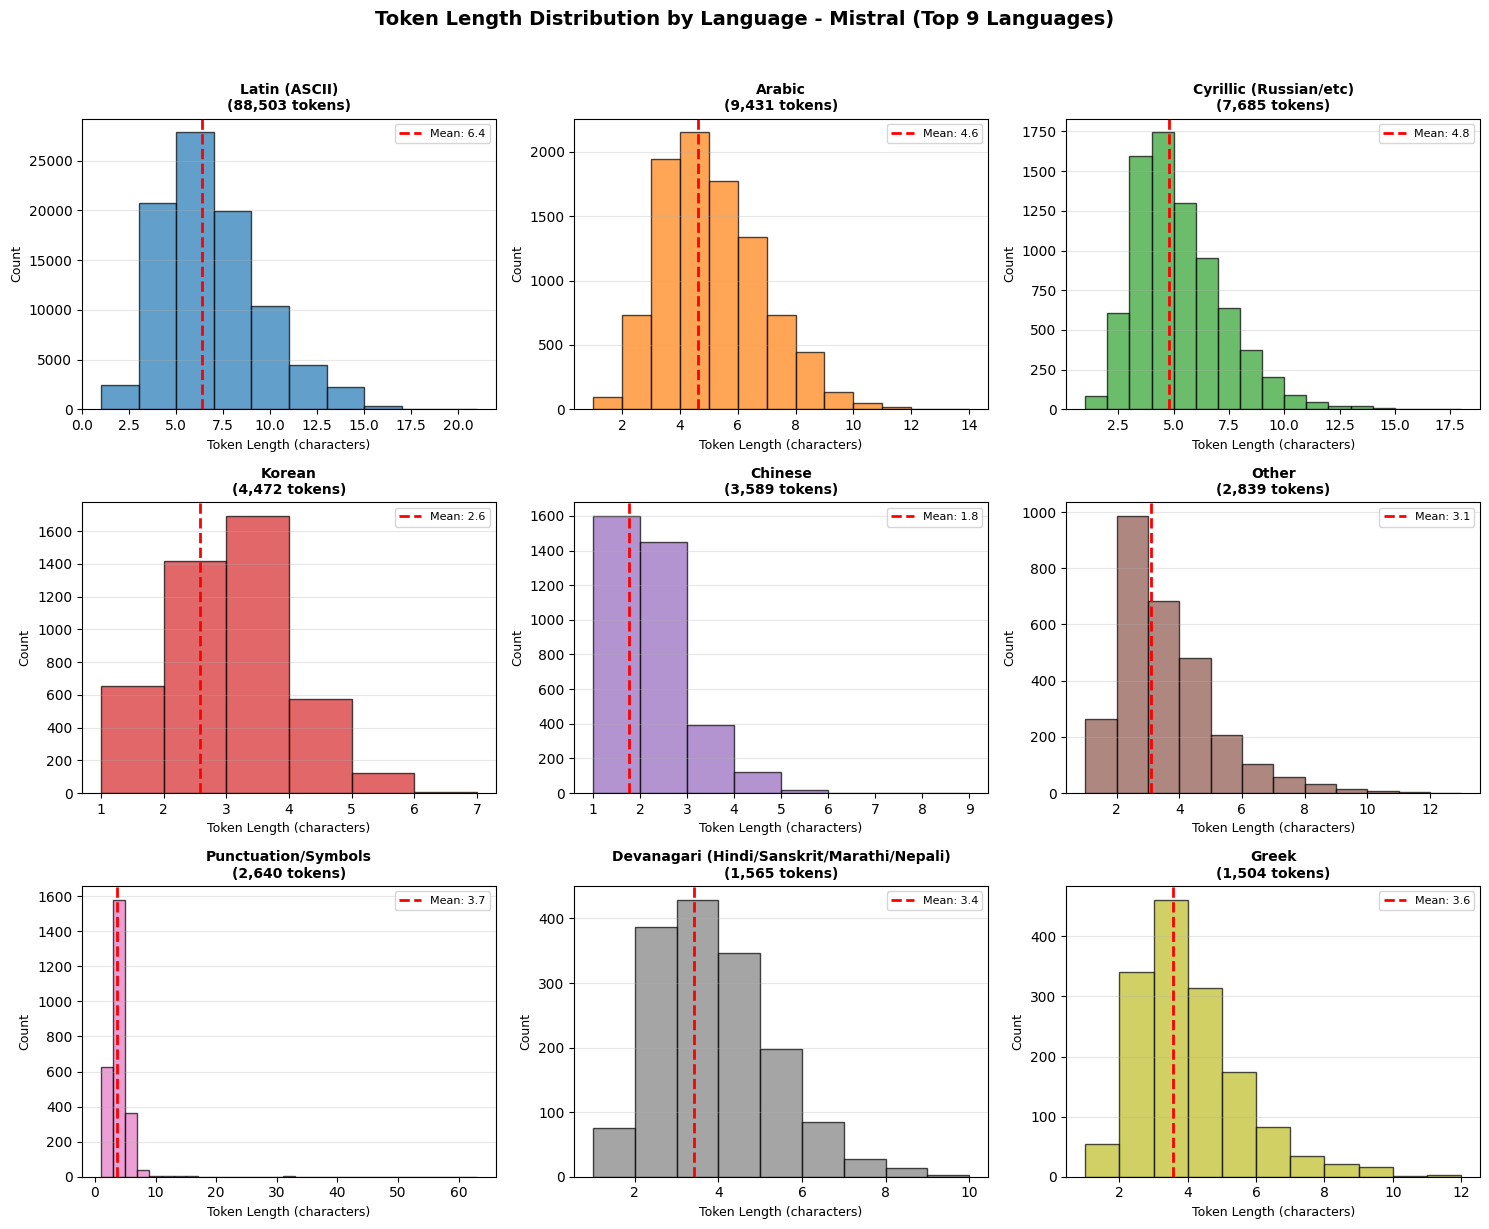

In [33]:
# Create histograms for token length distribution by language (Mistral)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Top 9 languages by token count
mistral_top_languages = mistral_sorted_languages[:9]

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, (lang, lengths) in enumerate(mistral_top_languages):
    ax = axes[idx]
    
    # Create histogram with better binning
    max_len = max(lengths)
    if max_len <= 20:
        bins = range(1, max_len + 2)
    else:
        bins = np.arange(1, min(max_len + 2, 65), 2)
    
    counts, bin_edges, patches = ax.hist(lengths, bins=bins, color=colors[idx], 
                                          edgecolor='black', alpha=0.7)
    
    ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Token Length (characters)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean line
    mean_len = np.mean(lengths)
    ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
    ax.legend(fontsize=8)

plt.suptitle("Token Length Distribution by Language - Mistral (Top 9 Languages)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Indic Languages - Token Length Distribution Histograms (Mistral)

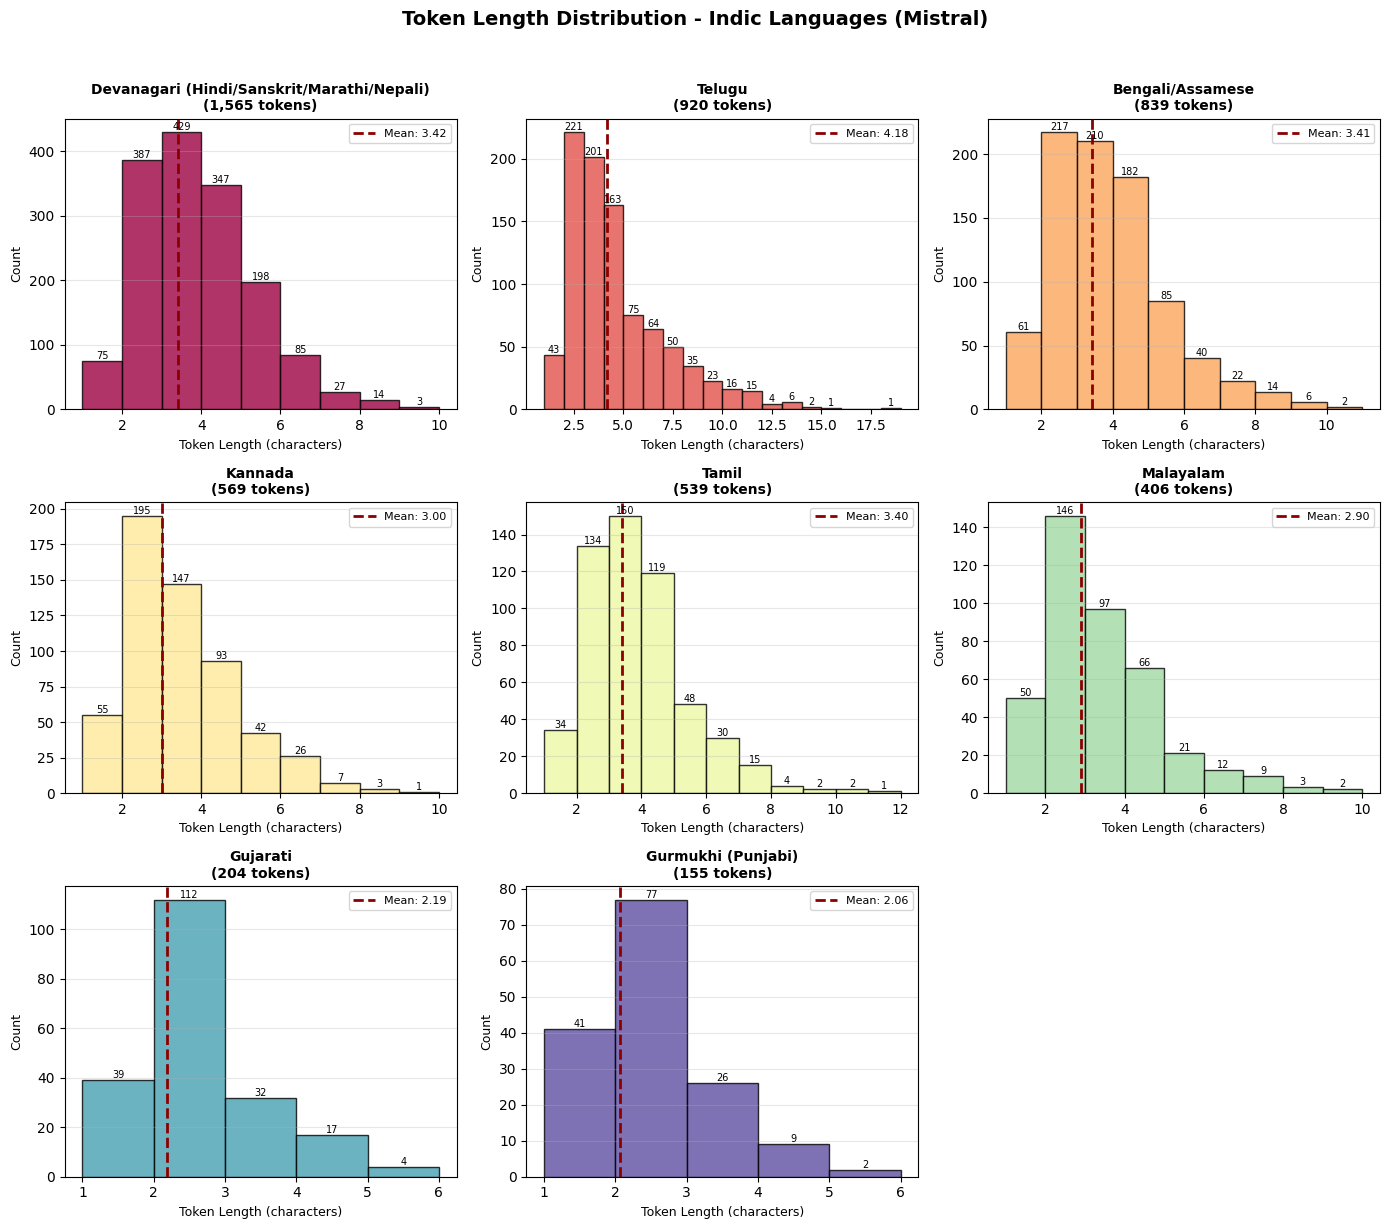


INDIC LANGUAGES (Mistral) - DETAILED STATISTICS
Language                                         Count     Mean    Max
----------------------------------------------------------------------
Devanagari (Hindi/Sanskrit/Marathi/Nepali)       1,565     3.42      9
Telugu                                             920     4.18     18
Bengali/Assamese                                   839     3.41     10
Kannada                                            569     3.00      9
Tamil                                              539     3.40     11
Malayalam                                          406     2.90      9
Gujarati                                           204     2.19      5
Gurmukhi (Punjabi)                                 155     2.06      5


In [34]:
# Indic Languages Token Length Distribution (Mistral)
mistral_indic_scripts_list = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

# Filter to only Indic languages that have tokens
mistral_indic_data = [(lang, lengths) for lang, lengths in mistral_language_token_lengths.items() 
                       if lang in mistral_indic_scripts_list and len(lengths) > 0]
mistral_indic_data.sort(key=lambda x: len(x[1]), reverse=True)

if mistral_indic_data:
    n_indic = len(mistral_indic_data)
    n_cols = 3
    n_rows = (n_indic + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    indic_colors = plt.cm.Spectral(np.linspace(0, 1, n_indic))
    
    for idx, (lang, lengths) in enumerate(mistral_indic_data):
        ax = axes[idx]
        
        # Create histogram
        max_len = max(lengths)
        bins = range(1, max_len + 2)
        
        counts, bin_edges, patches = ax.hist(lengths, bins=bins, 
                                              color=indic_colors[idx], 
                                              edgecolor='black', alpha=0.8)
        
        ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
        ax.set_xlabel("Token Length (characters)", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        # Add mean line
        mean_len = np.mean(lengths)
        ax.axvline(mean_len, color='darkred', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_len:.2f}')
        ax.legend(fontsize=8)
        
        # Add count annotations on bars
        for i, (count, patch) in enumerate(zip(counts, patches)):
            if count > 0:
                ax.annotate(f'{int(count)}', 
                           xy=(patch.get_x() + patch.get_width()/2, count),
                           ha='center', va='bottom', fontsize=7)
    
    # Hide empty subplots
    for idx in range(len(mistral_indic_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Token Length Distribution - Indic Languages (Mistral)", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "=" * 80)
    print("INDIC LANGUAGES (Mistral) - DETAILED STATISTICS")
    print("=" * 80)
    print(f"{'Language':<45} {'Count':>8} {'Mean':>8} {'Max':>6}")
    print("-" * 70)
    
    for lang, lengths in mistral_indic_data:
        print(f"{lang:<45} {len(lengths):>8,} {np.mean(lengths):>8.2f} {max(lengths):>6}")
else:
    print("No Indic language tokens found in the Mistral vocabulary.")

## 6. Stacked Bar Chart - All Languages (Mistral)

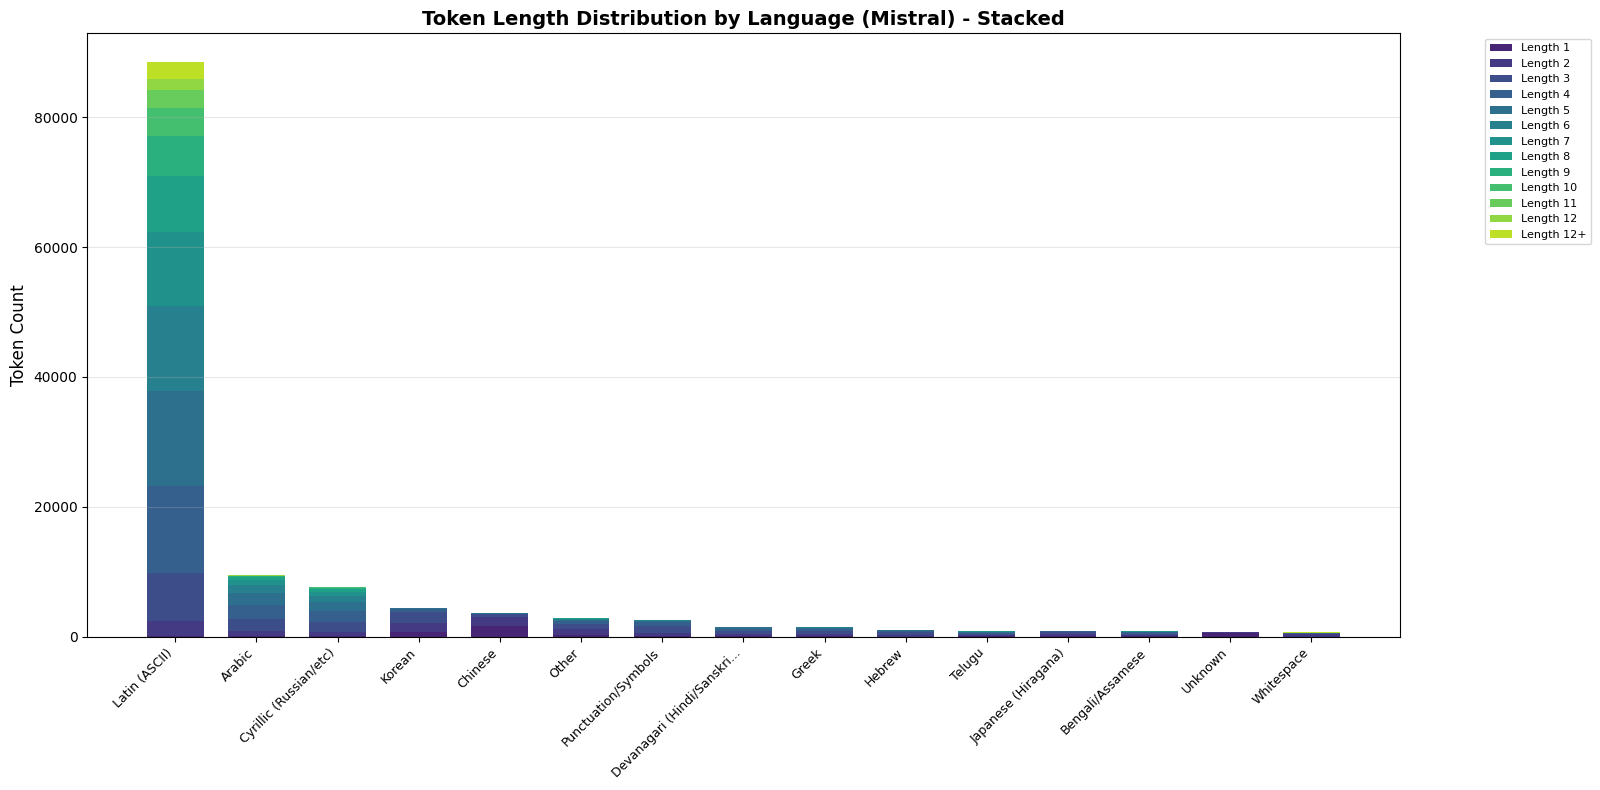

In [35]:
# Create a detailed grouped bar chart showing length distribution for all major languages (Mistral)
mistral_major_languages = [lang for lang, lengths in mistral_sorted_languages if len(lengths) >= 50][:15]

# Get the length distribution for each language
max_length_to_show = 12  # Show lengths 1 to 12

mistral_length_data = {}
for lang in mistral_major_languages:
    lengths = mistral_language_token_lengths[lang]
    length_counts = defaultdict(int)
    for l in lengths:
        if l <= max_length_to_show:
            length_counts[l] += 1
        else:
            length_counts[max_length_to_show + 1] += 1  # "12+" bucket
    mistral_length_data[lang] = length_counts

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(mistral_major_languages))
width = 0.7

# Colors for different lengths
length_colors = plt.cm.viridis(np.linspace(0.1, 0.9, max_length_to_show + 1))

bottom = np.zeros(len(mistral_major_languages))

for length_val in range(1, max_length_to_show + 2):
    counts = [mistral_length_data[lang].get(length_val, 0) for lang in mistral_major_languages]
    label = f"Length {length_val}" if length_val <= max_length_to_show else f"Length {max_length_to_show}+"
    ax.bar(x, counts, width, bottom=bottom, label=label, color=length_colors[length_val - 1])
    bottom += counts

ax.set_ylabel('Token Count', fontsize=12)
ax.set_title('Token Length Distribution by Language (Mistral) - Stacked', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([lang[:25] + "..." if len(lang) > 25 else lang for lang in mistral_major_languages], 
                    rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary Comparison: DeepSeek V3 vs GPT-OSS vs Qwen vs Mistral

In [36]:
# Summary comparison between DeepSeek V3, GPT-OSS, Qwen, and Mistral tokenizers
print("=" * 130)
print("TOKENIZER COMPARISON: DeepSeek V3 vs GPT-OSS vs Qwen vs Mistral")
print("=" * 130)

print(f"\n{'Metric':<45} {'DeepSeek V3':>20} {'GPT-OSS':>20} {'Qwen':>20} {'Mistral':>20}")
print("-" * 127)

# Vocabulary sizes
ds_vocab_size = len(vocab) if 'vocab' in dir() else 0
gptoss_vocab_size = len(gptoss_vocab) if 'gptoss_vocab' in dir() else 0
qwen_vocab_size = len(qwen_vocab) if 'qwen_vocab' in dir() else 0
mistral_vocab_size = len(mistral_vocab)

print(f"{'Total vocabulary size':<45} {ds_vocab_size:>20,} {gptoss_vocab_size:>20,} {qwen_vocab_size:>20,} {mistral_vocab_size:>20,}")

# Indic language totals
indic_scripts_list = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

ds_indic_total = sum(len(decoded_classifications.get(s, [])) for s in indic_scripts_list) if 'decoded_classifications' in dir() else 0
gptoss_indic_total = sum(len(gptoss_decoded_classifications.get(s, [])) for s in indic_scripts_list) if 'gptoss_decoded_classifications' in dir() else 0
qwen_indic_total = sum(len(qwen_decoded_classifications.get(s, [])) for s in indic_scripts_list) if 'qwen_decoded_classifications' in dir() else 0
mistral_indic_total = sum(len(mistral_decoded_classifications.get(s, [])) for s in indic_scripts_list)

print(f"{'Total Indic tokens':<45} {ds_indic_total:>20,} {gptoss_indic_total:>20,} {qwen_indic_total:>20,} {mistral_indic_total:>20,}")

if ds_vocab_size > 0 and gptoss_vocab_size > 0 and qwen_vocab_size > 0:
    ds_indic_pct = (ds_indic_total / ds_vocab_size) * 100
    gptoss_indic_pct = (gptoss_indic_total / gptoss_vocab_size) * 100
    qwen_indic_pct = (qwen_indic_total / qwen_vocab_size) * 100
    mistral_indic_pct = (mistral_indic_total / mistral_vocab_size) * 100
    print(f"{'Indic tokens (%)':<45} {ds_indic_pct:>19.2f}% {gptoss_indic_pct:>19.2f}% {qwen_indic_pct:>19.2f}% {mistral_indic_pct:>19.2f}%")

# Count tokens with length > 32
ds_long_tokens = sum(1 for token in vocab.keys() if len(decode_bpe_token(token)) > 32) if 'vocab' in dir() else 0
gptoss_long_tokens = sum(1 for token in gptoss_vocab.keys() if len(gptoss_decode_bpe_token(token)) > 32) if 'gptoss_vocab' in dir() else 0
qwen_long_tokens = sum(1 for token in qwen_vocab.keys() if len(qwen_decode_bpe_token(token)) > 32) if 'qwen_vocab' in dir() else 0
mistral_long_tokens = sum(1 for token in mistral_vocab.keys() if len(mistral_decode_bpe_token(token)) > 32)

print(f"{'Tokens with length > 32':<45} {ds_long_tokens:>20,} {gptoss_long_tokens:>20,} {qwen_long_tokens:>20,} {mistral_long_tokens:>20,}")

if ds_vocab_size > 0 and gptoss_vocab_size > 0 and qwen_vocab_size > 0:
    ds_long_pct = (ds_long_tokens / ds_vocab_size) * 100
    gptoss_long_pct = (gptoss_long_tokens / gptoss_vocab_size) * 100
    qwen_long_pct = (qwen_long_tokens / qwen_vocab_size) * 100
    mistral_long_pct = (mistral_long_tokens / mistral_vocab_size) * 100
    print(f"{'Long tokens (>32) (%)':<45} {ds_long_pct:>19.2f}% {gptoss_long_pct:>19.2f}% {qwen_long_pct:>19.2f}% {mistral_long_pct:>19.2f}%")

print("\n" + "-" * 127)
print("Indic Language Breakdown:")
print("-" * 127)
print(f"{'Language':<45} {'DeepSeek V3':>20} {'GPT-OSS':>20} {'Qwen':>20} {'Mistral':>20}")
print("-" * 127)

for script in indic_scripts_list:
    ds_count = len(decoded_classifications.get(script, [])) if 'decoded_classifications' in dir() else 0
    gptoss_count = len(gptoss_decoded_classifications.get(script, [])) if 'gptoss_decoded_classifications' in dir() else 0
    qwen_count = len(qwen_decoded_classifications.get(script, [])) if 'qwen_decoded_classifications' in dir() else 0
    mistral_count = len(mistral_decoded_classifications.get(script, []))
    
    print(f"{script:<45} {ds_count:>20,} {gptoss_count:>20,} {qwen_count:>20,} {mistral_count:>20,}")

TOKENIZER COMPARISON: DeepSeek V3 vs GPT-OSS vs Qwen vs Mistral

Metric                                                 DeepSeek V3              GPT-OSS                 Qwen              Mistral
-------------------------------------------------------------------------------------------------------------------------------
Total vocabulary size                                      128,000              199,998              151,643              131,072
Total Indic tokens                                           1,473               13,634                  279                5,197
Indic tokens (%)                                             1.15%                6.82%                0.18%                3.96%
Tokens with length > 32                                         56                  157                  211                   40
Long tokens (>32) (%)                                        0.04%                0.08%                0.14%                0.03%

--------------------------

# OLMo Tokenizer Analysis

This section performs the same analysis on the OLMo tokenizer (olmo_tokenizer.json).

## 1. Load OLMo Tokenizer and Basic Stats

In [38]:
# Load OLMo tokenizer
import json
from pathlib import Path
import os

olmo_file_path = Path("d:/work/explore/tokenizer/olmo_tokenizer.json")

# Check if file exists and is not empty
if olmo_file_path.exists() and os.path.getsize(olmo_file_path) > 0:
    with open(olmo_file_path, 'r', encoding='utf-8') as f:
        olmo_tokenizer_data = json.load(f)

    # Extract vocabulary (tokens only, not merges)
    olmo_vocab = olmo_tokenizer_data['model']['vocab']
    print(f"Total number of tokens in OLMo vocabulary: {len(olmo_vocab):,}")
else:
    print(f"ERROR: OLMo tokenizer file is empty or missing!")
    print(f"File size: {os.path.getsize(olmo_file_path) if olmo_file_path.exists() else 'File not found'} bytes")
    print("Skipping OLMo analysis. Please re-download the tokenizer file.")
    olmo_vocab = {}  # Empty dict to allow remaining cells to run without error

Total number of tokens in OLMo vocabulary: 100,278


## 2. Largest Token Analysis

In [39]:
# Find the largest token by character length (OLMo)
olmo_largest_token = ""
olmo_largest_token_id = 0
olmo_largest_token_length = 0

for token, token_id in olmo_vocab.items():
    if len(token) > olmo_largest_token_length:
        olmo_largest_token = token
        olmo_largest_token_id = token_id
        olmo_largest_token_length = len(token)

print("Largest Token Analysis (OLMo):")
print("=" * 60)
print(f"Token ID: {olmo_largest_token_id}")
print(f"Token Length: {olmo_largest_token_length} characters")
print(f"Token Content: {repr(olmo_largest_token)[:100]}...")

# Top 10 longest tokens
olmo_sorted_by_length = sorted(olmo_vocab.items(), key=lambda x: len(x[0]), reverse=True)[:10]
print(f"\nTop 10 Longest Tokens:")
print("=" * 60)
for i, (token, tid) in enumerate(olmo_sorted_by_length, 1):
    print(f"{i:2d}. ID: {tid:6d} | Length: {len(token):3d} | Token: {repr(token)[:60]}...")

Largest Token Analysis (OLMo):
Token ID: 58040
Token Length: 128 characters
Token Content: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...

Top 10 Longest Tokens:
 1. ID:  58040 | Length: 128 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 2. ID:  90280 | Length: 114 | Token: '//---------------------------------------------------------...
 3. ID:  67307 | Length: 113 | Token: 'Ġ----------------------------------------------------------...
 4. ID:  57442 | Length:  98 | Token: '//---------------------------------------------------------...
 5. ID:  60909 | Length:  97 | Token: 'Ġ----------------------------------------------------------...
 6. ID:  87644 | Length:  97 | Token: '/**********************************************************...
 7. ID:  61729 | Length:  96 | Token: '///////////////////////////////////////////////////////////...
 8. ID:  99574 | Length:  96 | Token: '----------------------------

## 3. Language Breakdown Analysis

In [40]:
# OLMo uses byte-level BPE encoding - we need to decode tokens first
from collections import Counter, defaultdict

# Create byte decoder (same as GPT-2/DeepSeek/GPT-OSS/Qwen/Mistral)
def olmo_create_byte_decoder():
    """Create a mapping from GPT-2/byte-level BPE characters back to bytes."""
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(cs, bs))

olmo_byte_decoder = olmo_create_byte_decoder()

def olmo_decode_bpe_token(token):
    """Decode a byte-level BPE token back to the original text."""
    try:
        bytes_list = [olmo_byte_decoder.get(c, ord(c)) for c in token]
        return bytes(bytes_list).decode('utf-8', errors='replace')
    except:
        return token

def olmo_classify_decoded_token(decoded):
    """Classify a decoded token by its Unicode script."""
    scripts = Counter()
    for char in decoded:
        if char == '�':  # Replacement character
            continue
        cp = ord(char)
        
        if cp < 128:
            if char.isalpha():
                script = "Latin (ASCII)"
            elif char.isdigit():
                script = "Digits"
            elif char.isspace():
                script = "Whitespace"
            else:
                script = "Punctuation/Symbols"
        elif 0x4E00 <= cp <= 0x9FFF or 0x3400 <= cp <= 0x4DBF or 0x20000 <= cp <= 0x2A6DF:
            script = "Chinese"
        elif 0x3040 <= cp <= 0x309F:
            script = "Japanese (Hiragana)"
        elif 0x30A0 <= cp <= 0x30FF:
            script = "Japanese (Katakana)"
        elif 0xAC00 <= cp <= 0xD7AF or 0x1100 <= cp <= 0x11FF:
            script = "Korean"
        elif 0x0400 <= cp <= 0x04FF:
            script = "Cyrillic (Russian/etc)"
        elif 0x0600 <= cp <= 0x06FF or 0x0750 <= cp <= 0x077F:
            script = "Arabic"
        elif 0x0590 <= cp <= 0x05FF:
            script = "Hebrew"
        elif 0x0E00 <= cp <= 0x0E7F:
            script = "Thai"
        elif 0x0100 <= cp <= 0x024F:
            script = "Latin Extended"
        elif 0x0370 <= cp <= 0x03FF:
            script = "Greek"
        elif 0x1E00 <= cp <= 0x1EFF:
            script = "Vietnamese"
        # Indic scripts
        elif 0x0900 <= cp <= 0x097F:
            script = "Devanagari (Hindi/Sanskrit/Marathi/Nepali)"
        elif 0x0980 <= cp <= 0x09FF:
            script = "Bengali/Assamese"
        elif 0x0A00 <= cp <= 0x0A7F:
            script = "Gurmukhi (Punjabi)"
        elif 0x0A80 <= cp <= 0x0AFF:
            script = "Gujarati"
        elif 0x0B00 <= cp <= 0x0B7F:
            script = "Odia/Oriya"
        elif 0x0B80 <= cp <= 0x0BFF:
            script = "Tamil"
        elif 0x0C00 <= cp <= 0x0C7F:
            script = "Telugu"
        elif 0x0C80 <= cp <= 0x0CFF:
            script = "Kannada"
        elif 0x0D00 <= cp <= 0x0D7F:
            script = "Malayalam"
        elif 0x0D80 <= cp <= 0x0DFF:
            script = "Sinhala"
        elif cp >= 0x80 and cp <= 0xFF:
            script = "Byte Fragments (Partial UTF-8)"
        else:
            script = "Other"
        
        scripts[script] += 1
    
    if not scripts:
        return "Unknown"
    
    # Return dominant script (prefer non-ASCII for mixed)
    non_trivial = {k: v for k, v in scripts.items() 
                   if k not in ["Whitespace", "Punctuation/Symbols", "Digits", "Byte Fragments (Partial UTF-8)"]}
    if non_trivial:
        return max(non_trivial.items(), key=lambda x: x[1])[0]
    return max(scripts.items(), key=lambda x: x[1])[0]

# Classify all OLMo tokens using proper decoding
olmo_decoded_classifications = defaultdict(list)

for token, token_id in olmo_vocab.items():
    # Decode the byte-level BPE token
    decoded = olmo_decode_bpe_token(token)
    script = olmo_classify_decoded_token(decoded)
    olmo_decoded_classifications[script].append((token, token_id, decoded))

# Sort by count and display
olmo_sorted_classifications = sorted(olmo_decoded_classifications.items(), 
                                       key=lambda x: len(x[1]), reverse=True)

print("Token Distribution by Script/Language (OLMo):")
print("=" * 70)
olmo_total_tokens = len(olmo_vocab)
for script, tokens in olmo_sorted_classifications:
    count = len(tokens)
    percentage = (count / olmo_total_tokens) * 100
    print(f"{script:45s}: {count:6,} tokens ({percentage:5.2f}%)")

Token Distribution by Script/Language (OLMo):
Latin (ASCII)                                : 89,560 tokens (89.31%)
Punctuation/Symbols                          :  4,891 tokens ( 4.88%)
Whitespace                                   :  1,197 tokens ( 1.19%)
Digits                                       :  1,110 tokens ( 1.11%)
Chinese                                      :    861 tokens ( 0.86%)
Cyrillic (Russian/etc)                       :    736 tokens ( 0.73%)
Unknown                                      :    530 tokens ( 0.53%)
Other                                        :    375 tokens ( 0.37%)
Korean                                       :    299 tokens ( 0.30%)
Latin Extended                               :    119 tokens ( 0.12%)
Arabic                                       :    104 tokens ( 0.10%)
Byte Fragments (Partial UTF-8)               :     97 tokens ( 0.10%)
Japanese (Hiragana)                          :     89 tokens ( 0.09%)
Japanese (Katakana)                         

## 4. Indic Languages Focus (OLMo)

In [41]:
# Special focus on Indic languages in OLMo tokenizer
olmo_indic_scripts = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

print("=" * 80)
print("INDIC LANGUAGES IN OLMO TOKENIZER")
print("=" * 80)

olmo_total_indic = 0
olmo_indic_summary = []

for script in olmo_indic_scripts:
    tokens = olmo_decoded_classifications.get(script, [])
    count = len(tokens)
    olmo_total_indic += count
    if count > 0:
        olmo_indic_summary.append((script, count, tokens))

print(f"\nTotal Indic language tokens: {olmo_total_indic:,}")
print(f"Percentage of vocabulary: {(olmo_total_indic / olmo_total_tokens) * 100:.2f}%")

print("\n" + "-" * 80)
print("Breakdown by Indic Script:")
print("-" * 80)

for script, count, tokens in sorted(olmo_indic_summary, key=lambda x: x[1], reverse=True):
    print(f"\n{script}: {count} tokens")
    
    # Show sample tokens (tokens now contains (raw_token, token_id, decoded))
    samples = tokens[:5]
    print("  Sample tokens:")
    for raw_token, tid, decoded in samples:
        print(f"    ID {tid:6d}: {repr(decoded)}")
    
    # Show longest tokens by decoded length
    sorted_tokens = sorted(tokens, key=lambda x: len(x[2]), reverse=True)[:3]
    print("  Longest tokens:")
    for raw_token, tid, decoded in sorted_tokens:
        print(f"    ID {tid:6d}: len={len(decoded):2d}, {repr(decoded)}")

INDIC LANGUAGES IN OLMO TOKENIZER

Total Indic language tokens: 43
Percentage of vocabulary: 0.04%

--------------------------------------------------------------------------------
Breakdown by Indic Script:
--------------------------------------------------------------------------------

Devanagari (Hindi/Sanskrit/Marathi/Nepali): 27 tokens
  Sample tokens:
    ID  24810: 'ा'
    ID  30707: '्'
    ID  31584: '्�'
    ID  32511: 'ा�'
    ID  35470: 'े'
  Longest tokens:
    ID  31584: len= 2, '्�'
    ID  32511: len= 2, 'ा�'
    ID  43411: len= 2, 'ि�'

Bengali/Assamese: 9 tokens
  Sample tokens:
    ID  42412: 'া'
    ID  50228: 'া�'
    ID  53695: '্'
    ID  53906: '্�'
    ID  60008: 'ে'
  Longest tokens:
    ID  50228: len= 2, 'া�'
    ID  53906: len= 2, '্�'
    ID  81278: len= 2, 'ি�'

Tamil: 5 tokens
  Sample tokens:
    ID  47454: '்'
    ID  64500: '்�'
    ID  84298: 'ு'
    ID  91702: 'ி'
    ID 100112: 'ி�'
  Longest tokens:
    ID  64500: len= 2, '்�'
    ID 100112: len=

## 5. Token Length Distribution by Language (OLMo)

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Collect token lengths by language/script for OLMo (using decoded length)
olmo_language_token_lengths = defaultdict(list)

for token, token_id in olmo_vocab.items():
    # Decode the token
    decoded = olmo_decode_bpe_token(token)
    token_len = len(decoded)
    
    if token_len == 0:
        continue
    
    script = olmo_classify_decoded_token(decoded)
    olmo_language_token_lengths[script].append(token_len)

# Sort languages by token count (descending)
olmo_sorted_languages = sorted(olmo_language_token_lengths.items(), key=lambda x: len(x[1]), reverse=True)

print("Token count and length stats by language/script (OLMo):")
print("-" * 80)
print(f"{'Script':<45} {'Tokens':>10} {'Avg Len':>10} {'Max Len':>10}")
print("-" * 80)
for lang, lengths in olmo_sorted_languages:
    avg_len = np.mean(lengths)
    max_len = max(lengths)
    print(f"{lang:<45} {len(lengths):>10,} {avg_len:>10.2f} {max_len:>10}")

Token count and length stats by language/script (OLMo):
--------------------------------------------------------------------------------
Script                                            Tokens    Avg Len    Max Len
--------------------------------------------------------------------------------
Latin (ASCII)                                     89,560       6.53         42
Punctuation/Symbols                                4,891       5.97        114
Whitespace                                         1,197       8.59        128
Digits                                             1,110       2.89          3
Chinese                                              861       1.45          7
Cyrillic (Russian/etc)                               736       3.42         13
Unknown                                              530       1.14          4
Other                                                375       2.22         16
Korean                                               299       1.78    

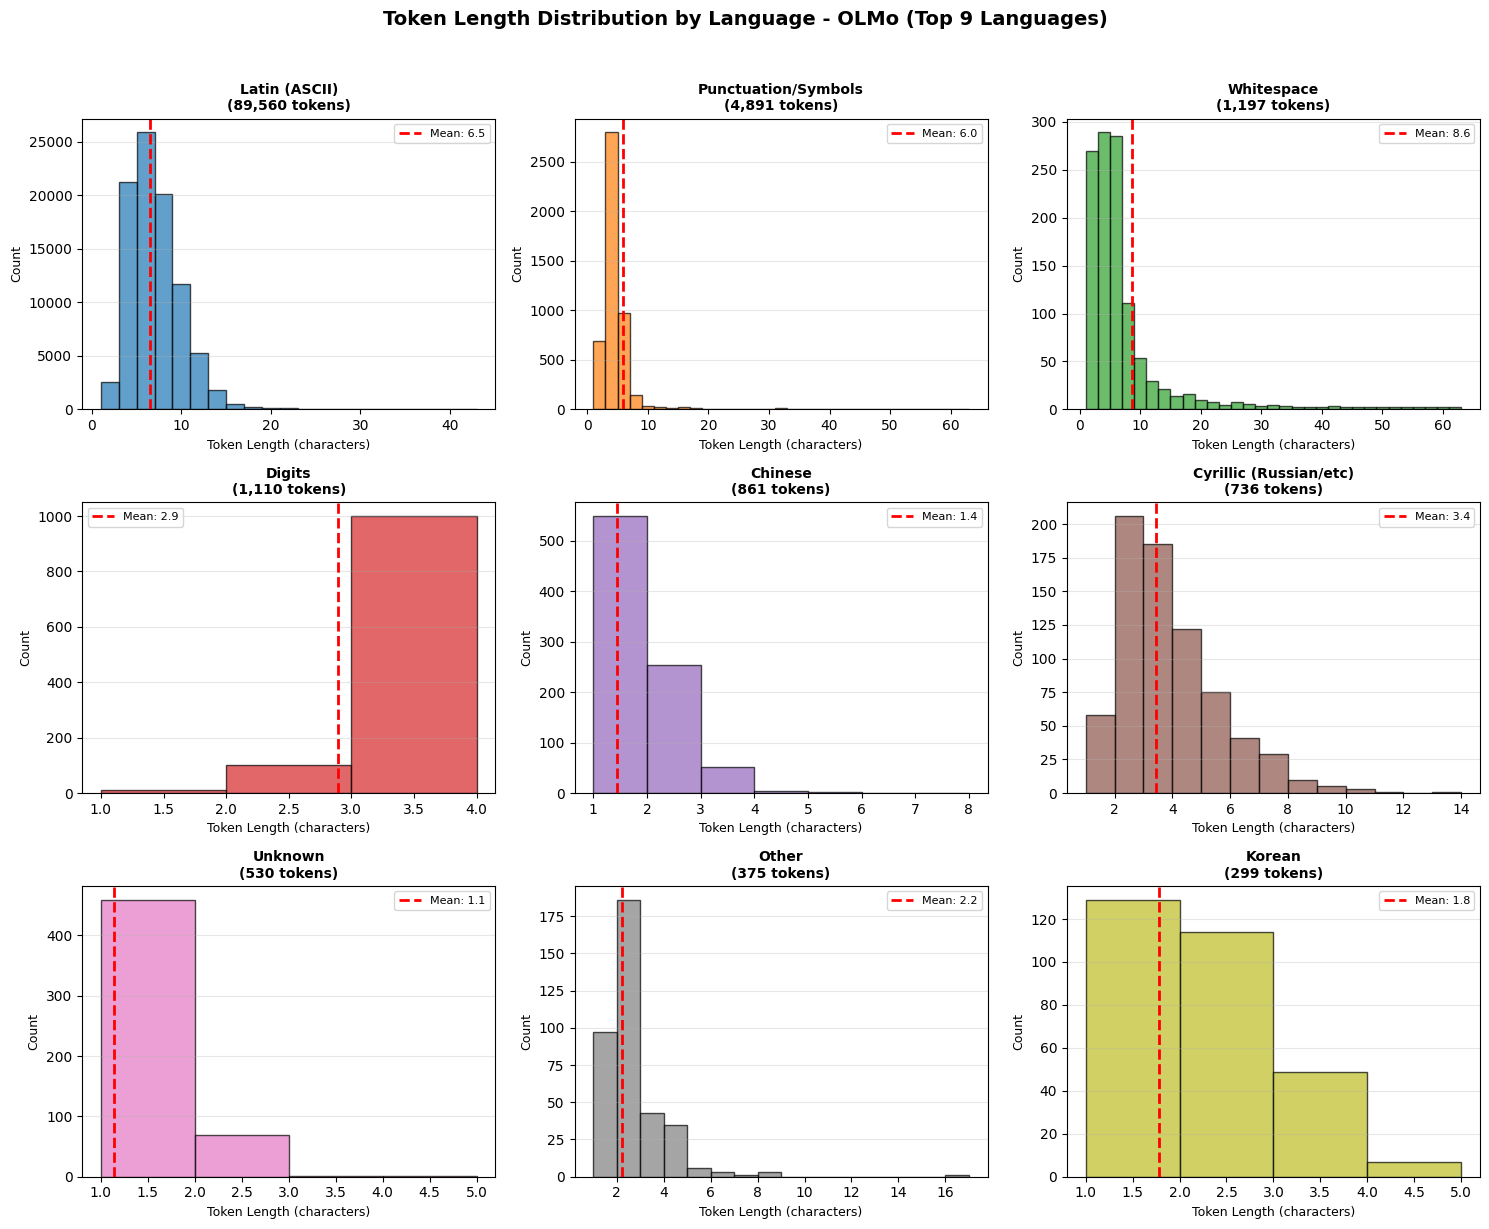

In [43]:
# Create histograms for token length distribution by language (OLMo)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Top 9 languages by token count
olmo_top_languages = olmo_sorted_languages[:9]

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, (lang, lengths) in enumerate(olmo_top_languages):
    ax = axes[idx]
    
    # Create histogram with better binning
    max_len = max(lengths)
    if max_len <= 20:
        bins = range(1, max_len + 2)
    else:
        bins = np.arange(1, min(max_len + 2, 65), 2)
    
    counts, bin_edges, patches = ax.hist(lengths, bins=bins, color=colors[idx], 
                                          edgecolor='black', alpha=0.7)
    
    ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Token Length (characters)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean line
    mean_len = np.mean(lengths)
    ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
    ax.legend(fontsize=8)

plt.suptitle("Token Length Distribution by Language - OLMo (Top 9 Languages)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Indic Languages - Token Length Distribution Histograms (OLMo)

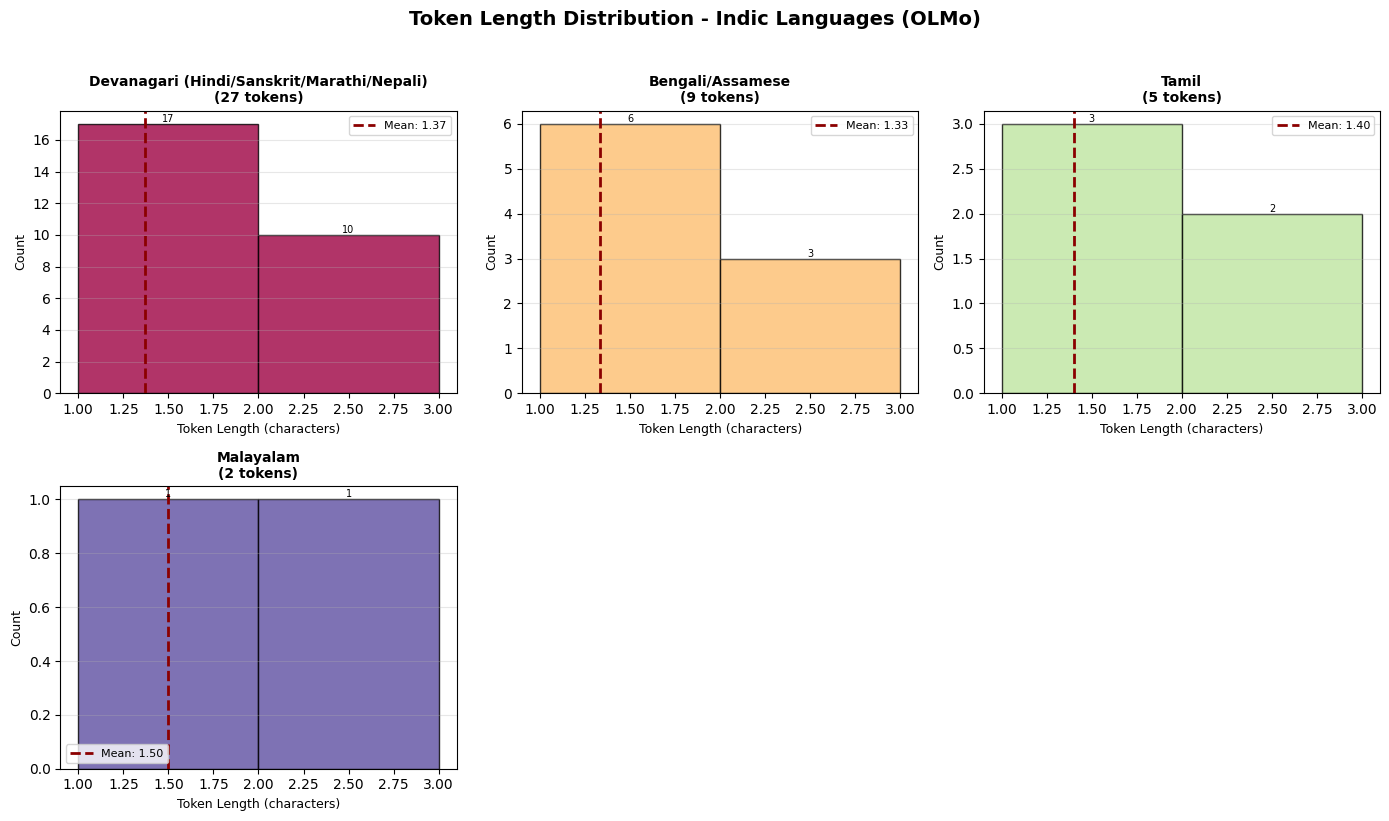


INDIC LANGUAGES (OLMo) - DETAILED STATISTICS
Language                                         Count     Mean    Max
----------------------------------------------------------------------
Devanagari (Hindi/Sanskrit/Marathi/Nepali)          27     1.37      2
Bengali/Assamese                                     9     1.33      2
Tamil                                                5     1.40      2
Malayalam                                            2     1.50      2


In [44]:
# Indic Languages Token Length Distribution (OLMo)
olmo_indic_scripts_list = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

# Filter to only Indic languages that have tokens
olmo_indic_data = [(lang, lengths) for lang, lengths in olmo_language_token_lengths.items() 
                    if lang in olmo_indic_scripts_list and len(lengths) > 0]
olmo_indic_data.sort(key=lambda x: len(x[1]), reverse=True)

if olmo_indic_data:
    n_indic = len(olmo_indic_data)
    n_cols = 3
    n_rows = (n_indic + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    indic_colors = plt.cm.Spectral(np.linspace(0, 1, n_indic))
    
    for idx, (lang, lengths) in enumerate(olmo_indic_data):
        ax = axes[idx]
        
        # Create histogram
        max_len = max(lengths)
        bins = range(1, max_len + 2)
        
        counts, bin_edges, patches = ax.hist(lengths, bins=bins, 
                                              color=indic_colors[idx], 
                                              edgecolor='black', alpha=0.8)
        
        ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
        ax.set_xlabel("Token Length (characters)", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        # Add mean line
        mean_len = np.mean(lengths)
        ax.axvline(mean_len, color='darkred', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_len:.2f}')
        ax.legend(fontsize=8)
        
        # Add count annotations on bars
        for i, (count, patch) in enumerate(zip(counts, patches)):
            if count > 0:
                ax.annotate(f'{int(count)}', 
                           xy=(patch.get_x() + patch.get_width()/2, count),
                           ha='center', va='bottom', fontsize=7)
    
    # Hide empty subplots
    for idx in range(len(olmo_indic_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Token Length Distribution - Indic Languages (OLMo)", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "=" * 80)
    print("INDIC LANGUAGES (OLMo) - DETAILED STATISTICS")
    print("=" * 80)
    print(f"{'Language':<45} {'Count':>8} {'Mean':>8} {'Max':>6}")
    print("-" * 70)
    
    for lang, lengths in olmo_indic_data:
        print(f"{lang:<45} {len(lengths):>8,} {np.mean(lengths):>8.2f} {max(lengths):>6}")
else:
    print("No Indic language tokens found in the OLMo vocabulary.")

## 6. Stacked Bar Chart - All Languages (OLMo)

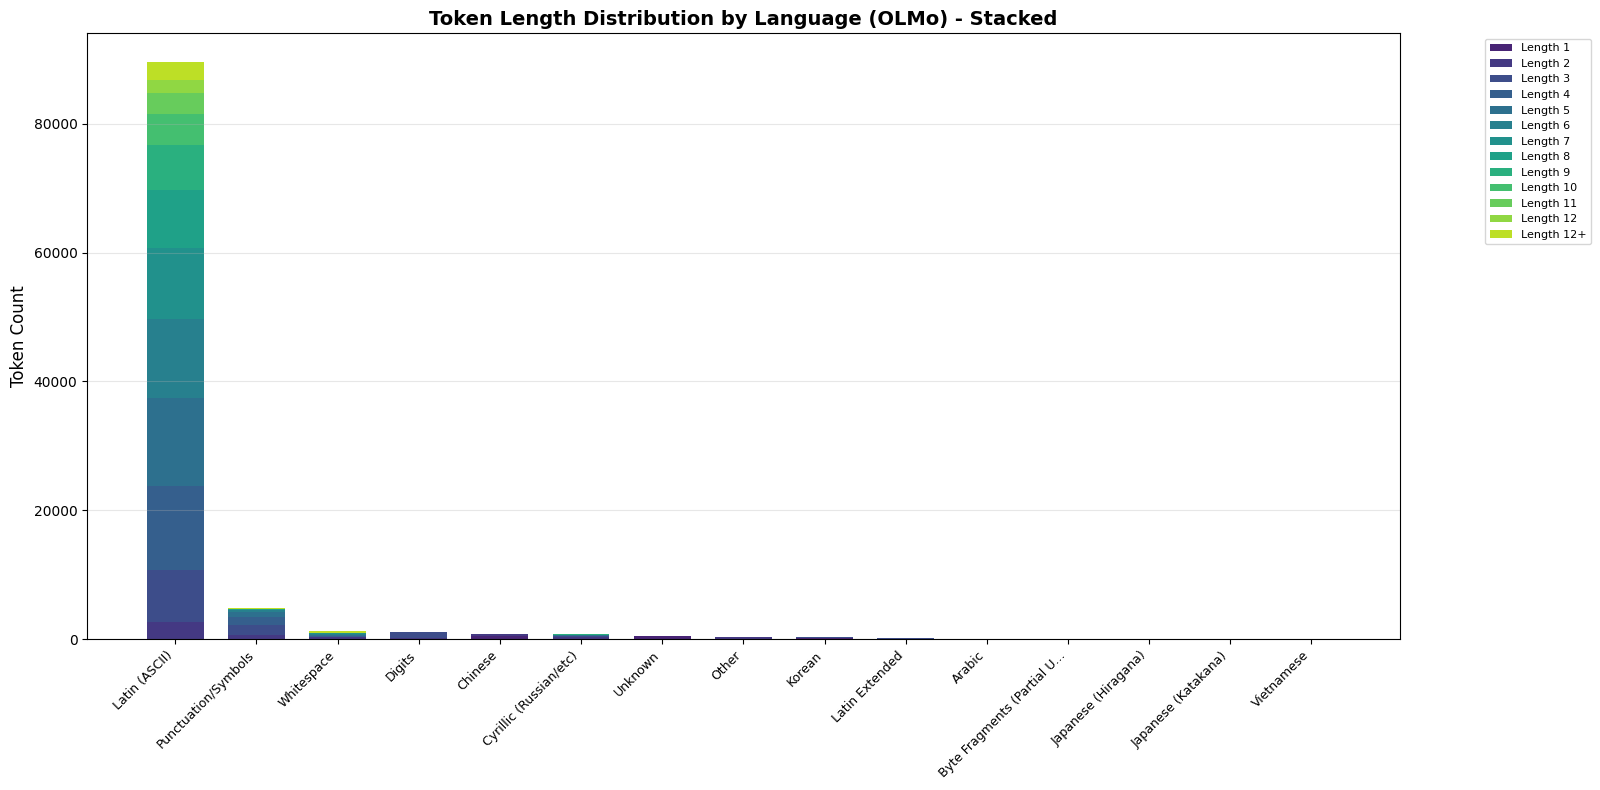

In [45]:
# Create a detailed grouped bar chart showing length distribution for all major languages (OLMo)
olmo_major_languages = [lang for lang, lengths in olmo_sorted_languages if len(lengths) >= 50][:15]

# Get the length distribution for each language
max_length_to_show = 12  # Show lengths 1 to 12

olmo_length_data = {}
for lang in olmo_major_languages:
    lengths = olmo_language_token_lengths[lang]
    length_counts = defaultdict(int)
    for l in lengths:
        if l <= max_length_to_show:
            length_counts[l] += 1
        else:
            length_counts[max_length_to_show + 1] += 1  # "12+" bucket
    olmo_length_data[lang] = length_counts

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(olmo_major_languages))
width = 0.7

# Colors for different lengths
length_colors = plt.cm.viridis(np.linspace(0.1, 0.9, max_length_to_show + 1))

bottom = np.zeros(len(olmo_major_languages))

for length_val in range(1, max_length_to_show + 2):
    counts = [olmo_length_data[lang].get(length_val, 0) for lang in olmo_major_languages]
    label = f"Length {length_val}" if length_val <= max_length_to_show else f"Length {max_length_to_show}+"
    ax.bar(x, counts, width, bottom=bottom, label=label, color=length_colors[length_val - 1])
    bottom += counts

ax.set_ylabel('Token Count', fontsize=12)
ax.set_title('Token Length Distribution by Language (OLMo) - Stacked', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([lang[:25] + "..." if len(lang) > 25 else lang for lang in olmo_major_languages], 
                    rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ByteD Tokenizer Analysis

This section performs the same analysis on the ByteD tokenizer (byted_tokenizer.json).

## 1. Load ByteD Tokenizer and Basic Stats

In [46]:
# Load ByteD tokenizer
import json
from pathlib import Path

byted_file_path = Path("d:/work/explore/tokenizer/byted_tokenizer.json")

with open(byted_file_path, 'r', encoding='utf-8') as f:
    byted_tokenizer_data = json.load(f)

# Extract vocabulary (tokens only, not merges)
byted_vocab = byted_tokenizer_data['model']['vocab']

print(f"Total number of tokens in ByteD vocabulary: {len(byted_vocab):,}")

Total number of tokens in ByteD vocabulary: 155,121


## 2. Largest Token Analysis

In [47]:
# Find the largest token by character length (ByteD)
byted_largest_token = ""
byted_largest_token_id = 0
byted_largest_token_length = 0

for token, token_id in byted_vocab.items():
    if len(token) > byted_largest_token_length:
        byted_largest_token = token
        byted_largest_token_id = token_id
        byted_largest_token_length = len(token)

print("Largest Token Analysis (ByteD):")
print("=" * 60)
print(f"Token ID: {byted_largest_token_id}")
print(f"Token Length: {byted_largest_token_length} characters")
print(f"Token Content: {repr(byted_largest_token)[:100]}...")

# Top 10 longest tokens
byted_sorted_by_length = sorted(byted_vocab.items(), key=lambda x: len(x[0]), reverse=True)[:10]
print(f"\nTop 10 Longest Tokens:")
print("=" * 60)
for i, (token, tid) in enumerate(byted_sorted_by_length, 1):
    print(f"{i:2d}. ID: {tid:6d} | Length: {len(token):3d} | Token: {repr(token)[:60]}...")

Largest Token Analysis (ByteD):
Token ID: 151910
Token Length: 512 characters
Token Content: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...

Top 10 Longest Tokens:
 1. ID: 151910 | Length: 512 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 2. ID: 151525 | Length: 256 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 3. ID: 152430 | Length: 192 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 4. ID:  52891 | Length: 128 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 5. ID: 151848 | Length: 112 | Token: 'ĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠĠ...
 6. ID: 117250 | Length:  96 | Token: '..............................................................
 7. ID: 113611 | Length:  80 | Token: '***********************************************************...
 8. ID: 131622 | Length:  80 | Token: '--------------------------

## 3. Language Breakdown Analysis

In [48]:
# ByteD uses byte-level BPE encoding - we need to decode tokens first
from collections import Counter, defaultdict

# Create byte decoder (same as GPT-2/DeepSeek/GPT-OSS/Qwen/Mistral/OLMo)
def byted_create_byte_decoder():
    """Create a mapping from GPT-2/byte-level BPE characters back to bytes."""
    bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(cs, bs))

byted_byte_decoder = byted_create_byte_decoder()

def byted_decode_bpe_token(token):
    """Decode a byte-level BPE token back to the original text."""
    try:
        bytes_list = [byted_byte_decoder.get(c, ord(c)) for c in token]
        return bytes(bytes_list).decode('utf-8', errors='replace')
    except:
        return token

def byted_classify_decoded_token(decoded):
    """Classify a decoded token by its Unicode script."""
    scripts = Counter()
    for char in decoded:
        if char == '�':  # Replacement character
            continue
        cp = ord(char)
        
        if cp < 128:
            if char.isalpha():
                script = "Latin (ASCII)"
            elif char.isdigit():
                script = "Digits"
            elif char.isspace():
                script = "Whitespace"
            else:
                script = "Punctuation/Symbols"
        elif 0x4E00 <= cp <= 0x9FFF or 0x3400 <= cp <= 0x4DBF or 0x20000 <= cp <= 0x2A6DF:
            script = "Chinese"
        elif 0x3040 <= cp <= 0x309F:
            script = "Japanese (Hiragana)"
        elif 0x30A0 <= cp <= 0x30FF:
            script = "Japanese (Katakana)"
        elif 0xAC00 <= cp <= 0xD7AF or 0x1100 <= cp <= 0x11FF:
            script = "Korean"
        elif 0x0400 <= cp <= 0x04FF:
            script = "Cyrillic (Russian/etc)"
        elif 0x0600 <= cp <= 0x06FF or 0x0750 <= cp <= 0x077F:
            script = "Arabic"
        elif 0x0590 <= cp <= 0x05FF:
            script = "Hebrew"
        elif 0x0E00 <= cp <= 0x0E7F:
            script = "Thai"
        elif 0x0100 <= cp <= 0x024F:
            script = "Latin Extended"
        elif 0x0370 <= cp <= 0x03FF:
            script = "Greek"
        elif 0x1E00 <= cp <= 0x1EFF:
            script = "Vietnamese"
        # Indic scripts
        elif 0x0900 <= cp <= 0x097F:
            script = "Devanagari (Hindi/Sanskrit/Marathi/Nepali)"
        elif 0x0980 <= cp <= 0x09FF:
            script = "Bengali/Assamese"
        elif 0x0A00 <= cp <= 0x0A7F:
            script = "Gurmukhi (Punjabi)"
        elif 0x0A80 <= cp <= 0x0AFF:
            script = "Gujarati"
        elif 0x0B00 <= cp <= 0x0B7F:
            script = "Odia/Oriya"
        elif 0x0B80 <= cp <= 0x0BFF:
            script = "Tamil"
        elif 0x0C00 <= cp <= 0x0C7F:
            script = "Telugu"
        elif 0x0C80 <= cp <= 0x0CFF:
            script = "Kannada"
        elif 0x0D00 <= cp <= 0x0D7F:
            script = "Malayalam"
        elif 0x0D80 <= cp <= 0x0DFF:
            script = "Sinhala"
        elif cp >= 0x80 and cp <= 0xFF:
            script = "Byte Fragments (Partial UTF-8)"
        else:
            script = "Other"
        
        scripts[script] += 1
    
    if not scripts:
        return "Unknown"
    
    # Return dominant script (prefer non-ASCII for mixed)
    non_trivial = {k: v for k, v in scripts.items() 
                   if k not in ["Whitespace", "Punctuation/Symbols", "Digits", "Byte Fragments (Partial UTF-8)"]}
    if non_trivial:
        return max(non_trivial.items(), key=lambda x: x[1])[0]
    return max(scripts.items(), key=lambda x: x[1])[0]

# Classify all ByteD tokens using proper decoding
byted_decoded_classifications = defaultdict(list)

for token, token_id in byted_vocab.items():
    # Decode the byte-level BPE token
    decoded = byted_decode_bpe_token(token)
    script = byted_classify_decoded_token(decoded)
    byted_decoded_classifications[script].append((token, token_id, decoded))

# Sort by count and display
byted_sorted_classifications = sorted(byted_decoded_classifications.items(), 
                                        key=lambda x: len(x[1]), reverse=True)

print("Token Distribution by Script/Language (ByteD):")
print("=" * 70)
byted_total_tokens = len(byted_vocab)
for script, tokens in byted_sorted_classifications:
    count = len(tokens)
    percentage = (count / byted_total_tokens) * 100
    print(f"{script:45s}: {count:6,} tokens ({percentage:5.2f}%)")

Token Distribution by Script/Language (ByteD):
Latin (ASCII)                                : 81,328 tokens (52.43%)
Chinese                                      : 50,961 tokens (32.85%)
Cyrillic (Russian/etc)                       :  8,498 tokens ( 5.48%)
Arabic                                       :  2,511 tokens ( 1.62%)
Punctuation/Symbols                          :  2,027 tokens ( 1.31%)
Other                                        :  1,561 tokens ( 1.01%)
Greek                                        :  1,390 tokens ( 0.90%)
Korean                                       :    895 tokens ( 0.58%)
Unknown                                      :    764 tokens ( 0.49%)
Whitespace                                   :    698 tokens ( 0.45%)
Hebrew                                       :    663 tokens ( 0.43%)
Devanagari (Hindi/Sanskrit/Marathi/Nepali)   :    531 tokens ( 0.34%)
Thai                                         :    504 tokens ( 0.32%)
Latin Extended                             

## 4. Indic Languages Focus (ByteD)

In [49]:
# Special focus on Indic languages in ByteD tokenizer
byted_indic_scripts = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

print("=" * 80)
print("INDIC LANGUAGES IN BYTED TOKENIZER")
print("=" * 80)

byted_total_indic = 0
byted_indic_summary = []

for script in byted_indic_scripts:
    tokens = byted_decoded_classifications.get(script, [])
    count = len(tokens)
    byted_total_indic += count
    if count > 0:
        byted_indic_summary.append((script, count, tokens))

print(f"\nTotal Indic language tokens: {byted_total_indic:,}")
print(f"Percentage of vocabulary: {(byted_total_indic / byted_total_tokens) * 100:.2f}%")

print("\n" + "-" * 80)
print("Breakdown by Indic Script:")
print("-" * 80)

for script, count, tokens in sorted(byted_indic_summary, key=lambda x: x[1], reverse=True):
    print(f"\n{script}: {count} tokens")
    
    # Show sample tokens (tokens now contains (raw_token, token_id, decoded))
    samples = tokens[:5]
    print("  Sample tokens:")
    for raw_token, tid, decoded in samples:
        print(f"    ID {tid:6d}: {repr(decoded)}")
    
    # Show longest tokens by decoded length
    sorted_tokens = sorted(tokens, key=lambda x: len(x[2]), reverse=True)[:3]
    print("  Longest tokens:")
    for raw_token, tid, decoded in sorted_tokens:
        print(f"    ID {tid:6d}: len={len(decoded):2d}, {repr(decoded)}")

INDIC LANGUAGES IN BYTED TOKENIZER

Total Indic language tokens: 2,511
Percentage of vocabulary: 1.62%

--------------------------------------------------------------------------------
Breakdown by Indic Script:
--------------------------------------------------------------------------------

Devanagari (Hindi/Sanskrit/Marathi/Nepali): 531 tokens
  Sample tokens:
    ID   1494: 'ा'
    ID   1943: 'ा�'
    ID   2097: '्'
    ID   2135: '्�'
    ID   2199: 'े'
  Longest tokens:
    ID  40590: len= 4, ' करन'
    ID  41678: len= 4, ' अपन'
    ID  47603: len= 4, ' करत'

Tamil: 373 tokens
  Sample tokens:
    ID   1223: '்'
    ID   1591: '்�'
    ID   2106: 'ு'
    ID   2193: 'ி'
    ID   2355: 'ி�'
  Longest tokens:
    ID  42216: len= 4, ' அவர'
    ID  74195: len= 4, ' அரச'
    ID  76148: len= 4, ' இவர'

Telugu: 300 tokens
  Sample tokens:
    ID   2666: '్'
    ID   2975: '్�'
    ID   2977: 'ి'
    ID   3130: 'ా'
    ID   3488: 'ు'
  Longest tokens:
    ID 115926: len= 5, ' సరఫర'
    ID

## 5. Token Length Distribution by Language (ByteD)

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Collect token lengths by language/script for ByteD (using decoded length)
byted_language_token_lengths = defaultdict(list)

for token, token_id in byted_vocab.items():
    # Decode the token
    decoded = byted_decode_bpe_token(token)
    token_len = len(decoded)
    
    if token_len == 0:
        continue
    
    script = byted_classify_decoded_token(decoded)
    byted_language_token_lengths[script].append(token_len)

# Sort languages by token count (descending)
byted_sorted_languages = sorted(byted_language_token_lengths.items(), key=lambda x: len(x[1]), reverse=True)

print("Token count and length stats by language/script (ByteD):")
print("-" * 80)
print(f"{'Script':<45} {'Tokens':>10} {'Avg Len':>10} {'Max Len':>10}")
print("-" * 80)
for lang, lengths in byted_sorted_languages:
    avg_len = np.mean(lengths)
    max_len = max(lengths)
    print(f"{lang:<45} {len(lengths):>10,} {avg_len:>10.2f} {max_len:>10}")

Token count and length stats by language/script (ByteD):
--------------------------------------------------------------------------------
Script                                            Tokens    Avg Len    Max Len
--------------------------------------------------------------------------------
Latin (ASCII)                                     81,328       6.14         32
Chinese                                           50,961       2.06          5
Cyrillic (Russian/etc)                             8,498       4.77         17
Arabic                                             2,511       3.58         10
Punctuation/Symbols                                2,027       4.27         96
Other                                              1,561       2.00         12
Greek                                              1,390       3.43         11
Korean                                               895       1.83          5
Unknown                                              764       1.12   

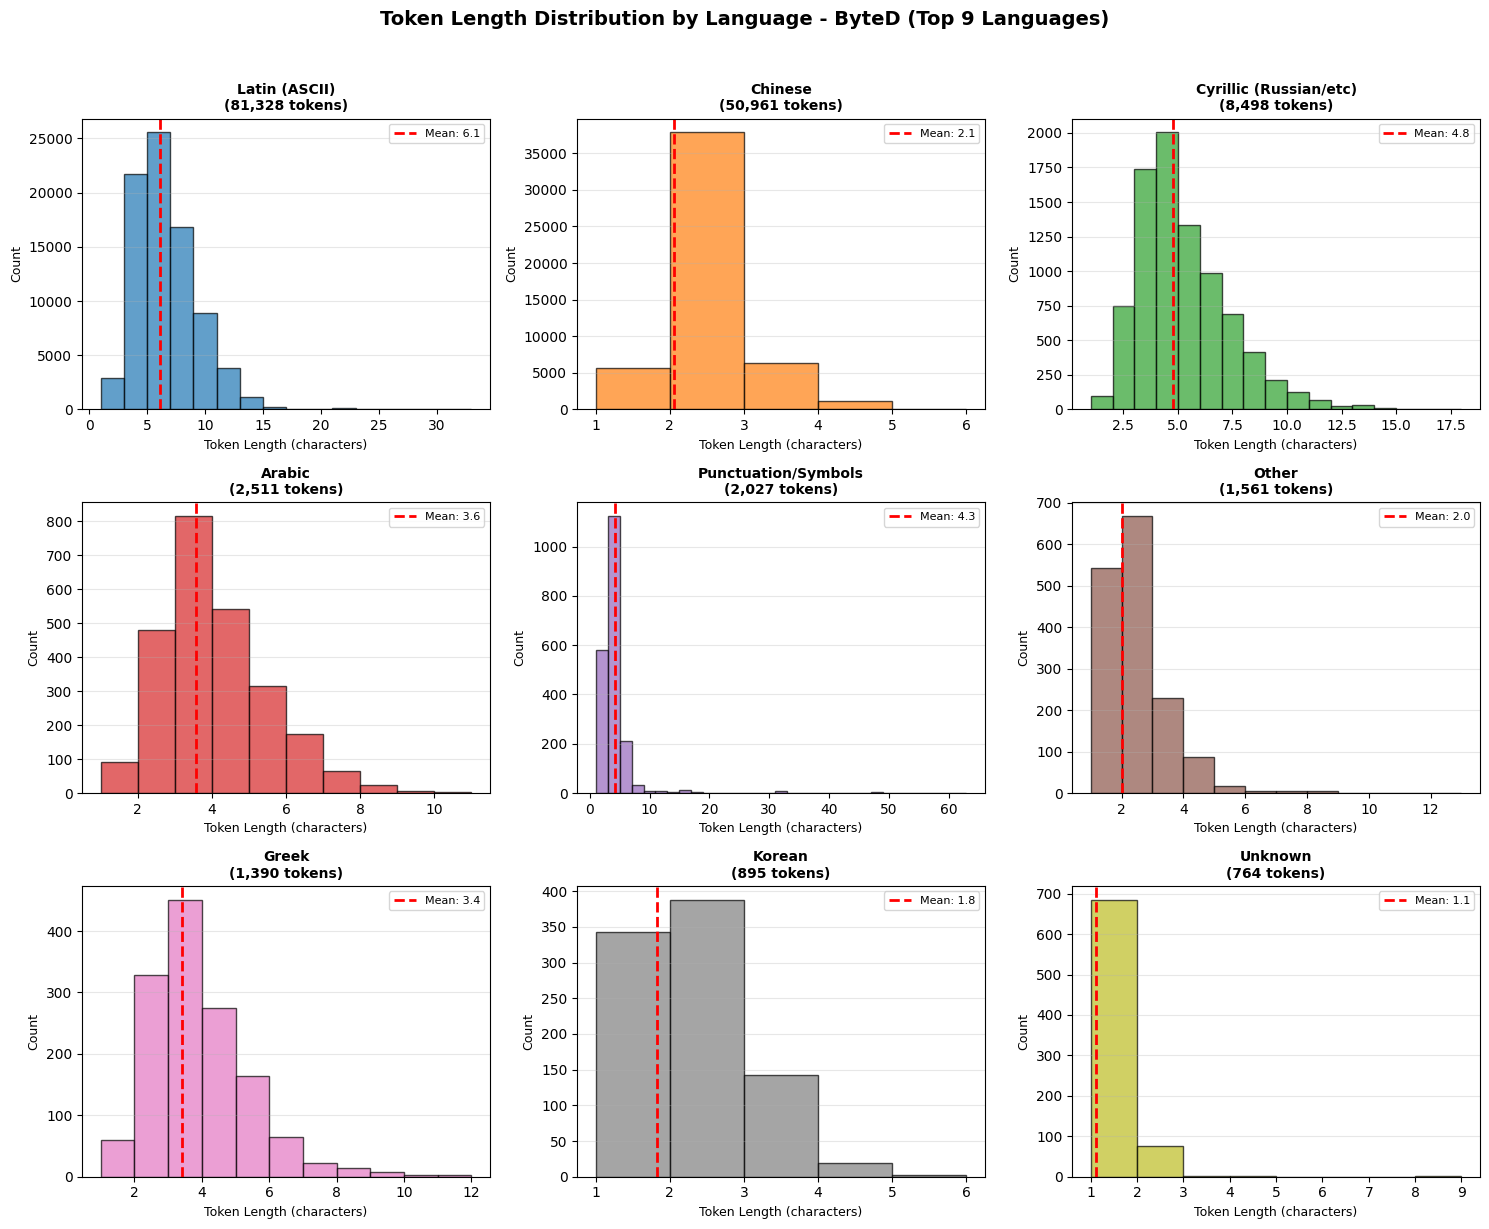

In [51]:
# Create histograms for token length distribution by language (ByteD)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Top 9 languages by token count
byted_top_languages = byted_sorted_languages[:9]

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, (lang, lengths) in enumerate(byted_top_languages):
    ax = axes[idx]
    
    # Create histogram with better binning
    max_len = max(lengths)
    if max_len <= 20:
        bins = range(1, max_len + 2)
    else:
        bins = np.arange(1, min(max_len + 2, 65), 2)
    
    counts, bin_edges, patches = ax.hist(lengths, bins=bins, color=colors[idx], 
                                          edgecolor='black', alpha=0.7)
    
    ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Token Length (characters)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean line
    mean_len = np.mean(lengths)
    ax.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
    ax.legend(fontsize=8)

plt.suptitle("Token Length Distribution by Language - ByteD (Top 9 Languages)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Indic Languages - Token Length Distribution Histograms (ByteD)

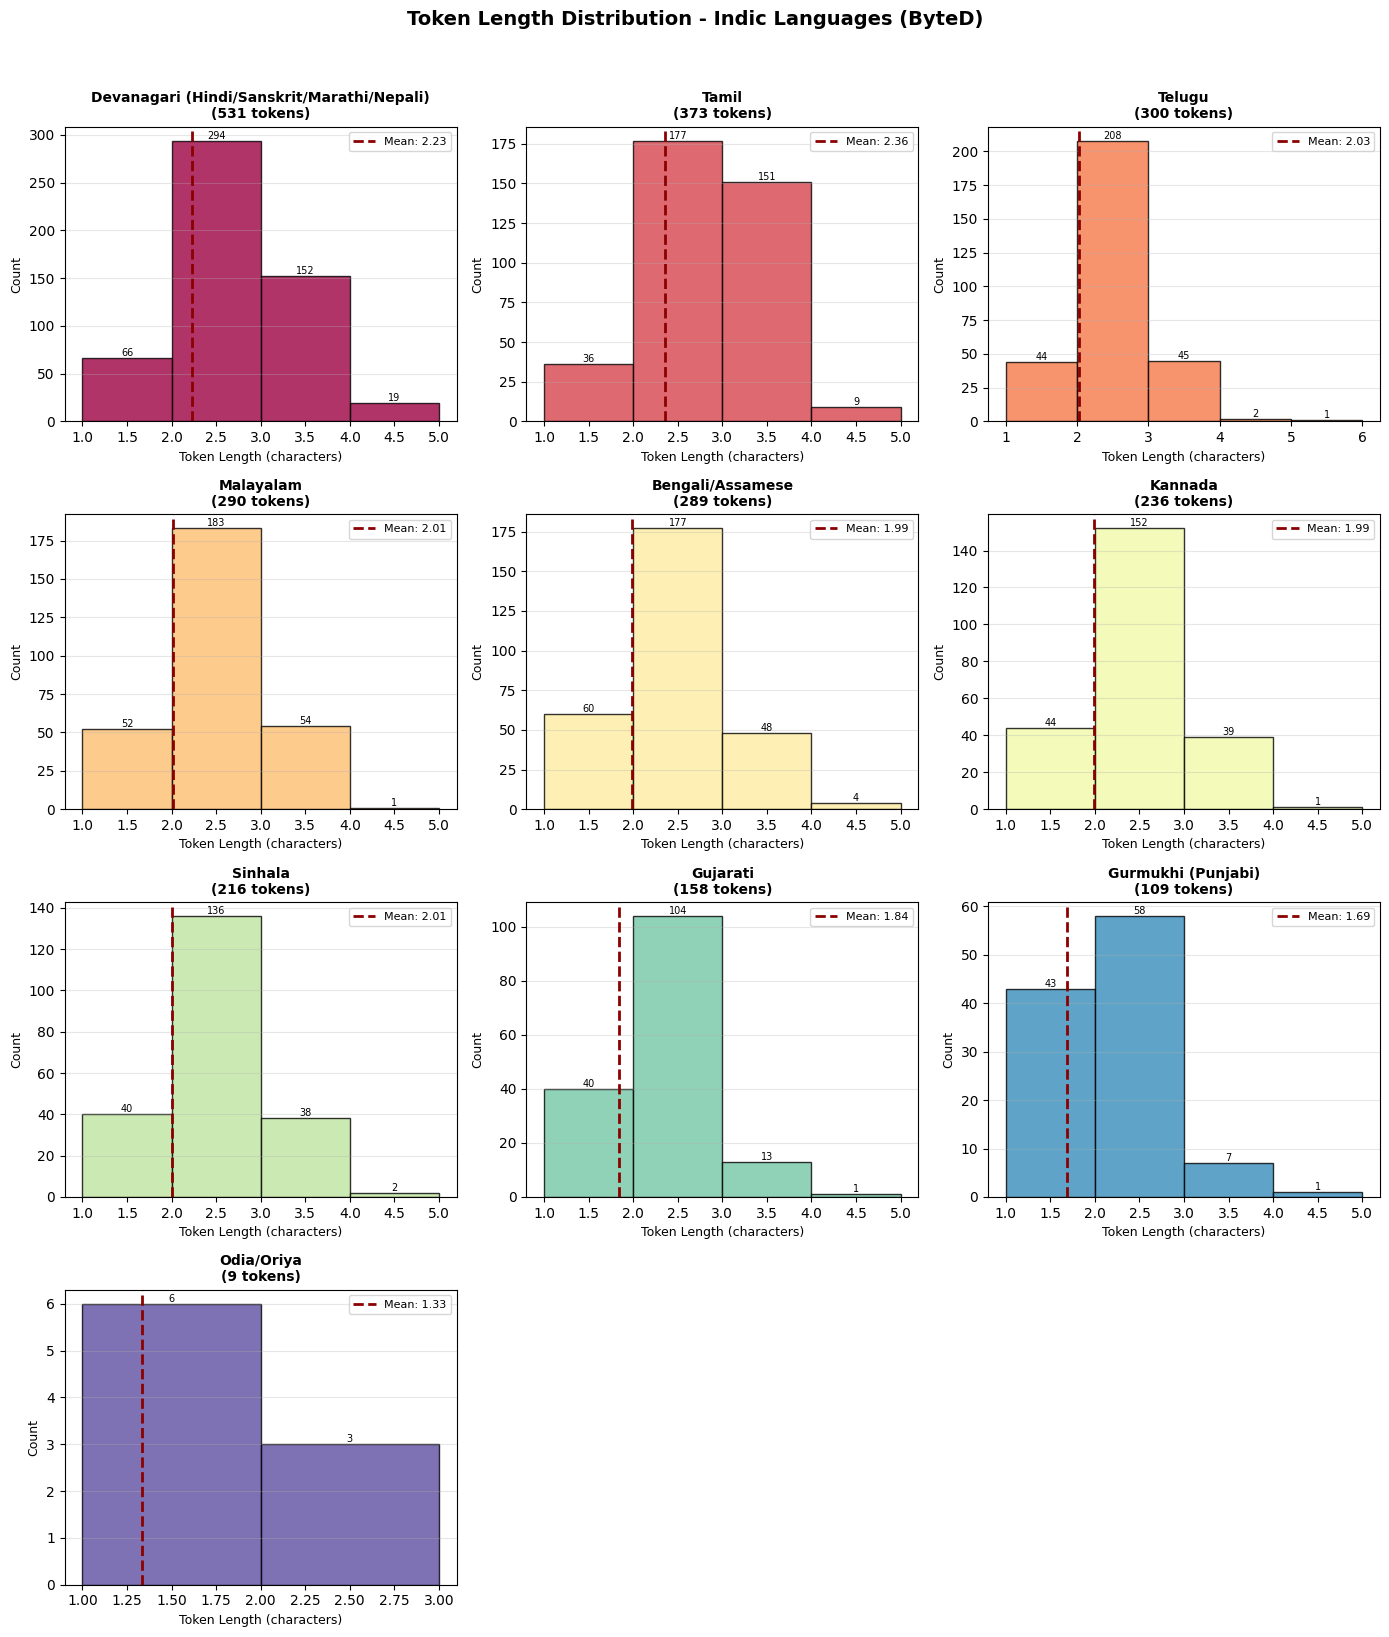


INDIC LANGUAGES (ByteD) - DETAILED STATISTICS
Language                                         Count     Mean    Max
----------------------------------------------------------------------
Devanagari (Hindi/Sanskrit/Marathi/Nepali)         531     2.23      4
Tamil                                              373     2.36      4
Telugu                                             300     2.03      5
Malayalam                                          290     2.01      4
Bengali/Assamese                                   289     1.99      4
Kannada                                            236     1.99      4
Sinhala                                            216     2.01      4
Gujarati                                           158     1.84      4
Gurmukhi (Punjabi)                                 109     1.69      4
Odia/Oriya                                           9     1.33      2


In [52]:
# Indic Languages Token Length Distribution (ByteD)
byted_indic_scripts_list = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

# Filter to only Indic languages that have tokens
byted_indic_data = [(lang, lengths) for lang, lengths in byted_language_token_lengths.items() 
                     if lang in byted_indic_scripts_list and len(lengths) > 0]
byted_indic_data.sort(key=lambda x: len(x[1]), reverse=True)

if byted_indic_data:
    n_indic = len(byted_indic_data)
    n_cols = 3
    n_rows = (n_indic + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    indic_colors = plt.cm.Spectral(np.linspace(0, 1, n_indic))
    
    for idx, (lang, lengths) in enumerate(byted_indic_data):
        ax = axes[idx]
        
        # Create histogram
        max_len = max(lengths)
        bins = range(1, max_len + 2)
        
        counts, bin_edges, patches = ax.hist(lengths, bins=bins, 
                                              color=indic_colors[idx], 
                                              edgecolor='black', alpha=0.8)
        
        ax.set_title(f"{lang}\n({len(lengths):,} tokens)", fontsize=10, fontweight='bold')
        ax.set_xlabel("Token Length (characters)", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        # Add mean line
        mean_len = np.mean(lengths)
        ax.axvline(mean_len, color='darkred', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_len:.2f}')
        ax.legend(fontsize=8)
        
        # Add count annotations on bars
        for i, (count, patch) in enumerate(zip(counts, patches)):
            if count > 0:
                ax.annotate(f'{int(count)}', 
                           xy=(patch.get_x() + patch.get_width()/2, count),
                           ha='center', va='bottom', fontsize=7)
    
    # Hide empty subplots
    for idx in range(len(byted_indic_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Token Length Distribution - Indic Languages (ByteD)", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "=" * 80)
    print("INDIC LANGUAGES (ByteD) - DETAILED STATISTICS")
    print("=" * 80)
    print(f"{'Language':<45} {'Count':>8} {'Mean':>8} {'Max':>6}")
    print("-" * 70)
    
    for lang, lengths in byted_indic_data:
        print(f"{lang:<45} {len(lengths):>8,} {np.mean(lengths):>8.2f} {max(lengths):>6}")
else:
    print("No Indic language tokens found in the ByteD vocabulary.")

## 6. Stacked Bar Chart - All Languages (ByteD)

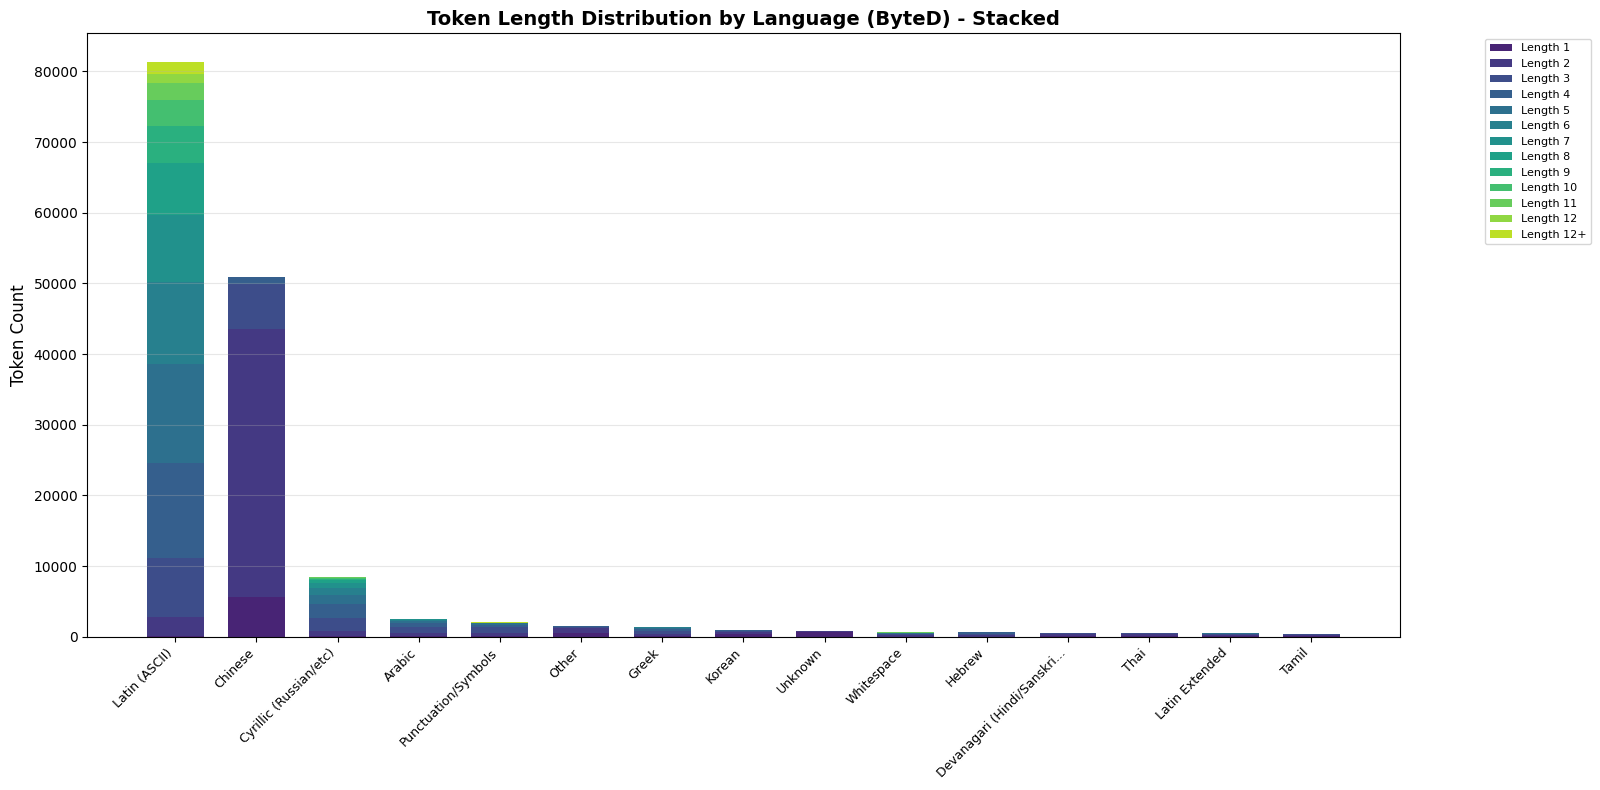

In [53]:
# Create a detailed grouped bar chart showing length distribution for all major languages (ByteD)
byted_major_languages = [lang for lang, lengths in byted_sorted_languages if len(lengths) >= 50][:15]

# Get the length distribution for each language
max_length_to_show = 12  # Show lengths 1 to 12

byted_length_data = {}
for lang in byted_major_languages:
    lengths = byted_language_token_lengths[lang]
    length_counts = defaultdict(int)
    for l in lengths:
        if l <= max_length_to_show:
            length_counts[l] += 1
        else:
            length_counts[max_length_to_show + 1] += 1  # "12+" bucket
    byted_length_data[lang] = length_counts

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(byted_major_languages))
width = 0.7

# Colors for different lengths
length_colors = plt.cm.viridis(np.linspace(0.1, 0.9, max_length_to_show + 1))

bottom = np.zeros(len(byted_major_languages))

for length_val in range(1, max_length_to_show + 2):
    counts = [byted_length_data[lang].get(length_val, 0) for lang in byted_major_languages]
    label = f"Length {length_val}" if length_val <= max_length_to_show else f"Length {max_length_to_show}+"
    ax.bar(x, counts, width, bottom=bottom, label=label, color=length_colors[length_val - 1])
    bottom += counts

ax.set_ylabel('Token Count', fontsize=12)
ax.set_title('Token Length Distribution by Language (ByteD) - Stacked', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([lang[:25] + "..." if len(lang) > 25 else lang for lang in byted_major_languages], 
                    rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Final Summary Comparison: All Tokenizers

In [56]:
# Summary comparison between all tokenizers: DeepSeek V3, GPT-OSS, Qwen, Mistral, OLMo, ByteD
print("=" * 160)
print("TOKENIZER COMPARISON: DeepSeek V3 vs GPT-OSS vs Qwen vs Mistral vs OLMo vs ByteD")
print("=" * 160)

print(f"\n{'Metric':<40} {'DeepSeek':>15} {'GPT-OSS':>15} {'Qwen':>15} {'Mistral':>15} {'OLMo':>15} {'ByteD':>15}")
print("-" * 145)

# Get tokenizer types from the loaded data
ds_type = tokenizer_data.get('model', {}).get('type', 'BPE') if 'tokenizer_data' in dir() else 'BPE'
gptoss_type = gptoss_tokenizer_data.get('model', {}).get('type', 'BPE') if 'gptoss_tokenizer_data' in dir() else 'BPE'
qwen_type = qwen_tokenizer_data.get('model', {}).get('type', 'BPE') if 'qwen_tokenizer_data' in dir() else 'BPE'
mistral_type = mistral_tokenizer_data.get('model', {}).get('type', 'BPE') if 'mistral_tokenizer_data' in dir() else 'BPE'
olmo_type = olmo_tokenizer_data.get('model', {}).get('type', 'BPE') if 'olmo_tokenizer_data' in dir() else 'BPE'
byted_type = byted_tokenizer_data.get('model', {}).get('type', 'BPE') if 'byted_tokenizer_data' in dir() else 'BPE'

# All use byte-level BPE (GPT-2 style)
print(f"{'Tokenizer Type':<40} {ds_type + ' (byte)':>15} {gptoss_type + ' (byte)':>15} {qwen_type + ' (byte)':>15} {mistral_type + ' (byte)':>15} {olmo_type + ' (byte)':>15} {byted_type + ' (byte)':>15}")

# Vocabulary sizes
ds_vocab_size = len(vocab) if 'vocab' in dir() else 0
gptoss_vocab_size = len(gptoss_vocab) if 'gptoss_vocab' in dir() else 0
qwen_vocab_size = len(qwen_vocab) if 'qwen_vocab' in dir() else 0
mistral_vocab_size = len(mistral_vocab) if 'mistral_vocab' in dir() else 0
olmo_vocab_size = len(olmo_vocab)
byted_vocab_size = len(byted_vocab)

print(f"{'Total vocabulary size':<40} {ds_vocab_size:>15,} {gptoss_vocab_size:>15,} {qwen_vocab_size:>15,} {mistral_vocab_size:>15,} {olmo_vocab_size:>15,} {byted_vocab_size:>15,}")

# Indic language totals
indic_scripts_list = [
    "Devanagari (Hindi/Sanskrit/Marathi/Nepali)",
    "Bengali/Assamese",
    "Tamil",
    "Kannada",
    "Telugu",
    "Malayalam",
    "Gujarati",
    "Gurmukhi (Punjabi)",
    "Sinhala",
    "Odia/Oriya"
]

ds_indic_total = sum(len(decoded_classifications.get(s, [])) for s in indic_scripts_list) if 'decoded_classifications' in dir() else 0
gptoss_indic_total = sum(len(gptoss_decoded_classifications.get(s, [])) for s in indic_scripts_list) if 'gptoss_decoded_classifications' in dir() else 0
qwen_indic_total = sum(len(qwen_decoded_classifications.get(s, [])) for s in indic_scripts_list) if 'qwen_decoded_classifications' in dir() else 0
mistral_indic_total = sum(len(mistral_decoded_classifications.get(s, [])) for s in indic_scripts_list) if 'mistral_decoded_classifications' in dir() else 0
olmo_indic_total = sum(len(olmo_decoded_classifications.get(s, [])) for s in indic_scripts_list)
byted_indic_total = sum(len(byted_decoded_classifications.get(s, [])) for s in indic_scripts_list)

print(f"{'Total Indic tokens':<40} {ds_indic_total:>15,} {gptoss_indic_total:>15,} {qwen_indic_total:>15,} {mistral_indic_total:>15,} {olmo_indic_total:>15,} {byted_indic_total:>15,}")

# Indic percentages
if all([ds_vocab_size, gptoss_vocab_size, qwen_vocab_size, mistral_vocab_size, olmo_vocab_size, byted_vocab_size]):
    ds_indic_pct = (ds_indic_total / ds_vocab_size) * 100
    gptoss_indic_pct = (gptoss_indic_total / gptoss_vocab_size) * 100
    qwen_indic_pct = (qwen_indic_total / qwen_vocab_size) * 100
    mistral_indic_pct = (mistral_indic_total / mistral_vocab_size) * 100
    olmo_indic_pct = (olmo_indic_total / olmo_vocab_size) * 100
    byted_indic_pct = (byted_indic_total / byted_vocab_size) * 100
    print(f"{'Indic tokens (%)':<40} {ds_indic_pct:>14.2f}% {gptoss_indic_pct:>14.2f}% {qwen_indic_pct:>14.2f}% {mistral_indic_pct:>14.2f}% {olmo_indic_pct:>14.2f}% {byted_indic_pct:>14.2f}%")

# Count tokens with length > 32
ds_long_tokens = sum(1 for token in vocab.keys() if len(decode_bpe_token(token)) > 32) if 'vocab' in dir() else 0
gptoss_long_tokens = sum(1 for token in gptoss_vocab.keys() if len(gptoss_decode_bpe_token(token)) > 32) if 'gptoss_vocab' in dir() else 0
qwen_long_tokens = sum(1 for token in qwen_vocab.keys() if len(qwen_decode_bpe_token(token)) > 32) if 'qwen_vocab' in dir() else 0
mistral_long_tokens = sum(1 for token in mistral_vocab.keys() if len(mistral_decode_bpe_token(token)) > 32) if 'mistral_vocab' in dir() else 0
olmo_long_tokens = sum(1 for token in olmo_vocab.keys() if len(olmo_decode_bpe_token(token)) > 32)
byted_long_tokens = sum(1 for token in byted_vocab.keys() if len(byted_decode_bpe_token(token)) > 32)

print(f"{'Tokens with length > 32':<40} {ds_long_tokens:>15,} {gptoss_long_tokens:>15,} {qwen_long_tokens:>15,} {mistral_long_tokens:>15,} {olmo_long_tokens:>15,} {byted_long_tokens:>15,}")

if all([ds_vocab_size, gptoss_vocab_size, qwen_vocab_size, mistral_vocab_size, olmo_vocab_size, byted_vocab_size]):
    ds_long_pct = (ds_long_tokens / ds_vocab_size) * 100
    gptoss_long_pct = (gptoss_long_tokens / gptoss_vocab_size) * 100
    qwen_long_pct = (qwen_long_tokens / qwen_vocab_size) * 100
    mistral_long_pct = (mistral_long_tokens / mistral_vocab_size) * 100
    olmo_long_pct = (olmo_long_tokens / olmo_vocab_size) * 100
    byted_long_pct = (byted_long_tokens / byted_vocab_size) * 100
    print(f"{'Long tokens (>32) (%)':<40} {ds_long_pct:>14.2f}% {gptoss_long_pct:>14.2f}% {qwen_long_pct:>14.2f}% {mistral_long_pct:>14.2f}% {olmo_long_pct:>14.2f}% {byted_long_pct:>14.2f}%")

print("\n" + "-" * 145)
print("Indic Language Breakdown:")
print("-" * 145)
print(f"{'Language':<40} {'DeepSeek':>15} {'GPT-OSS':>15} {'Qwen':>15} {'Mistral':>15} {'OLMo':>15} {'ByteD':>15}")
print("-" * 145)

for script in indic_scripts_list:
    ds_count = len(decoded_classifications.get(script, [])) if 'decoded_classifications' in dir() else 0
    gptoss_count = len(gptoss_decoded_classifications.get(script, [])) if 'gptoss_decoded_classifications' in dir() else 0
    qwen_count = len(qwen_decoded_classifications.get(script, [])) if 'qwen_decoded_classifications' in dir() else 0
    mistral_count = len(mistral_decoded_classifications.get(script, [])) if 'mistral_decoded_classifications' in dir() else 0
    olmo_count = len(olmo_decoded_classifications.get(script, []))
    byted_count = len(byted_decoded_classifications.get(script, []))
    
    print(f"{script:<40} {ds_count:>15,} {gptoss_count:>15,} {qwen_count:>15,} {mistral_count:>15,} {olmo_count:>15,} {byted_count:>15,}")

# Top 10 Non-Indic Languages Breakdown
print("\n" + "-" * 145)
print("Top 10 Non-Indic Languages Breakdown:")
print("-" * 145)
print(f"{'Language':<40} {'DeepSeek':>15} {'GPT-OSS':>15} {'Qwen':>15} {'Mistral':>15} {'OLMo':>15} {'ByteD':>15}")
print("-" * 145)

# Get all non-Indic languages and their counts across all tokenizers
non_indic_totals = {}
all_classifications = [
    ('ds', decoded_classifications if 'decoded_classifications' in dir() else {}),
    ('gptoss', gptoss_decoded_classifications if 'gptoss_decoded_classifications' in dir() else {}),
    ('qwen', qwen_decoded_classifications if 'qwen_decoded_classifications' in dir() else {}),
    ('mistral', mistral_decoded_classifications if 'mistral_decoded_classifications' in dir() else {}),
    ('olmo', olmo_decoded_classifications),
    ('byted', byted_decoded_classifications)
]

# Collect all languages across all tokenizers
all_languages = set()
for name, classifications in all_classifications:
    all_languages.update(classifications.keys())

# Filter out Indic languages
non_indic_languages = [lang for lang in all_languages if lang not in indic_scripts_list]

# Calculate total tokens per non-Indic language (sum across all tokenizers for ranking)
for lang in non_indic_languages:
    total = sum(len(classifications.get(lang, [])) for _, classifications in all_classifications)
    non_indic_totals[lang] = total

# Sort by total count and get top 10
top_10_non_indic = sorted(non_indic_totals.items(), key=lambda x: x[1], reverse=True)[:10]

for lang, _ in top_10_non_indic:
    ds_count = len(decoded_classifications.get(lang, [])) if 'decoded_classifications' in dir() else 0
    gptoss_count = len(gptoss_decoded_classifications.get(lang, [])) if 'gptoss_decoded_classifications' in dir() else 0
    qwen_count = len(qwen_decoded_classifications.get(lang, [])) if 'qwen_decoded_classifications' in dir() else 0
    mistral_count = len(mistral_decoded_classifications.get(lang, [])) if 'mistral_decoded_classifications' in dir() else 0
    olmo_count = len(olmo_decoded_classifications.get(lang, []))
    byted_count = len(byted_decoded_classifications.get(lang, []))
    
    # Shorten language name if needed for display
    display_lang = lang[:38] if len(lang) > 38 else lang
    print(f"{display_lang:<40} {ds_count:>15,} {gptoss_count:>15,} {qwen_count:>15,} {mistral_count:>15,} {olmo_count:>15,} {byted_count:>15,}")

TOKENIZER COMPARISON: DeepSeek V3 vs GPT-OSS vs Qwen vs Mistral vs OLMo vs ByteD

Metric                                          DeepSeek         GPT-OSS            Qwen         Mistral            OLMo           ByteD
-------------------------------------------------------------------------------------------------------------------------------------------------
Tokenizer Type                                BPE (byte)      BPE (byte)      BPE (byte)      BPE (byte)      BPE (byte)      BPE (byte)
Total vocabulary size                            128,000         199,998         151,643         131,072         100,278         155,121
Total Indic tokens                                 1,473          13,634             279           5,197              43           2,511
Indic tokens (%)                                   1.15%           6.82%           0.18%           3.96%           0.04%           1.62%
Tokens with length > 32                               56             157             21